# Training a Computer-Using Agent (CUA) for GUI Task Automation - Group 5

## Team Members
William Gao, Jamie Linsdell, Tim Machasio, Guy Berger, Zaina Edelson


## Research Question
Can a sub-1B vision-language model (Florence-2), LoRA fine-tuned on a 3.4% UGround subset, match or approach a 2B baseline (Qwen2-VL) on UI element grounding accuracy?

## Summary of Data Findings
Data is mostly intact with very few rows having true data quality issues (e.g. invalid values or missing data). The data primarily skews towards large UI elements such as links and buttons and are all desktop based images, with most elements appearing in the top half of the screen


## Dataset overview

This is a subsample (43.4k rows, ~15.7 GB) of the full [osunlp/UGround-V1-Data](https://huggingface.co/datasets/osunlp/UGround-V1-Data) dataset, which was introduced in the paper *"Navigating GUIs as Humans Do: Universal Visual Grounding for GUI Agents"* (ICLR 2025 Oral).

The dataset is designed for training vision-language models to perform **GUI grounding** — identifying the precise pixel coordinates of UI elements described in natural language. It contains screenshots of web pages paired with conversations that ask a model to locate specific elements.

### Data structure

The data is stored as parquet files across three subfolders:

| Subfolder | Description |
|---|---|
| `web_direct_150k_description_filtered` | Direct grounding tasks filtered by element description |
| `web_direct_258k_function_filtered` | Direct grounding tasks filtered by element function |
| `web_hybrid_773k_max_25qa_filtered` | Hybrid grounding tasks (primary source of performance gains per the paper) |

Each row has four columns:

| Column | Type | Description |
|---|---|---|
| `width` | int | Original image width in pixels |
| `height` | int | Original image height in pixels |
| `conversations` | str | JSON-encoded list of `{"from": "human"/"gpt", "value": "..."}` conversation turns |
| `image` | bytes | Raw screenshot image data (PNG/JPEG) |

The conversation turns contain grounding coordinates normalised to **[0, 999]** in Qwen2-VL format. The human turn typically asks the model to identify the precise coordinates of a described UI element, and the assistant turn provides the `(x, y)` point.

### How images were saved (from the original repo)

```python
with open(item["image"], "rb") as img_file:
    img_bytes = img_file.read()
record = {
    "width": item["width"],
    "height": item["height"],
    "conversations": json.dumps(item["conversations"], ensure_ascii=False),
    "image": img_bytes
}
```

# UGround-V1-Data Bias & Skew Audit

This notebook analyzes the [UGround-V1-Data](https://huggingface.co/datasets/osunlp/UGround-V1-Data) dataset for:
1. **Element type distribution** — are certain UI elements (search boxes, links, buttons) over-represented?
2. **Referring expression (RE) diversity** — are instructions linguistically varied or templated?
3. **Spatial/positional bias** — do target elements cluster in specific screen regions?
4. **Resolution & aspect ratio skew** — what screen sizes dominate?
5. **Action verb distribution** — is the dataset over-trained on specific actions like "click" or "find"?

**Requirements**: You need HuggingFace access approval for this gated dataset.  
**Runtime**: Free Colab is sufficient for text-only analysis on a sample.

## 0. Setup & Authentication

In [ ]:
!pip install -q datasets huggingface_hub matplotlib seaborn numpy pandas

In [ ]:
!pip uninstall -y -q torchao

In [ ]:
from huggingface_hub import login

# This will prompt you for your HF token
# Get one at: https://huggingface.co/settings/tokens
login()

In [ ]:
# MOUNT GOOGLE DRIVE
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Load the Dataset (Streaming Mode)

We use streaming to avoid downloading the entire dataset to disk.  
We'll sample a configurable number of records for analysis.

In [ ]:
from datasets import load_dataset, get_dataset_config_names, get_dataset_split_names
import json

# ============================================================
# CONFIG — adjust sample size as needed
# ============================================================
SAMPLE_SIZE = 50_000       # number of records to analyze
DATASET_ID = "osunlp/UGround-V1-Data"
# ============================================================

# Step 1: Discover available configs and splits
print("Discovering dataset structure...")
try:
    configs = get_dataset_config_names(DATASET_ID)
    print(f"  Configs: {configs}")
except Exception as e:
    configs = ["default"]
    print(f"  Could not fetch configs ({e}), using 'default'")

config_name = configs[0]  # typically 'default'
try:
    splits = get_dataset_split_names(DATASET_ID, config_name)
    print(f"  Splits for '{config_name}': {splits}")
except Exception as e:
    splits = ["train"]
    print(f"  Could not fetch splits ({e}), using 'train'")

# Step 2: Pick which split to load
# Prefer 'web_hybrid' if it exists as a split, otherwise use 'train'
if "web_hybrid" in splits:
    SPLIT = "web_hybrid"
elif "train" in splits:
    SPLIT = "train"
else:
    SPLIT = splits[0]
print(f"\n→ Loading split '{SPLIT}' from config '{config_name}' in streaming mode...")

ds = load_dataset(DATASET_ID, config_name, streaming=True, split=SPLIT)

# Step 3: Collect sample (skip heavy image bytes)
records = []
for i, record in enumerate(ds):
    if i >= SAMPLE_SIZE:
        break
    try:
        convos = json.loads(record["conversations"]) if isinstance(record["conversations"], str) else record["conversations"]
    except (json.JSONDecodeError, TypeError):
        convos = []
    records.append({
        "width": record.get("width"),
        "height": record.get("height"),
        "conversations": convos,
    })
    if (i + 1) % 10000 == 0:
        print(f"  Loaded {i + 1:,} records...")

print(f"\nDone. Loaded {len(records):,} records from split '{SPLIT}'.")
print(f"Sample record columns: {list(record.keys()) if records else 'N/A'}")
print(f"\n💡 To analyze a different split, change SPLIT above to one of: {splits}")

Discovering dataset structure...


Resolving data files:   0%|          | 0/3582 [00:00<?, ?it/s]

  Configs: ['default']


Resolving data files:   0%|          | 0/3582 [00:00<?, ?it/s]

  Splits for 'default': ['train']

→ Loading split 'train' from config 'default' in streaming mode...


Resolving data files:   0%|          | 0/3582 [00:00<?, ?it/s]

  Loaded 10,000 records...
  Loaded 20,000 records...
  Loaded 30,000 records...
  Loaded 40,000 records...
  Loaded 50,000 records...

Done. Loaded 50,000 records from split 'train'.
Sample record columns: ['width', 'height', 'conversations', 'image']

💡 To analyze a different split, change SPLIT above to one of: ['train']


In [ ]:
# Quick inspection — what does a conversation look like?
import pprint
for r in records[:3]:
    print(f"Resolution: {r['width']}x{r['height']}")
    pprint.pprint(r["conversations"])
    print("---")

Resolution: 1434x806
[{'from': 'human',
  'value': '<image>Your task is to help the user identify the precise '
           'coordinates (x, y) of a specific area/element/object on this '
           'screen based on a description.\n'
           '\n'
           '- Your response should aim to point to the center or a '
           'representative point within the described area/element/object as '
           'accurately as possible.\n'
           '- If the description is unclear or ambiguous, infer the most '
           'relevant area or element based on its likely context or purpose.\n'
           '- Your answer should be a single string (x, y) corresponding to '
           'the point of interest.\n'
           '\n'
           'Description: The navigation menu item labeled "PLUMBING" with a '
           'small downward-pointing arrow next to it, situated between the '
           '"ABOUT" and "HEATING & AIR CONDITIONING" menu items within the '
           'yellow navigation bar under the c

## 2. Extract Referring Expressions & Coordinates

Each conversation typically has a user turn (the referring expression / instruction) and an assistant turn (the coordinates). Let's parse them out.

In [ ]:
import re

referring_expressions = []  # the human instructions
coordinates = []            # parsed (x, y) or (x1, y1, x2, y2) from assistant
resolutions = []            # (width, height)

for rec in records:
    resolutions.append((rec["width"], rec["height"]))
    convos = rec["conversations"]
    if not convos:
        continue

    for turn in convos:
        role = turn.get("from") or turn.get("role") or ""
        text = turn.get("value") or turn.get("content") or ""

        if role in ("human", "user"):
            # Strip system prompt boilerplate if present
            # The RE is usually after the task description
            referring_expressions.append(text)
        elif role in ("gpt", "assistant"):
            # Extract coordinates — format is typically (x, y) normalized to [0, 999]
            nums = re.findall(r'\d+', text)
            if len(nums) >= 2:
                coords = [int(n) for n in nums]
                coordinates.append(coords)

print(f"Extracted {len(referring_expressions):,} referring expressions")
print(f"Extracted {len(coordinates):,} coordinate sets")
print(f"Collected {len(resolutions):,} resolutions")
print(f"\nSample REs:")
for re_text in referring_expressions[:5]:
    print(f"  • {re_text[:120]}..." if len(re_text) > 120 else f"  • {re_text}")

Extracted 50,000 referring expressions
Extracted 50,000 coordinate sets
Collected 50,000 resolutions

Sample REs:
  • <image>Your task is to help the user identify the precise coordinates (x, y) of a specific area/element/object on this s...
  • <image>
Your task is to help the user identify the precise coordinates (x, y) of a specific area/element/object on this ...
  • <image>
Your task is to help the user identify the precise coordinates (x, y) of a specific area/element/object in the i...
  • <image>Your task is to help the user identify the precise coordinates (x, y) of a specific area/element/object on the sc...
  • <image>
Your task is to help the user identify the precise coordinates (x, y) of a specific area/element/object in the i...


## 3. Element Type Distribution

Classify each referring expression by the UI element type it targets.  
This uses keyword matching — not perfect, but gives a strong directional signal.

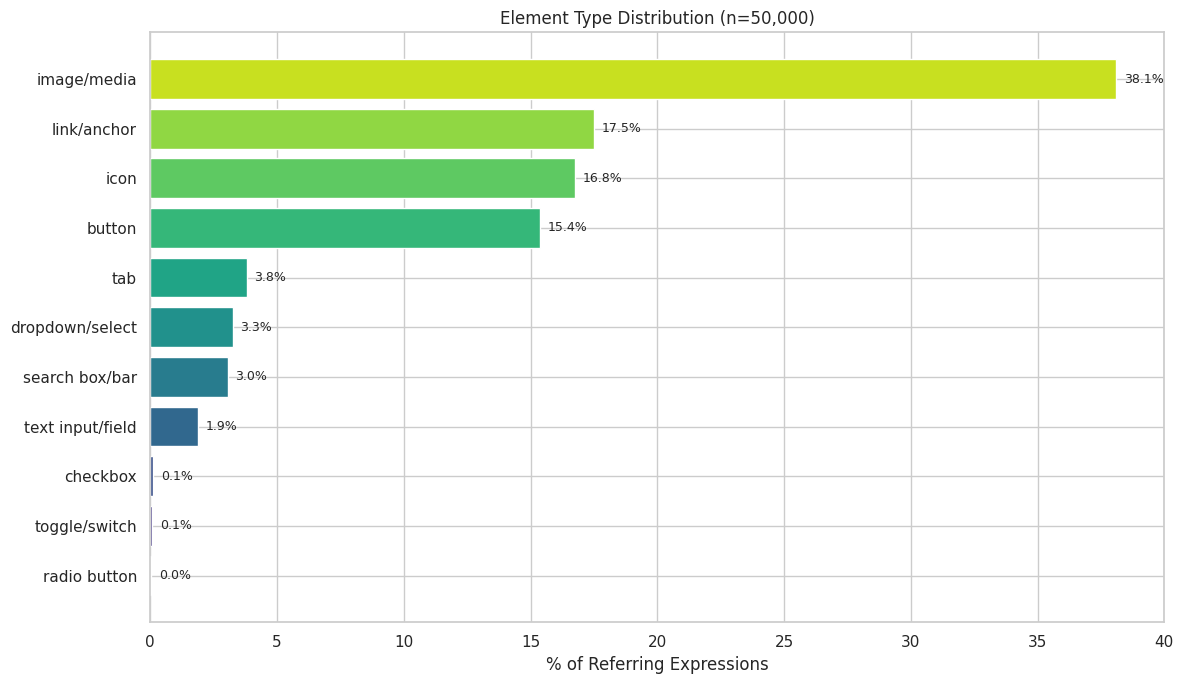


⚠️  Concentration check:
  image/media                38.1% ← POTENTIAL BIAS
  link/anchor                17.5%
  icon                       16.8%
  button                     15.4%
  tab                         3.8%
  dropdown/select             3.3%
  search box/bar              3.0%
  text input/field            1.9%
  checkbox                    0.1%
  toggle/switch               0.1%
  radio button                0.0%


In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# Element type keyword patterns (order matters — first match wins)
ELEMENT_PATTERNS = [
    ("search box/bar",    r"\b(search\s*(box|bar|field|input)|search icon)\b"),
    ("text input/field",  r"\b(text\s*(field|input|box|area)|input\s*(field|box)|textarea|form field|type\s*(in|into|here))\b"),
    ("button",            r"\b(button|btn|submit|click\s*(on|the)?\s*(button|btn))\b"),
    ("link/anchor",       r"\b(link|anchor|href|hyperlink|click\s*(on|the)?\s*link)\b"),
    ("dropdown/select",   r"\b(dropdown|select|combobox|drop-down|pulldown|menu\s*option)\b"),
    ("checkbox",          r"\b(checkbox|check\s*box|checkmark|tick\s*box)\b"),
    ("radio button",      r"\b(radio\s*(button|option)|radio)\b"),
    ("toggle/switch",     r"\b(toggle|switch|slider\s*switch)\b"),
    ("tab",               r"\b(tab|tab\s*bar|tab\s*menu)\b"),
    ("icon",              r"\b(icon|logo|favicon|symbol|glyph)\b"),
    ("image/media",       r"\b(image|photo|picture|thumbnail|video|media|img)\b"),
    ("navigation/menu",   r"\b(nav|navigation|menu|hamburger|sidebar|breadcrumb|toolbar)\b"),
    ("text/label",        r"\b(text|label|heading|title|paragraph|caption|header|footer)\b"),
    ("scroll",            r"\b(scroll|scrollbar|scroll\s*(up|down))\b"),
    ("modal/dialog",      r"\b(modal|dialog|popup|popover|overlay|tooltip)\b"),
    ("card/container",    r"\b(card|container|panel|section|div|block|widget|tile)\b"),
]

element_counts = Counter()
unclassified_samples = []

for re_text in referring_expressions:
    text_lower = re_text.lower()
    matched = False
    for label, pattern in ELEMENT_PATTERNS:
        if re.search(pattern, text_lower):
            element_counts[label] += 1
            matched = True
            break
    if not matched:
        element_counts["other/unclassified"] += 1
        if len(unclassified_samples) < 20:
            unclassified_samples.append(re_text[:150])

# Sort and plot
sorted_elements = element_counts.most_common()
labels, counts = zip(*sorted_elements)
total = sum(counts)
pcts = [c / total * 100 for c in counts]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(labels[::-1], pcts[::-1], color=sns.color_palette("viridis", len(labels)))
ax.set_xlabel("% of Referring Expressions")
ax.set_title(f"Element Type Distribution (n={total:,})")
for bar, pct in zip(bars, pcts[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{pct:.1f}%", va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\n⚠️  Concentration check:")
for label, pct in zip(labels, pcts):
    flag = " ← POTENTIAL BIAS" if pct > 25 else ""
    print(f"  {label:25s} {pct:5.1f}%{flag}")

In [ ]:
# Inspect unclassified samples to see what we're missing
print("Sample unclassified REs (check if patterns need expanding):")
for s in unclassified_samples:
    print(f"  • {s}")

Sample unclassified REs (check if patterns need expanding):


## 4. Action Verb Distribution

Is the dataset over-indexed on specific actions like "click", "find", "locate"?

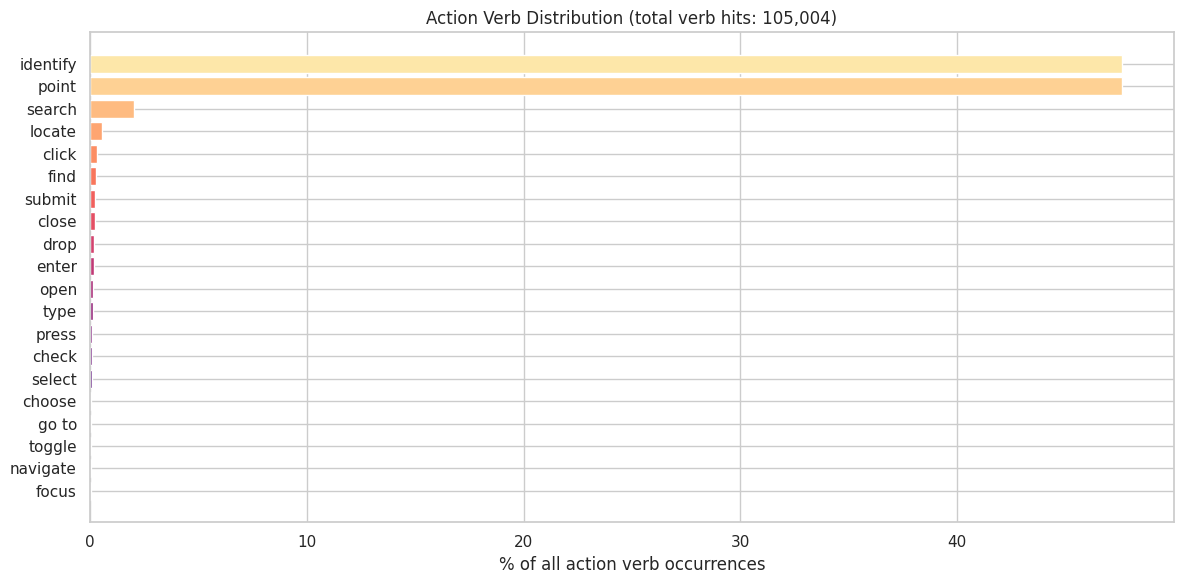


⚠️  Verb dominance check:
  'identify': 47.6% of all verb usage ← HEAVILY DOMINANT
  'point': 47.6% of all verb usage ← HEAVILY DOMINANT
  'search': 2.0% of all verb usage
  'locate': 0.5% of all verb usage
  'click': 0.3% of all verb usage


In [ ]:
ACTION_VERBS = [
    "click", "tap", "press", "select", "find", "locate", "identify",
    "point", "hover", "scroll", "type", "enter", "search", "open",
    "close", "expand", "collapse", "drag", "drop", "toggle",
    "check", "uncheck", "submit", "navigate", "go to", "switch",
    "choose", "pick", "highlight", "focus",
]

verb_counts = Counter()

for re_text in referring_expressions:
    text_lower = re_text.lower()
    for verb in ACTION_VERBS:
        if re.search(r'\b' + re.escape(verb) + r'\b', text_lower):
            verb_counts[verb] += 1

# Plot top verbs
top_verbs = verb_counts.most_common(20)
if top_verbs:
    v_labels, v_counts = zip(*top_verbs)
    v_total = sum(verb_counts.values())

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(v_labels[::-1], [c/v_total*100 for c in v_counts[::-1]],
            color=sns.color_palette("magma", len(v_labels)))
    ax.set_xlabel("% of all action verb occurrences")
    ax.set_title(f"Action Verb Distribution (total verb hits: {v_total:,})")
    plt.tight_layout()
    plt.show()

    # Dominance check
    print("\n⚠️  Verb dominance check:")
    for v, c in top_verbs[:5]:
        pct = c / v_total * 100
        flag = " ← HEAVILY DOMINANT" if pct > 30 else ""
        print(f"  '{v}': {pct:.1f}% of all verb usage{flag}")
else:
    print("No action verbs detected — REs may be noun-phrase only (e.g., 'the search box')")

## 5. Referring Expression Linguistic Diversity

Check if the REs are diverse or repetitive/templated.

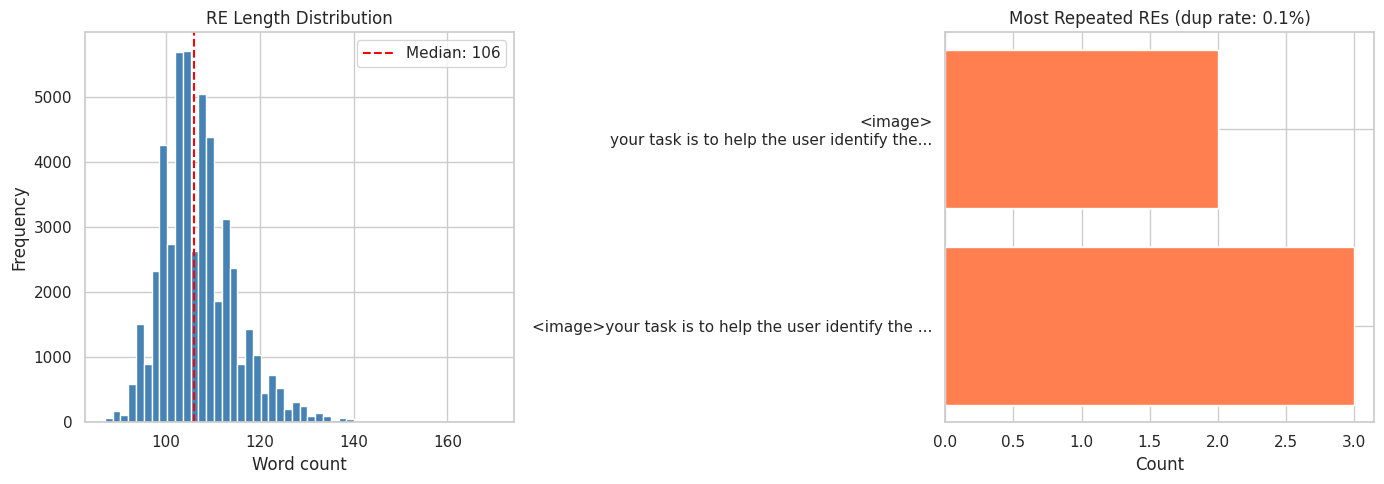


Total REs: 50,000
Unique REs: 49,951
Duplicate rate: 0.1%

⚠️  Duplication looks acceptable (0.1%)


In [ ]:
from collections import Counter
import math

# --- 5a. RE length distribution ---
re_lengths = [len(r.split()) for r in referring_expressions]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(re_lengths, bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Word count")
axes[0].set_ylabel("Frequency")
axes[0].set_title("RE Length Distribution")
axes[0].axvline(np.median(re_lengths), color='red', linestyle='--', label=f'Median: {np.median(re_lengths):.0f}')
axes[0].legend()

# --- 5b. Exact duplicate rate ---
re_counter = Counter(r.lower().strip() for r in referring_expressions)
total_res = len(referring_expressions)
unique_res = len(re_counter)
dup_rate = (1 - unique_res / total_res) * 100

top_dupes = re_counter.most_common(15)
dupe_labels = [f"{t[:50]}..." if len(t) > 50 else t for t, _ in top_dupes]
dupe_counts = [c for _, c in top_dupes]

axes[1].barh(dupe_labels[::-1], dupe_counts[::-1], color="coral")
axes[1].set_xlabel("Count")
axes[1].set_title(f"Most Repeated REs (dup rate: {dup_rate:.1f}%)")

plt.tight_layout()
plt.show()

print(f"\nTotal REs: {total_res:,}")
print(f"Unique REs: {unique_res:,}")
print(f"Duplicate rate: {dup_rate:.1f}%")
print(f"\n⚠️  Duplication {'is a concern' if dup_rate > 20 else 'looks acceptable'} ({dup_rate:.1f}%)")

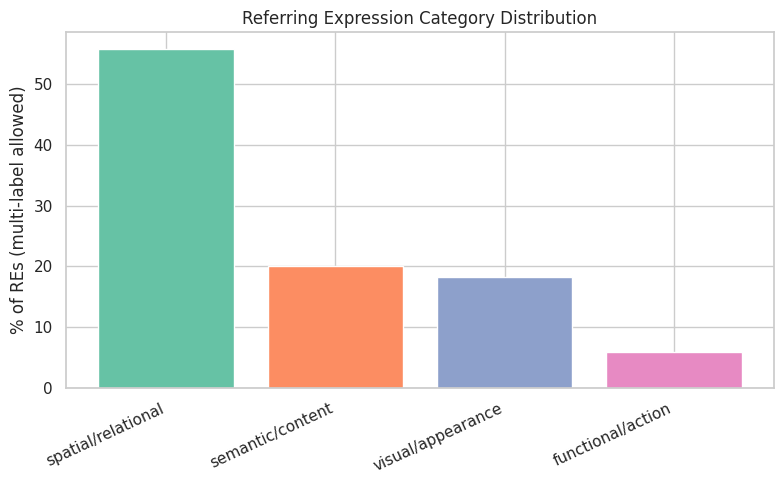


Multi-category REs: 30,500 (61.0%)
(Higher = more diverse/natural descriptions)


In [ ]:
# --- 5c. RE Category classification (visual / functional / semantic / spatial) ---

RE_CATEGORY_PATTERNS = {
    "visual/appearance": r"\b(color|colou?red|blue|red|green|white|black|gray|grey|yellow|orange|purple|pink|bold|italic|underline|large|small|big|round|square|bright|dark|transparent|outlined|filled|solid)\b",
    "spatial/relational": r"\b(above|below|left|right|next to|beside|under|over|top|bottom|between|near|corner|center|middle|adjacent|upper|lower|first|second|third|last)\b",
    "functional/action":  r"\b(click|tap|press|submit|login|sign.?in|sign.?up|search|download|upload|play|pause|delete|edit|save|send|buy|add to cart|checkout|subscribe|register|close|open|expand|collapse)\b",
    "semantic/content":   r"\b(says|reads|labeled|labelled|titled|named|shows|displays|contains|with text|that says|reading|written|caption|heading that)\b",
}

category_counts = Counter()
multi_category = 0

for re_text in referring_expressions:
    text_lower = re_text.lower()
    matches = []
    for cat, pattern in RE_CATEGORY_PATTERNS.items():
        if re.search(pattern, text_lower):
            matches.append(cat)
    if not matches:
        category_counts["uncategorized"] += 1
    else:
        for m in matches:
            category_counts[m] += 1
        if len(matches) > 1:
            multi_category += 1

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
cats = category_counts.most_common()
c_labels, c_counts = zip(*cats)
c_total = sum(c_counts)
ax.bar(c_labels, [c/c_total*100 for c in c_counts], color=sns.color_palette("Set2", len(c_labels)))
ax.set_ylabel("% of REs (multi-label allowed)")
ax.set_title("Referring Expression Category Distribution")
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

print(f"\nMulti-category REs: {multi_category:,} ({multi_category/total_res*100:.1f}%)")
print("(Higher = more diverse/natural descriptions)")

## 6. Spatial / Positional Bias (Coordinate Heatmap)

Where on the screen do target elements tend to be located?  
All coordinates are normalized to [0, 999].

Coordinate points: 50,000


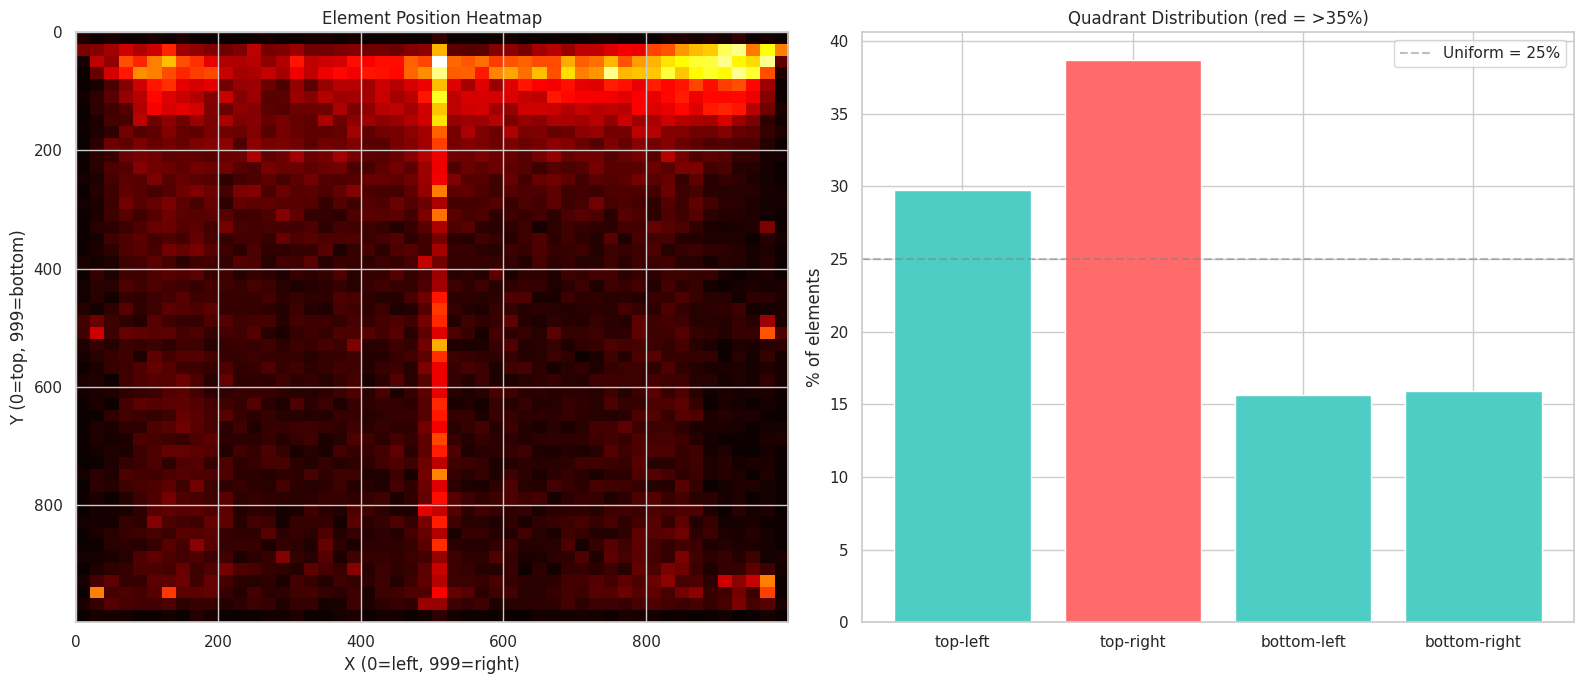


⚠️  Spatial balance check (uniform = 25% each):
  top-left         29.7%
  top-right        38.7% ← OVER-REPRESENTED
  bottom-left      15.7%
  bottom-right     15.9%


In [ ]:
# Extract (x, y) center points — take first two numbers as (x, y)
xs, ys = [], []
for coord in coordinates:
    if len(coord) == 2:
        xs.append(coord[0])
        ys.append(coord[1])
    elif len(coord) == 4:
        # Bounding box: use center point
        xs.append((coord[0] + coord[2]) / 2)
        ys.append((coord[1] + coord[3]) / 2)

print(f"Coordinate points: {len(xs):,}")

if xs:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Heatmap
    heatmap, xedges, yedges = np.histogram2d(xs, ys, bins=50, range=[[0, 999], [0, 999]])
    axes[0].imshow(heatmap.T, origin='upper', extent=[0, 999, 999, 0],
                   cmap='hot', aspect='auto')
    axes[0].set_xlabel("X (0=left, 999=right)")
    axes[0].set_ylabel("Y (0=top, 999=bottom)")
    axes[0].set_title("Element Position Heatmap")

    # Quadrant analysis
    quadrants = Counter()
    for x, y in zip(xs, ys):
        h = "left" if x < 500 else "right"
        v = "top" if y < 500 else "bottom"
        quadrants[f"{v}-{h}"] += 1

    q_labels = ["top-left", "top-right", "bottom-left", "bottom-right"]
    q_vals = [quadrants.get(q, 0) / len(xs) * 100 for q in q_labels]
    colors = ["#ff6b6b" if v > 35 else "#4ecdc4" for v in q_vals]
    axes[1].bar(q_labels, q_vals, color=colors)
    axes[1].set_ylabel("% of elements")
    axes[1].set_title("Quadrant Distribution (red = >35%)")
    axes[1].axhline(25, color='gray', linestyle='--', alpha=0.5, label='Uniform = 25%')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print("\n⚠️  Spatial balance check (uniform = 25% each):")
    for q, v in zip(q_labels, q_vals):
        flag = " ← OVER-REPRESENTED" if v > 35 else (" ← UNDER-REPRESENTED" if v < 15 else "")
        print(f"  {q:15s} {v:5.1f}%{flag}")
else:
    print("No coordinates extracted — check parsing logic above.")

## 7. Resolution & Aspect Ratio Distribution

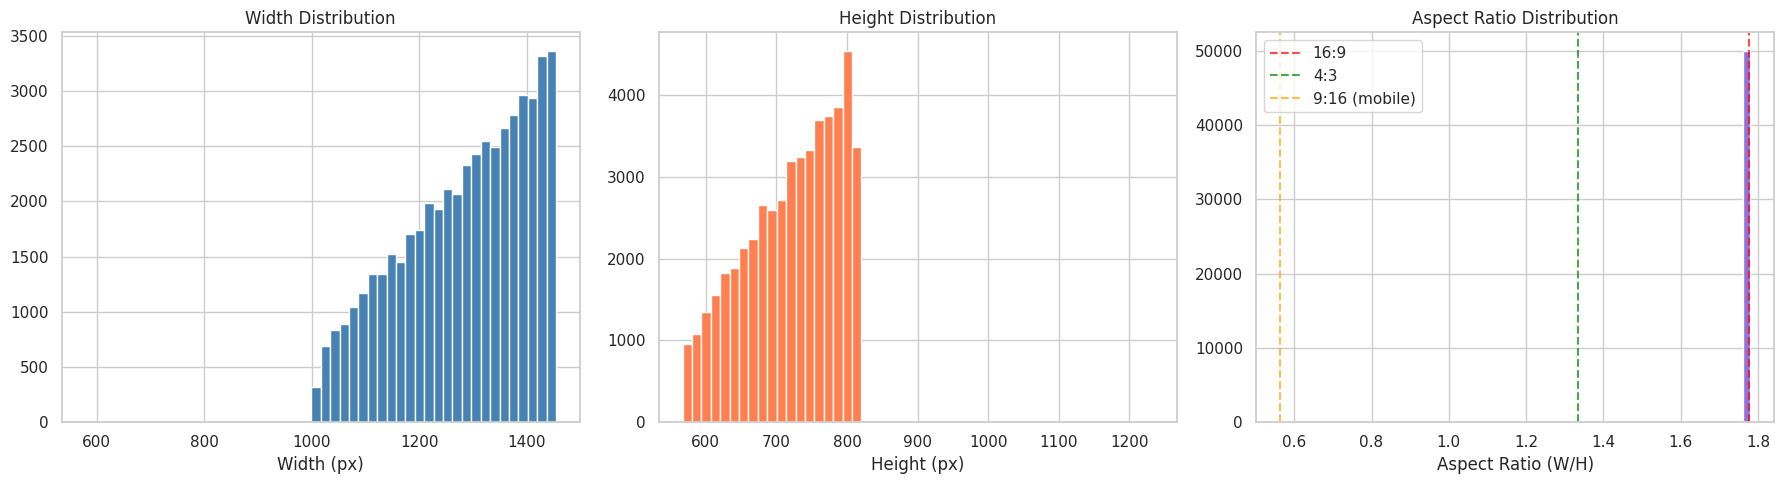


Top 10 resolutions:
  1454x817: 208 (0.4%)
  1449x815: 202 (0.4%)
  1442x811: 200 (0.4%)
  1439x809: 197 (0.4%)
  1413x794: 197 (0.4%)
  1446x813: 196 (0.4%)
  1397x785: 196 (0.4%)
  1437x808: 195 (0.4%)
  1440x810: 194 (0.4%)
  1428x803: 194 (0.4%)

Portrait (mobile-like, AR < 0.8): 1 (0.0%)
Landscape (desktop-like, AR >= 0.8): 49,999 (100.0%)


In [ ]:
widths = [r[0] for r in resolutions if r[0] and r[1]]
heights = [r[1] for r in resolutions if r[0] and r[1]]
aspects = [w/h for w, h in zip(widths, heights) if h > 0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(widths, bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Width (px)")
axes[0].set_title("Width Distribution")

axes[1].hist(heights, bins=50, color="coral", edgecolor="white")
axes[1].set_xlabel("Height (px)")
axes[1].set_title("Height Distribution")

axes[2].hist(aspects, bins=50, color="mediumpurple", edgecolor="white")
axes[2].set_xlabel("Aspect Ratio (W/H)")
axes[2].set_title("Aspect Ratio Distribution")
axes[2].axvline(16/9, color='red', linestyle='--', alpha=0.7, label='16:9')
axes[2].axvline(4/3, color='green', linestyle='--', alpha=0.7, label='4:3')
axes[2].axvline(9/16, color='orange', linestyle='--', alpha=0.7, label='9:16 (mobile)')
axes[2].legend()

plt.tight_layout()
plt.show()

# Resolution clustering
res_counter = Counter(resolutions)
print("\nTop 10 resolutions:")
for (w, h), count in res_counter.most_common(10):
    pct = count / len(resolutions) * 100
    print(f"  {w}x{h}: {count:,} ({pct:.1f}%)")

# Mobile vs desktop heuristic
portrait = sum(1 for a in aspects if a < 0.8)  # portrait / mobile-ish
landscape = sum(1 for a in aspects if a >= 0.8)
print(f"\nPortrait (mobile-like, AR < 0.8): {portrait:,} ({portrait/len(aspects)*100:.1f}%)")
print(f"Landscape (desktop-like, AR >= 0.8): {landscape:,} ({landscape/len(aspects)*100:.1f}%)")

## 8. N-gram Analysis (Template Detection)

If the synthetic pipeline uses templates, repeated n-grams will surface.

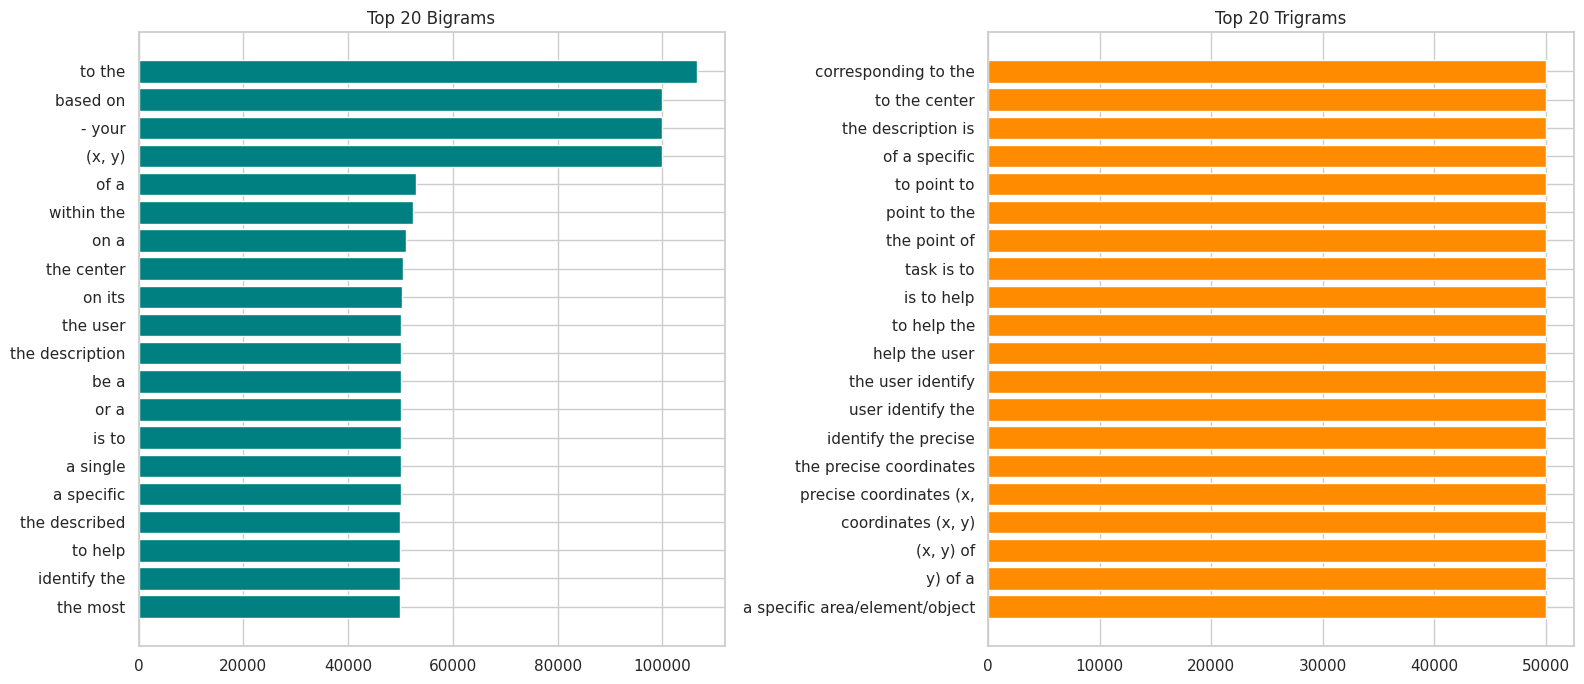


Most common trigram: 'corresponding to the' appears in 100.0% of REs
⚠️  High trigram concentration suggests templated generation


In [ ]:
from collections import Counter

def get_ngrams(text, n):
    words = text.lower().split()
    return [' '.join(words[i:i+n]) for i in range(len(words)-n+1)]

bigrams = Counter()
trigrams = Counter()

for re_text in referring_expressions:
    for bg in get_ngrams(re_text, 2):
        bigrams[bg] += 1
    for tg in get_ngrams(re_text, 3):
        trigrams[tg] += 1

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_bg = bigrams.most_common(20)
if top_bg:
    bg_labels, bg_counts = zip(*top_bg)
    axes[0].barh(bg_labels[::-1], bg_counts[::-1], color="teal")
    axes[0].set_title("Top 20 Bigrams")

top_tg = trigrams.most_common(20)
if top_tg:
    tg_labels, tg_counts = zip(*top_tg)
    axes[1].barh(tg_labels[::-1], tg_counts[::-1], color="darkorange")
    axes[1].set_title("Top 20 Trigrams")

plt.tight_layout()
plt.show()

# Template detection: if top trigram covers >5% of data, it's likely templated
if top_tg:
    top_tg_pct = top_tg[0][1] / total_res * 100
    print(f"\nMost common trigram: '{top_tg[0][0]}' appears in {top_tg_pct:.1f}% of REs")
    if top_tg_pct > 5:
        print("⚠️  High trigram concentration suggests templated generation")
    else:
        print("✓  Trigram distribution looks reasonably diverse")

## 9. Summary Report

Auto-generated bias audit summary.

In [ ]:
print("=" * 60)
print("  UGROUND-V1-DATA BIAS AUDIT SUMMARY")
print(f"  Split: {SPLIT} | Sample: {len(records):,} records")
print("=" * 60)

findings = []

# Element type concentration
if sorted_elements:
    top_element_pct = sorted_elements[0][1] / total * 100
    if top_element_pct > 25:
        findings.append(f"🔴 Element type '{sorted_elements[0][0]}' dominates at {top_element_pct:.1f}%")
    else:
        findings.append(f"🟢 No single element type exceeds 25% (top: {sorted_elements[0][0]} at {top_element_pct:.1f}%)")

# RE duplication
if dup_rate > 20:
    findings.append(f"🔴 High RE duplication rate: {dup_rate:.1f}%")
elif dup_rate > 10:
    findings.append(f"🟡 Moderate RE duplication rate: {dup_rate:.1f}%")
else:
    findings.append(f"🟢 Low RE duplication rate: {dup_rate:.1f}%")

# Spatial bias
if xs:
    max_quadrant_pct = max(q_vals)
    if max_quadrant_pct > 35:
        findings.append(f"🔴 Spatial bias detected: one quadrant has {max_quadrant_pct:.1f}% of elements")
    else:
        findings.append(f"🟢 Spatial distribution is reasonably balanced (max quadrant: {max_quadrant_pct:.1f}%)")

# Verb dominance
if top_verbs:
    top_verb_pct = top_verbs[0][1] / v_total * 100
    if top_verb_pct > 30:
        findings.append(f"🔴 Action verb '{top_verbs[0][0]}' dominates at {top_verb_pct:.1f}%")
    else:
        findings.append(f"🟢 Action verb distribution is balanced (top: '{top_verbs[0][0]}' at {top_verb_pct:.1f}%)")

# Resolution diversity
if resolutions:
    top_res_pct = res_counter.most_common(1)[0][1] / len(resolutions) * 100
    if top_res_pct > 50:
        findings.append(f"🔴 Resolution heavily concentrated: top resolution = {top_res_pct:.1f}%")
    else:
        findings.append(f"🟢 Resolution diversity is reasonable (top resolution = {top_res_pct:.1f}%)")

# Platform skew (known from paper)
findings.append("🟡 Known: ~95% web-sourced data — mobile/desktop coverage is limited")

print()
for f in findings:
    print(f"  {f}")
print()
print("=" * 60)
print("  Next steps:")
print("  • Increase SAMPLE_SIZE for higher confidence")
print("  • Run on 'web_direct' subset and compare")
print("  • Sample & visually inspect screenshots for domain diversity")
print("  • Cross-check against your downstream task's element needs")
print("=" * 60)

  UGROUND-V1-DATA BIAS AUDIT SUMMARY
  Split: train | Sample: 50,000 records

  🔴 Element type 'image/media' dominates at 38.1%
  🟢 Low RE duplication rate: 0.1%
  🔴 Spatial bias detected: one quadrant has 38.7% of elements
  🔴 Action verb 'identify' dominates at 47.6%
  🟢 Resolution diversity is reasonable (top resolution = 0.4%)
  🟡 Known: ~95% web-sourced data — mobile/desktop coverage is limited

  Next steps:
  • Increase SAMPLE_SIZE for higher confidence
  • Run on 'web_direct' subset and compare
  • Sample & visually inspect screenshots for domain diversity
  • Cross-check against your downstream task's element needs


In [ ]:
import os
import shutil
import time
import zipfile
import random
import json
import io
import textwrap
from PIL import Image
import matplotlib.pyplot as plt
from datasets import load_dataset

In [ ]:
# OBTAIN ZIP FILE PATH

# For the path below to work as intended, in the Google Drive web UI, go to "Shared with me", right-click the "Too CUA for School" folder → Organise →
# Add shortcut → pick a location (must be the root of "My Drive").
NOTEBOOK_DIR = "/content/drive/MyDrive/Too CUA for School/MS2"
ZIP_FILENAME = "jonathanliuground-v1-subsample.zip"

# Full path to the zip file on the mounted Drive.
DRIVE_ZIP_PATH = os.path.join(NOTEBOOK_DIR, ZIP_FILENAME)

# Verify that the zip file exists at the expected location.
assert os.path.isfile(DRIVE_ZIP_PATH), (
    f"Zip file not found at: {DRIVE_ZIP_PATH}\n"
    f"Please check NOTEBOOK_DIR and ZIP_FILENAME above."
)

# Print the file size so we know what we're working with.
zip_size_gb = os.path.getsize(DRIVE_ZIP_PATH) / (1024 ** 3)
print(f"Found zip file: {DRIVE_ZIP_PATH}")
print(f"Size: {zip_size_gb:.2f} GB")

Found zip file: /content/drive/MyDrive/Too CUA for School/MS2/jonathanliuground-v1-subsample.zip
Size: 14.29 GB


In [ ]:
# COPY THE ZIP FROM GOOGLE DRIVE TO COLAB SESSION STORAGE (Takes ~5 minutes)
# Copying the zip to `/content/` (Colab's local SSD) before extracting.
# This is much faster than extracting directly from the Drive FUSE mount,
# which has high latency for many small random reads.


# Destination path on Colab's local disk.
LOCAL_ZIP_PATH = f"/content/{ZIP_FILENAME}"
# The folder where extracted contents will live.
EXTRACT_DIR = "/content/jonathanliuground-v1-subsample"

# Only copy if the data directory doesn't already exist (avoids re-copying on cell re-runs).
if not os.path.exists(EXTRACT_DIR):
    print(f"Copying zip from Drive to Colab local storage...")
    start = time.time()  # Track how long the copy takes.

    # shutil.copy2 preserves file metadata and is the simplest way to
    # copy a single file in Python.
    shutil.copy2(DRIVE_ZIP_PATH, LOCAL_ZIP_PATH)

    elapsed = time.time() - start
    print(f"Copy complete in {elapsed:.0f} seconds.")
else:
    print(f"Data extract already present at {EXTRACT_DIR}, skipping copy.")

Data extract already present at /content/jonathanliuground-v1-subsample, skipping copy.


In [ ]:
# EXTRACT THE ZIP FILE INTO A LOCAL FOLDER (Takes ~3 minutes)

# Only extract if the folder doesn't already exist
# (avoids re-extracting on cell re-runs within the same session).
if not os.path.isdir(EXTRACT_DIR):
    print(f"Extracting {LOCAL_ZIP_PATH} ...")
    start = time.time()

    # Open the zip file for reading and extract all contents.
    with zipfile.ZipFile(LOCAL_ZIP_PATH, "r") as zf:
        zf.extractall("/content")  # Extracts into /content/<zip contents>

    elapsed = time.time() - start
    print(f"Extraction complete in {elapsed:.0f} seconds.")
else:
    print(f"Folder {EXTRACT_DIR} already exists, skipping extraction.")

# Walk the extracted directory and find all parquet files.
parquet_files = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    for f in files:
        if f.endswith(".parquet"):
            parquet_files.append(os.path.join(root, f))

print(f"\nFound {len(parquet_files)} parquet files.")

# Show the subfolder structure for reference.
subdirs = set(os.path.dirname(p).replace(EXTRACT_DIR, "").strip("/") for p in parquet_files)
subdirs = [s for s in subdirs if s]  # Remove empty strings (files at root level)
if subdirs:
    print(f"Subfolders containing parquet files:")
    for s in sorted(subdirs):
        count = sum(1 for p in parquet_files if s in p)
        print(f"  {s}/  ({count} files)")

Folder /content/jonathanliuground-v1-subsample already exists, skipping extraction.

Found 128 parquet files.
Subfolders containing parquet files:
  web_direct_150k_description_filtered/  (32 files)
  web_direct_258k_function_filtered/  (32 files)
  web_hybrid_773k_max_25qa_filtered/  (64 files)


In [ ]:
# Delete local zip copy after extraction (if it exists) to save disk space
if os.path.isfile(LOCAL_ZIP_PATH):
  os.remove(LOCAL_ZIP_PATH)
  print(f"Deleted {LOCAL_ZIP_PATH} to free disk space.")
else:
  print(f"No local copy of {LOCAL_ZIP_PATH} found.")

No local copy of /content/jonathanliuground-v1-subsample.zip found.


In [ ]:
# LOAD PARQUET FILES AND COMBINE THEM INTO A DATASET

# Load all parquet files from the extracted folder into a single Dataset.
# The glob pattern **/*.parquet matches parquet files in any subfolder.
# We specify split="train" to get a single Dataset object (not a DatasetDict).
ds = load_dataset(
    "parquet",                                        # Tell datasets to read raw parquet files
    data_files=f"{EXTRACT_DIR}/**/*.parquet",          # Glob pattern matching all parquet files
    split="train"                                      # Combine everything into one split
)

# Print a summary of what we loaded.
print(f"Dataset loaded: {len(ds)} rows")
print(f"Columns: {ds.column_names}")
print(ds)

Resolving data files:   0%|          | 0/128 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/32 [00:00<?, ?it/s]

Dataset loaded: 43392 rows
Columns: ['width', 'height', 'conversations', 'image']
Dataset({
    features: ['width', 'height', 'conversations', 'image'],
    num_rows: 43392
})


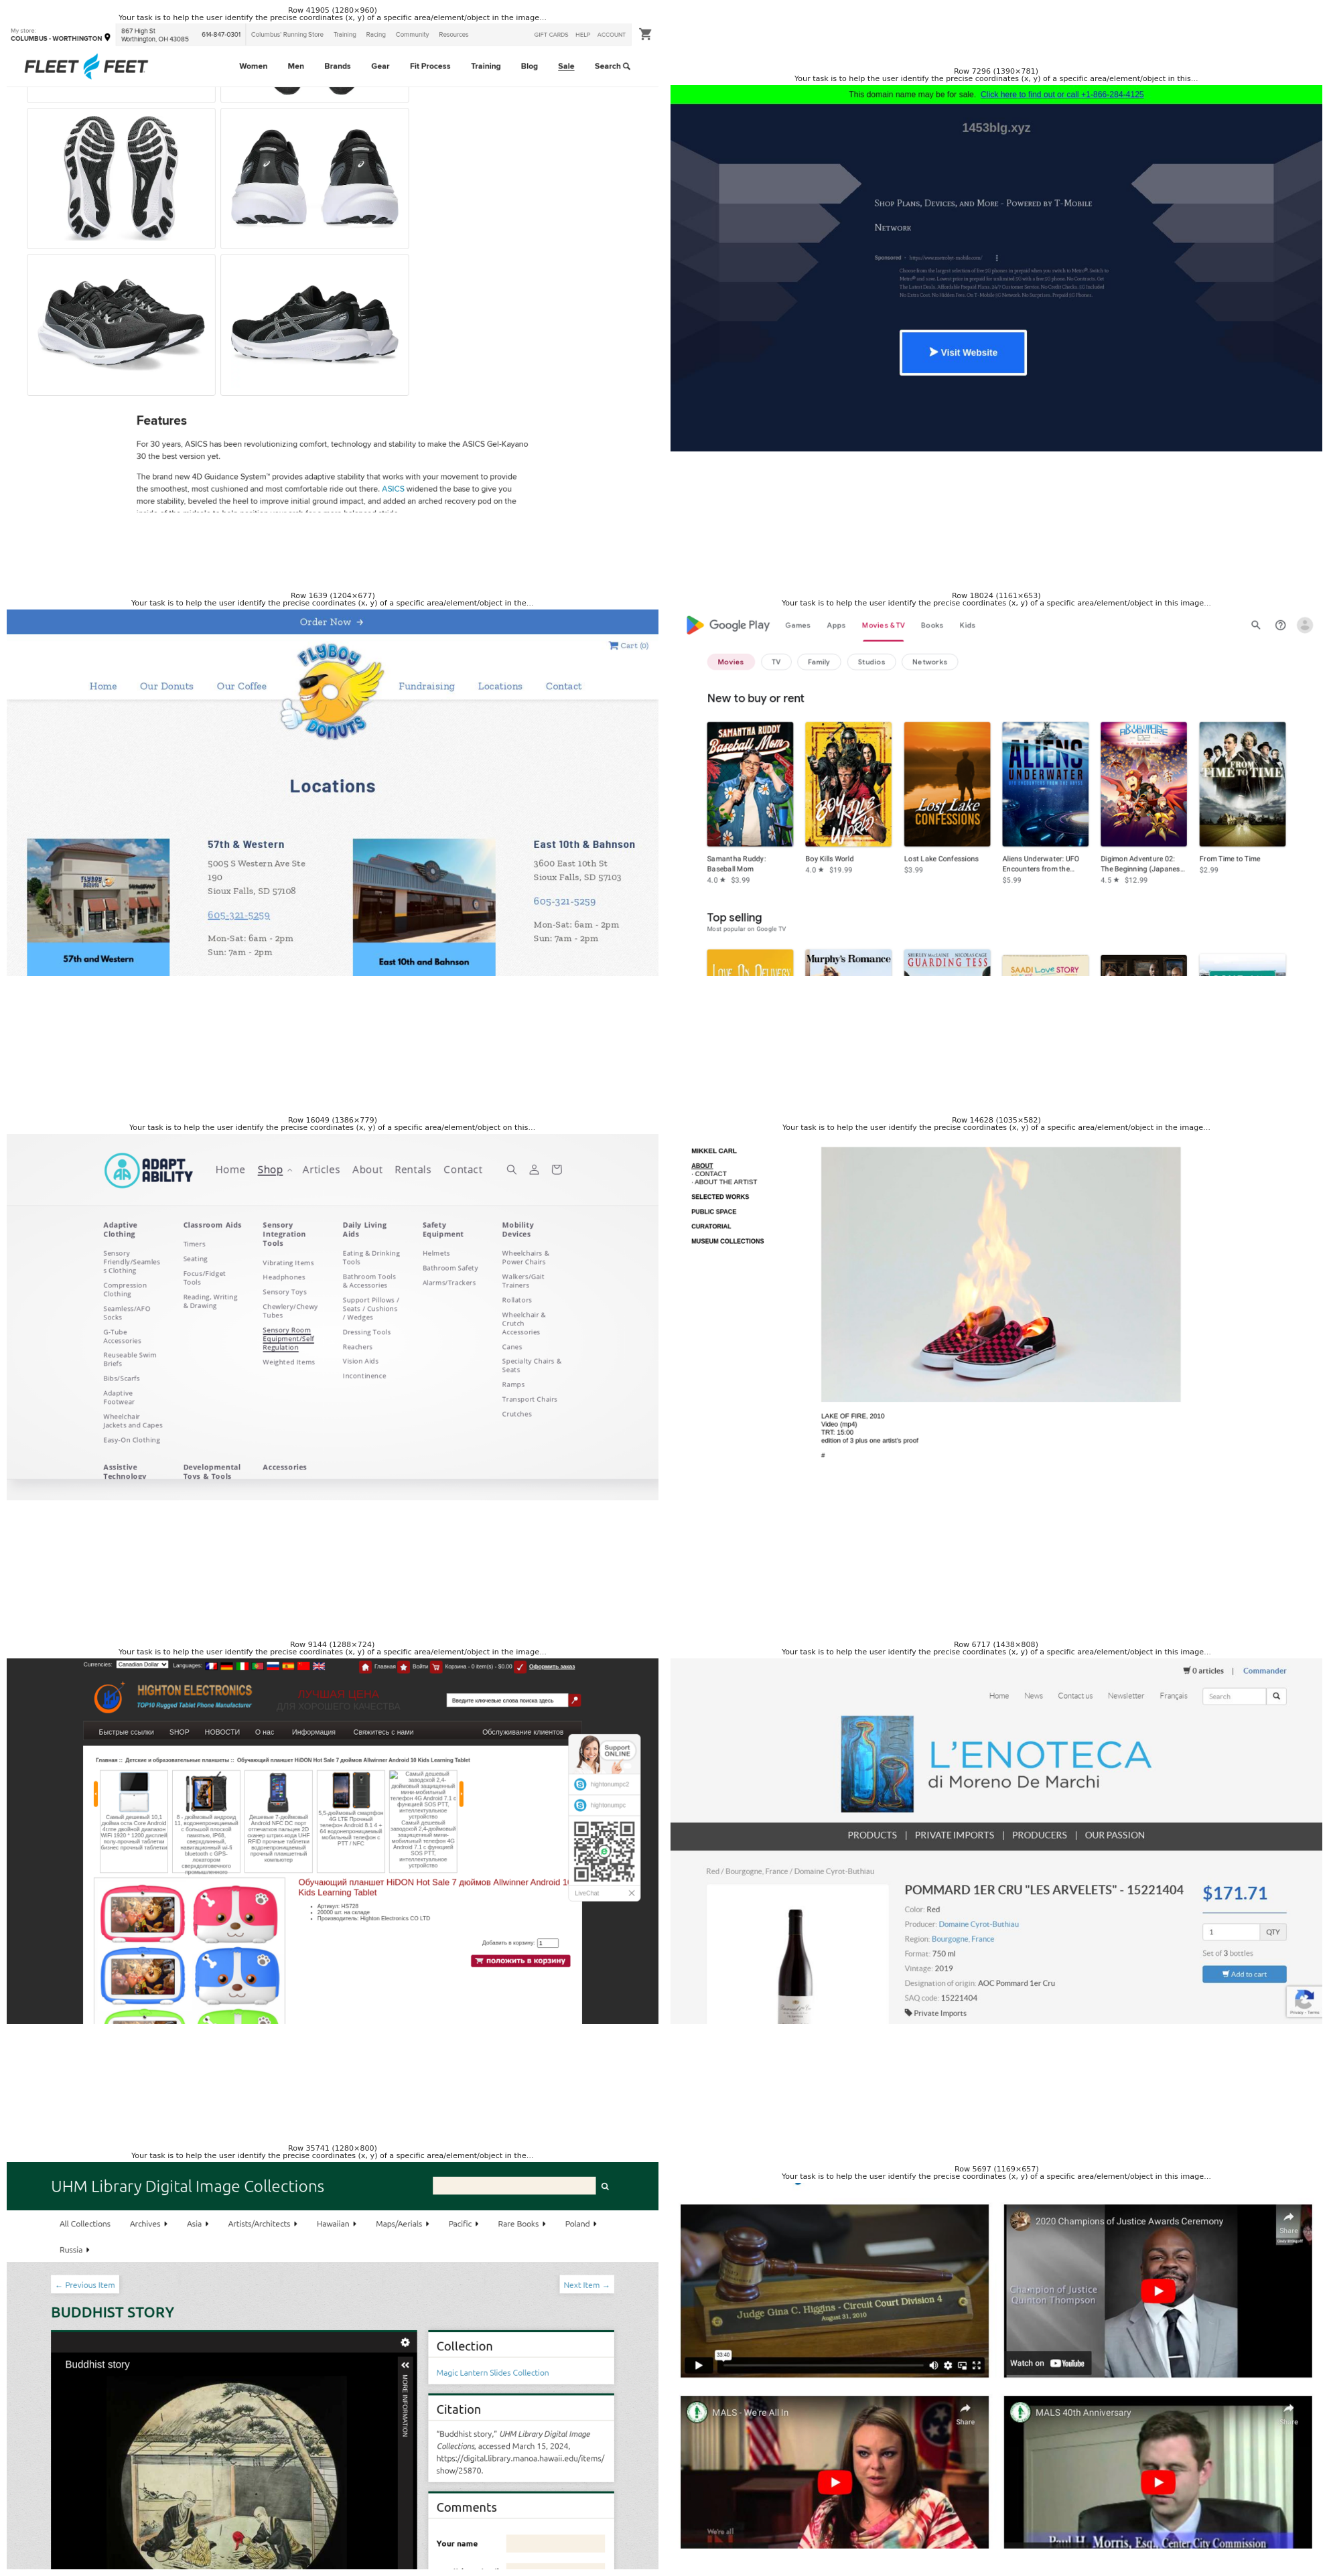

In [ ]:
# DISPLAY 10 RANDOM IMAGES
# Each row's image column contains raw image bytes (PNG or JPEG). We decode them with PIL and display them in a grid with matplotlib. The first line of the human conversation turn is shown as the title so you can see what grounding task is being asked.

# Set a seed for reproducibility. Remove this line to get a different
# random selection each time you run the cell.
random.seed(42)

# Pick 10 random row indices from the dataset.
indices = random.sample(range(len(ds)), 10)

# Create a 5-row × 2-column grid of subplots.
fig, axes = plt.subplots(5, 2, figsize=(20, 40))
axes = axes.flatten()  # Flatten the 2D array of axes into a 1D list for easy iteration.

for ax, idx in zip(axes, indices):
    # Fetch the row from the dataset.
    row = ds[idx]

    # --- Decode the image ---
    # The "image" field can be:
    #   (a) raw bytes (if datasets didn't auto-decode) → open with PIL
    #   (b) a PIL Image (if datasets auto-decoded the Image feature)
    #   (c) a dict like {"bytes": ..., "path": ...} (some datasets versions)
    img = row["image"]
    if isinstance(img, bytes):
        # Case (a): raw bytes → wrap in BytesIO and open as a PIL Image.
        img = Image.open(io.BytesIO(img))
    elif isinstance(img, dict) and "bytes" in img:
        # Case (c): dict with a "bytes" key → extract and open.
        img = Image.open(io.BytesIO(img["bytes"]))
    # Case (b): already a PIL Image, no conversion needed.

    # --- Parse the conversation JSON ---
    # The "conversations" column is a JSON string containing a list of turns.
    # Each turn looks like: {"from": "human" or "gpt", "value": "..."}
    convos = json.loads(row["conversations"])

    # Extract the human turn's text for use as the plot title.
    human_msg = convos[0]["value"] if convos else ""

    # Remove the <image> placeholder tag that appears at the start of the prompt.
    human_msg = human_msg.replace("<image>", "").strip()

    # Truncate long prompts so they fit as a subplot title.
    title = textwrap.shorten(human_msg, width=120, placeholder="...")

    # Display the image in the subplot.
    ax.imshow(img)

    # Set the title showing the row index, image dimensions, and the prompt.
    ax.set_title(
        f"Row {idx} ({row['width']}×{row['height']})\n{title}",
        fontsize=8,
        wrap=True
    )

    # Hide the axis ticks and labels for a cleaner look.
    ax.axis("off")

# Adjust spacing between subplots so titles don't overlap.
plt.tight_layout()

# Render the figure.
plt.show()

In [ ]:
# INSPECT A SINGLE SAMPLE IN DETAIL
# Shows an example of a full conversation structure for a given row. The human turn describes a UI element to locate, and the GPT turn provides the (x, y) coordinates normalised to [0, 999].

# Pick one of the 10 random indices we already selected.
sample_idx = indices[0]

# Fetch the row.
sample = ds[sample_idx]

# Print the metadata.
print(f"Row index : {sample_idx}")
print(f"Image size: {sample['width']} × {sample['height']}")

# Parse and print each conversation turn.
print(f"\n--- Conversations ---")
convos = json.loads(sample["conversations"])
for turn in convos:
    # Uppercase the role for readability (HUMAN / GPT).
    role = turn["from"].upper()

    # Replace the <image> tag with a readable placeholder.
    text = turn["value"].replace("<image>", "[IMAGE]").strip()

    print(f"\n[{role}]\n{text}")

Row index : 41905
Image size: 1280 × 960

--- Conversations ---

[HUMAN]
[IMAGE]Your task is to help the user identify the precise coordinates (x, y) of a specific area/element/object in the image based on a description.

- Your response should aim to point to the center or a representative point within the described area/element/object as accurately as possible.
- If the description is unclear or ambiguous, infer the most relevant area or element based on its likely context or purpose.
- Your answer should be a single string (x, y) corresponding to the point of interest.

Description: My Shopping Cart

Answer:

[GPT]
(979, 23)

[HUMAN]
Description: My store:
COLUMBUS - WORTHINGTON, Display Store Information

Answer:

[GPT]
(84, 23)

[HUMAN]
Description: Fleet Feet home logo graphic link

Answer:

[GPT]
(125, 88)

[HUMAN]
Description: button for "GIFT CARDS", on the left side of the webpage

Answer:

[GPT]
(836, 23)

[HUMAN]
Description: link for "Gear"

Answer:

[GPT]
(573, 88)

[HUMA

# Data Quality Analysis



### Sample Order

This section demonstrates a combined display for a single random row in the data, showing the image, its dimensions, and the conversation turns in the requested format.

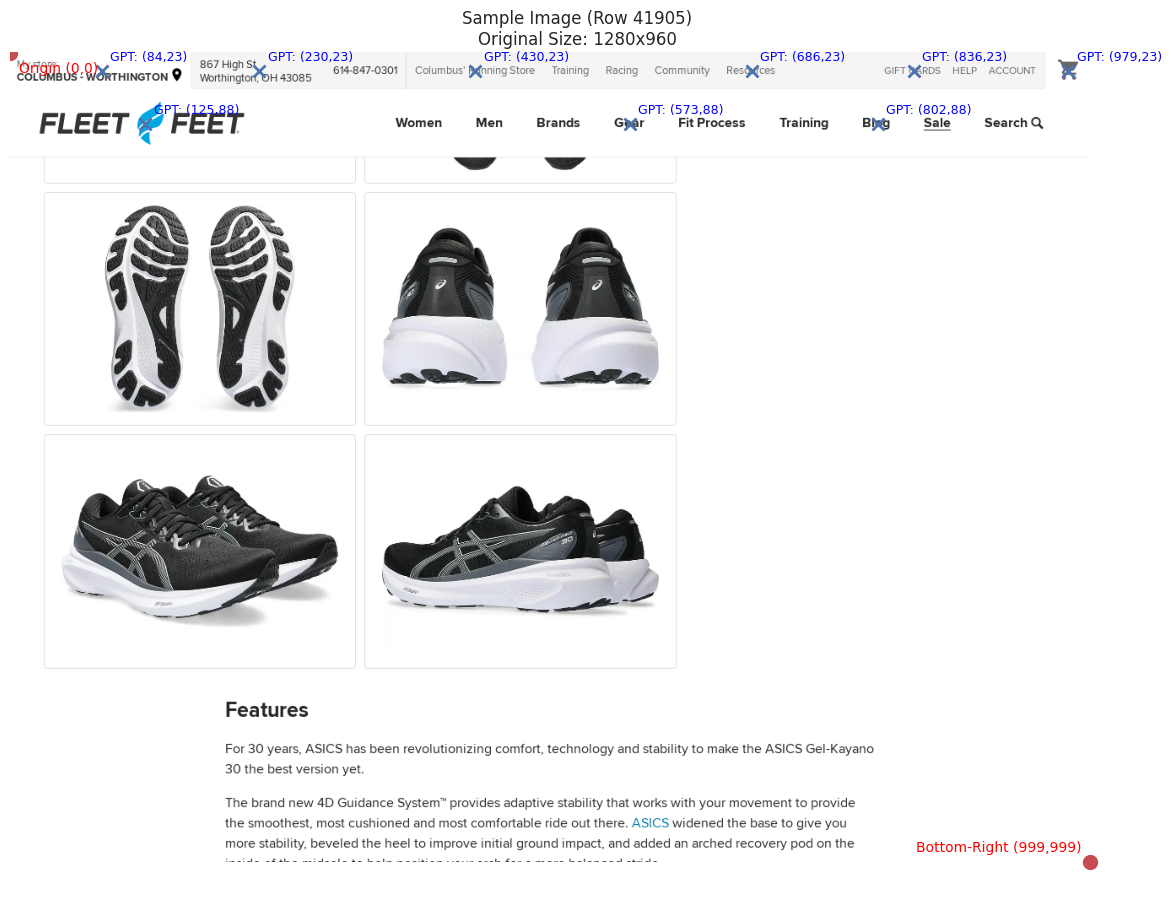

Image dimensions: Width=1280 pixels, Height=960 pixels

--- Conversations for Row 41905 ---
{ role: human, value: 'Your task is to help the user identify the precise coordinates (x, y) of a specific...' }
{ role: gpt, value: '(979, 23)' }
{ role: human, value: 'Description: My store: COLUMBUS - WORTHINGTON, Display Store Information Answer:' }
{ role: gpt, value: '(84, 23)' }
{ role: human, value: 'Description: Fleet Feet home logo graphic link Answer:' }
{ role: gpt, value: '(125, 88)' }
{ role: human, value: 'Description: button for "GIFT CARDS", on the left side of the webpage Answer:' }
{ role: gpt, value: '(836, 23)' }
{ role: human, value: 'Description: link for "Gear" Answer:' }
{ role: gpt, value: '(573, 88)' }
{ role: human, value: 'Description: Columbus' Running Store link, to the bottom left of "Men" Answer:' }
{ role: gpt, value: '(430, 23)' }
{ role: human, value: 'Description: Blog Answer:' }
{ role: gpt, value: '(802, 88)' }
{ role: human, value: 'Description: button lab

In [ ]:
import matplotlib.pyplot as plt
import io
from PIL import Image
import json
import textwrap

# Define the coordinate range for visualization
MIN_COORD = 0
MAX_COORD = 999

# We'll use the same sample_idx as before for consistency
# Ensure 'ds' and 'indices' are available from previous runs
if 'ds' not in locals() or 'indices' not in locals():
    print("Please run previous cells to load the dataset and select indices.")
    # Fallback if ds or indices are not defined for some reason
    # For this demonstration, we'll assume they are present. If not, this might error.
    if 'ds' not in locals():
        # This part would typically load ds if it wasn't already
        # For this example, we assume ds is loaded.
        pass
    if 'indices' not in locals():
        import random
        random.seed(42)
        indices = random.sample(range(len(ds)), 10)

sample_idx = indices[0] # Using the first selected random sample (e.g., 41905)
sample = ds[sample_idx]

# --- Display the image ---
# Decode the image
img = sample["image"]
if isinstance(img, bytes):
    img = Image.open(io.BytesIO(img))
elif isinstance(img, dict) and "bytes" in img:
    img = Image.open(io.BytesIO(img["bytes"]))

original_width = sample["width"]
original_height = sample["height"]

plt.figure(figsize=(12, 10))
plt.imshow(img)

# --- Visualize the (0,0) and (999,999) corners of the normalized grid ---
# Convert normalized corners to original pixel coordinates
pixel_0_0_x = int(round(MIN_COORD / MAX_COORD * original_width))
pixel_0_0_y = int(round(MIN_COORD / MAX_COORD * original_height))
pixel_999_999_x = int(round(MAX_COORD / MAX_COORD * original_width))
pixel_999_999_y = int(round(MAX_COORD / MAX_COORD * original_height))

# Plot the (0,0) origin
plt.plot(pixel_0_0_x, pixel_0_0_y, 'ro', markersize=10, label='(0,0) Origin (Normalized)')
plt.text(pixel_0_0_x + 10, pixel_0_0_y + 10, f'Origin (0,0)', color='red', fontsize=10, ha='left', va='top')

# Plot the (999,999) bottom-right corner
plt.plot(pixel_999_999_x, pixel_999_999_y, 'ro', markersize=10, label='(999,999) Bottom-Right (Normalized)')
plt.text(pixel_999_999_x - 10, pixel_999_999_y - 10, f'Bottom-Right (999,999)', color='red', fontsize=10, ha='right', va='bottom')


# --- Display dimensions and plot GPT conversation points ---
convos = json.loads(sample["conversations"])

# Collect GPT points for plotting
gpt_points = []
for turn_idx, turn in enumerate(convos):
    if turn["from"] == "gpt":
        value = turn["value"]
        match = re.fullmatch(r"\(([-]?\d+),\s*([-]?\d+)\)", value)
        if match:
            try:
                normalized_x = int(match.group(1))
                normalized_y = int(match.group(2))

                # Convert normalized coordinates to original pixel coordinates
                pixel_x = int(round(normalized_x / MAX_COORD * original_width))
                pixel_y = int(round(normalized_y / MAX_COORD * original_height))

                gpt_points.append(((pixel_x, pixel_y), (normalized_x, normalized_y)))
            except ValueError:
                pass # Skip if coordinates are not valid numbers

# Plot GPT points
for (px, py), (nx, ny) in gpt_points:
    plt.plot(px, py, 'bx', markersize=8, markeredgewidth=2) # Blue 'x' for GPT points
    plt.text(px + 10, py - 10, f'GPT: ({nx},{ny})', color='blue', fontsize=9, ha='left', va='bottom')


plt.title(f"Sample Image (Row {sample_idx})\nOriginal Size: {original_width}x{original_height}")
plt.axis("off")
plt.tight_layout()
plt.show()

# --- Display dimensions ---
print(f"Image dimensions: Width={original_width} pixels, Height={original_height} pixels")

# --- Display conversations in requested format ---
print(f"\n--- Conversations for Row {sample_idx} ---")
for turn in convos:
    role = turn["from"]
    # Clean the value, remove <image> and strip whitespace
    value = turn["value"].replace("<image>", "").strip()
    # For displaying, ensure multi-line values are presented on one line for brevity or wrapped
    display_value = textwrap.shorten(value.replace('\n', ' '), width=100, placeholder='...')
    print(f"{{ role: {role}, value: '{display_value}' }}")


### Image Size Analysis

Let's analyze the distribution of image widths and heights in the dataset, and identify the maximum dimensions.

Collected dimensions for 10000/43392 rows...
Collected dimensions for 20000/43392 rows...
Collected dimensions for 30000/43392 rows...
Collected dimensions for 40000/43392 rows...
Image dimension collection complete.

Maximum image width observed: 1455 pixels
Maximum image height observed: 1680 pixels


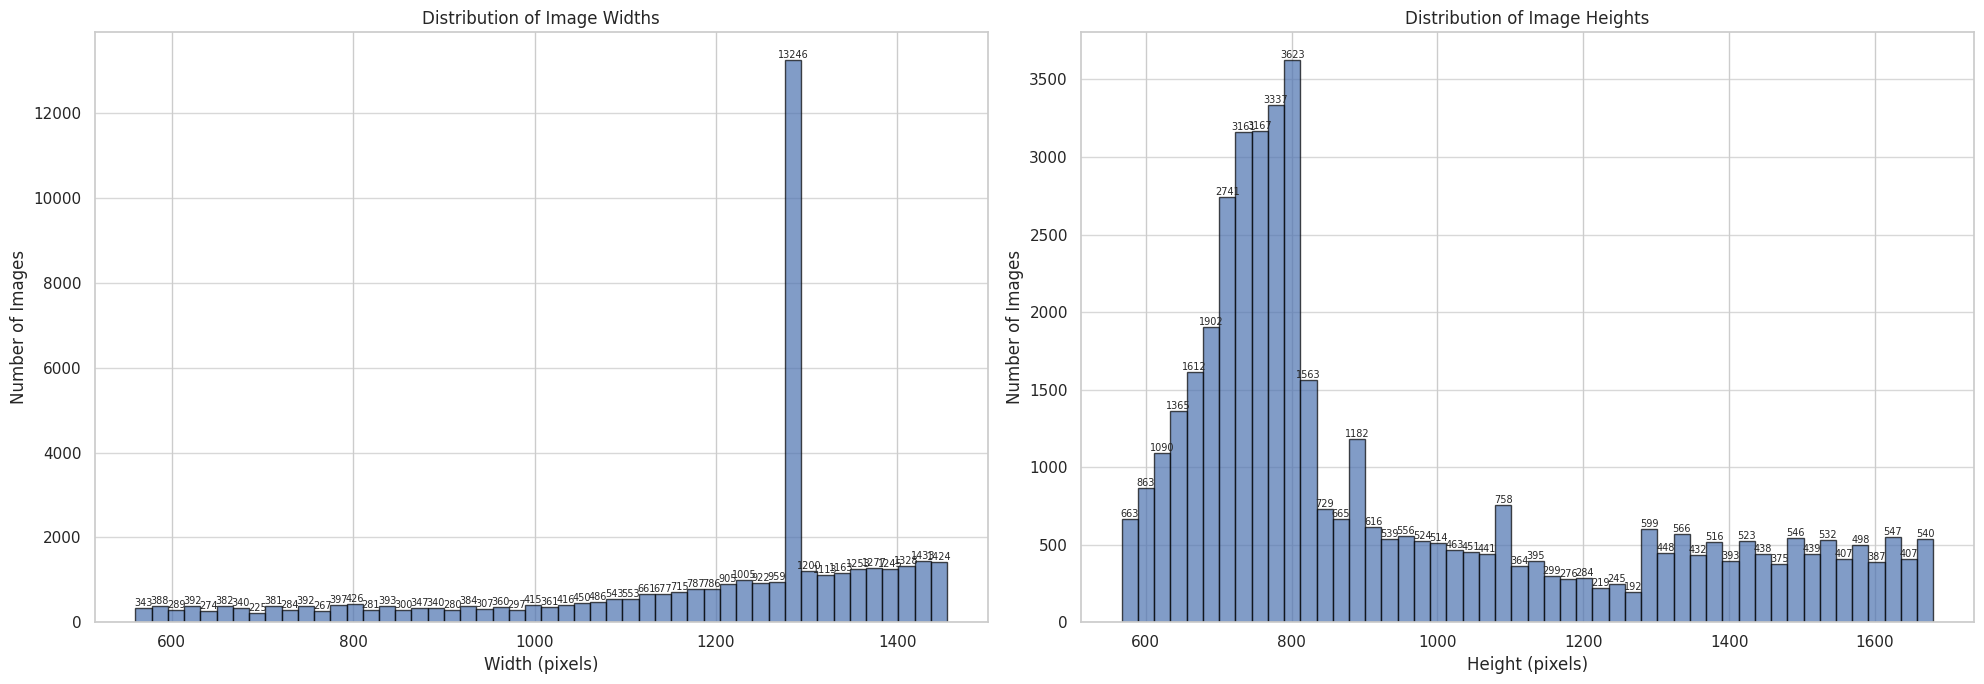

In [ ]:
image_widths = []
image_heights = []

print("Collecting image dimensions...")

for i, row in enumerate(ds):
    image_widths.append(row["width"])
    image_heights.append(row["height"])
    if (i + 1) % 10000 == 0:
        print(f"Collected dimensions for {i + 1}/{len(ds)} rows...")

print("Image dimension collection complete.")

max_width = max(image_widths)
max_height = max(image_heights)

print(f"\nMaximum image width observed: {max_width} pixels")
print(f"Maximum image height observed: {max_height} pixels")

# Create histograms
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Histogram for Widths
n_width, bins_width, patches_width = axes[0].hist(image_widths, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Image Widths')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Number of Images')
axes[0].grid(axis='y', alpha=0.75)
# Add labels on top of bars for widths
for i in range(len(patches_width)):
    if n_width[i] > 0: # Only label bars that have a count
        axes[0].text(patches_width[i].get_x() + patches_width[i].get_width() / 2,
                     patches_width[i].get_height(),
                     f'{int(n_width[i])}', ha='center', va='bottom', fontsize=7)

# Histogram for Heights
n_height, bins_height, patches_height = axes[1].hist(image_heights, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Image Heights')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Number of Images')
axes[1].grid(axis='y', alpha=0.75)
# Add labels on top of bars for heights
for i in range(len(patches_height)):
    if n_height[i] > 0: # Only label bars that have a count
        axes[1].text(patches_height[i].get_x() + patches_height[i].get_width() / 2,
                     patches_height[i].get_height(),
                     f'{int(n_height[i])}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

### Resolution Pairs Analysis

Let's count the occurrences of each unique (width, height) resolution pair in the dataset to understand the common image dimensions.

In [ ]:
import collections

resolution_pairs = []
for row in ds:
    resolution_pairs.append((row["width"], row["height"]))

resolution_counts = collections.Counter(resolution_pairs)

print("Top 10 most common resolution pairs:")
for pair, count in resolution_counts.most_common(10):
    print(f"  {pair[0]}x{pair[1]}: {count} occurrences")

print(f"\nTotal unique resolution pairs: {len(resolution_counts)}")


Top 10 most common resolution pairs:
  1280x720: 787 occurrences
  1280x740: 716 occurrences
  1280x780: 713 occurrences
  1280x760: 710 occurrences
  1280x800: 683 occurrences
  1280x820: 646 occurrences
  1280x840: 625 occurrences
  1280x860: 581 occurrences
  1280x880: 557 occurrences
  1280x920: 534 occurrences

Total unique resolution pairs: 6982


### Conversation Turns Analysis

Analyzing how many conversations are in each row of data and the distribution (e.g. if some have 2 conversations vs 10 conversations)

Calculating conversation lengths...
Processed 10000/43392 rows...
Processed 20000/43392 rows...
Processed 30000/43392 rows...
Processed 40000/43392 rows...
Conversation length calculation complete.


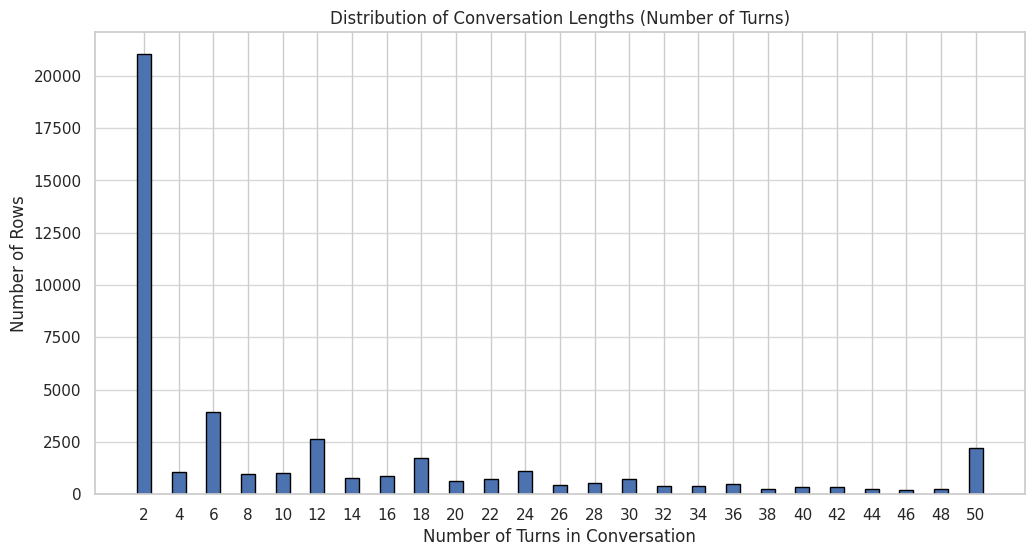

In [ ]:
import collections
import matplotlib.pyplot as plt

conversation_lengths = []

print("Calculating conversation lengths...")

for i, row in enumerate(ds):
    try:
        convos = json.loads(row["conversations"])
        conversation_lengths.append(len(convos))
    except json.JSONDecodeError:
        # Handle rows where JSON might be malformed (though our earlier check found none)
        print(f"Warning: Could not parse conversations for row {i}")
        conversation_lengths.append(0) # Assign 0 or -1 for unparseable entries
    if (i + 1) % 10000 == 0:
        print(f"Processed {i + 1}/{len(ds)} rows...")

print("Conversation length calculation complete.")

# Using collections.Counter and plt.bar for clearer discrete counts
length_counts = collections.Counter(conversation_lengths)
sorted_lengths = sorted(length_counts.keys())
counts = [length_counts[length] for length in sorted_lengths]

plt.figure(figsize=(12, 6))
plt.bar(sorted_lengths, counts, edgecolor='black', align='center', width=0.8) # Use bar plot
plt.title('Distribution of Conversation Lengths (Number of Turns)')
plt.xlabel('Number of Turns in Conversation')
plt.ylabel('Number of Rows')
plt.xticks(sorted_lengths) # Set ticks directly at the center of each bar for each length
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
import json
import re

# List to store information about non-conforming GPT responses
non_coordinate_gpt_responses = []

# Define the expected coordinate range
MIN_COORD = 0
MAX_COORD = 999

print("Starting analysis for non-conforming GPT coordinate responses...")

for i, row in enumerate(ds):
    try:
        convos = json.loads(row["conversations"])
        for turn_idx, turn in enumerate(convos):
            if turn.get("from") == "gpt":
                value = turn.get("value", "").strip()

                # Updated regex to allow for optional negative signs before digits
                match = re.fullmatch(r"\(([-]?\d+),\s*([-]?\d+)\)", value)

                if match:
                    try:
                        x = int(match.group(1))
                        y = int(match.group(2))
                        # Explicitly check if coordinates are within the expected range
                        if not (MIN_COORD <= x <= MAX_COORD and MIN_COORD <= y <= MAX_COORD):
                            non_coordinate_gpt_responses.append(
                                (i, turn_idx, value, f"Coordinates out of bounds: ({x},{y})")
                            )
                    except ValueError:
                        # This catch-all is less likely now with the updated regex, but good practice
                        non_coordinate_gpt_responses.append(
                            (i, turn_idx, value, "Non-numeric coordinate values despite regex match")
                        )
                else:
                    # This GPT response does not fit the (x, y) format at all
                    non_coordinate_gpt_responses.append(
                        (i, turn_idx, value, "Does not match (x, y) coordinate format")
                    )

    except json.JSONDecodeError:
        non_coordinate_gpt_responses.append((i, -1, "N/A", "JSON parsing error in conversations"))

    if (i + 1) % 10000 == 0:
        print(f"Processed {i + 1}/{len(ds)} rows...")

print("\n--- Non-conforming GPT Coordinate Responses Analysis Results ---")
print(f"Total rows processed: {len(ds)}")

if non_coordinate_gpt_responses:
    print(f"Found {len(non_coordinate_gpt_responses)} issues where GPT responses were not valid (x, y) coordinates within [0, 999].")
    print("Examples (row_idx, turn_idx, actual_value, issue):")
    for issue in non_coordinate_gpt_responses[:10]: # Display up to 10 examples
        print(f"  Row {issue[0]}, Turn {issue[1]}: '{issue[2]}' -> {issue[3]}")
else:
    print("No issues found: All GPT responses in the dataset conform to the (x, y) coordinate format within the [0, 999] range.")

print("Analysis complete.")

Starting analysis for non-conforming GPT coordinate responses...
Processed 10000/43392 rows...
Processed 20000/43392 rows...
Processed 30000/43392 rows...
Processed 40000/43392 rows...

--- Non-conforming GPT Coordinate Responses Analysis Results ---
Total rows processed: 43392
Found 5 issues where GPT responses were not valid (x, y) coordinates within [0, 999].
Examples (row_idx, turn_idx, actual_value, issue):
  Row 10083, Turn 1: '(95, -25)' -> Coordinates out of bounds: (95,-25)
  Row 10837, Turn 1: '(503, -29)' -> Coordinates out of bounds: (503,-29)
  Row 11033, Turn 1: '(-137, 73)' -> Coordinates out of bounds: (-137,73)
  Row 11205, Turn 1: '(685, -25)' -> Coordinates out of bounds: (685,-25)
  Row 17144, Turn 1: '(501, -13)' -> Coordinates out of bounds: (501,-13)
Analysis complete.


### Data Cleaning and Processing

Analyzes the dataset for problems such as out of bound values, outlier values, missing images, improper formatting of output labels, and more.

In [ ]:
import json
import io
from PIL import Image, UnidentifiedImageError # Import UnidentifiedImageError
import re
import numpy as np

# Initialize lists to store issues found
missing_data = []
invalid_dimensions = []
malformed_coordinates = []
empty_expressions = []
invalid_conversation_structure = []
unreadable_images = [] # New list for unreadable images
unknown_image_formats = [] # New list for unexpected image formats (e.g., not PNG/JPEG)
image_formats = [] # New list to store all identified image formats
unexpected_coords_in_human_turns = [] # New list for human turns containing coordinates
missing_image_token_in_human_turns = [] # New list for human turns missing '<image>'

# Define the coordinate range for validation
MIN_COORD = 0
MAX_COORD = 999

print("Starting comprehensive data quality analysis...")

for i, row in enumerate(ds):
    # --- Check for missing data (image, width, height, conversations) ---
    image_present = True
    if row["image"] is None or (isinstance(row["image"], bytes) and not row["image"]) or \
       (isinstance(row["image"], dict) and "bytes" in row["image"] and not row["image"]["bytes"]):
        missing_data.append((i, "image"))
        image_present = False

    if row["width"] is None:
        missing_data.append((i, "width"))
    if row["height"] is None:
        missing_data.append((i, "height"))
    if row["conversations"] is None or not row["conversations"].strip():
        missing_data.append((i, "conversations"))

    # --- Check for invalid dimensions (zero or negative) ---
    if row["width"] is not None and row["width"] <= 0:
        invalid_dimensions.append((i, "width", row["width"]))
    if row["height"] is not None and row["height"] <= 0:
        invalid_dimensions.append((i, "height", row["height"]))

    # --- Attempt to load image to check for corruption/validity and format ---
    if image_present:
        img_data = row["image"]
        if isinstance(img_data, dict) and "bytes" in img_data:
            img_data = img_data["bytes"]

        if img_data:
            try:
                img = Image.open(io.BytesIO(img_data))
                img.verify() # Verify image integrity

                # Collect image format
                if img.format:
                    image_formats.append(img.format)

                if img.format not in ['PNG', 'JPEG']:
                    unknown_image_formats.append((i, img.format))
                img.close() # Close to free resources
            except (IOError, UnidentifiedImageError, OSError) as e:
                unreadable_images.append((i, str(e)))
        else:
            # This case should ideally be caught by missing_data['image']
            pass

    # --- Check for malformed coordinates, empty expressions, and conversation structure ---
    try:
        convos = json.loads(row["conversations"])

        # Check for even number of turns and correct alternation (human, gpt, human, gpt...)
        if len(convos) % 2 != 0:
            invalid_conversation_structure.append((i, "Odd number of turns"))

        for turn_idx, turn in enumerate(convos):
            expected_role = "human" if turn_idx % 2 == 0 else "gpt"
            if turn.get("from") != expected_role:
                invalid_conversation_structure.append(
                    (i, f"Turn {turn_idx}: Expected '{expected_role}', got '{turn.get("from")}'")
                )

            # Check for empty expressions
            if not turn.get("value", "").strip():
                empty_expressions.append((i, turn_idx, turn.get("from", "unknown")))

            # Check coordinates (only in GPT turns)
            if turn.get("from") == "gpt":
                value = turn.get("value", "").strip()
                match = re.fullmatch(r"\(([-]?\d+),\s*([-]?\d+)\)", value)

                if match:
                    try:
                        x = int(match.group(1))
                        y = int(match.group(2))
                        if not (MIN_COORD <= x <= MAX_COORD and MIN_COORD <= y <= MAX_COORD):
                            malformed_coordinates.append(
                                (i, turn_idx, value, f"Coordinates out of bounds: ({x},{y})")
                            )
                    except ValueError:
                        malformed_coordinates.append(
                            (i, turn_idx, value, "Non-numeric coordinate values despite regex match")
                        )
                else:
                    malformed_coordinates.append(
                        (i, turn_idx, value, "Does not match (x, y) coordinate format")
                    )

            # New check: Human turns should not contain coordinates
            elif turn.get("from") == "human":
                value = turn.get("value", "").strip()
                # Check if the human turn's value looks like a coordinate
                if re.search(r"\(([-]?\d+),\s*([-]?\d+)\)", value):
                    unexpected_coords_in_human_turns.append((i, turn_idx, value))

                # New check: Human turns should contain '<image>' token
                if "<image>" not in value and i not in [issue[0] for issue in missing_image_token_in_human_turns]: # Avoid duplicate reporting for the same row
                    missing_image_token_in_human_turns.append((i, turn_idx, value))

    except (json.JSONDecodeError, TypeError): # Added TypeError for cases where row["conversations"] might not be a string
        missing_data.append((i, "conversations_json_parse_error"))

    if (i + 1) % 10000 == 0:
        print(f"Processed {i + 1}/{len(ds)} rows...")

print("\n--- Comprehensive Data Quality Analysis Results ---")
print(f"Total rows processed: {len(ds)}")

print(f"\nMissing or empty data fields: {len(missing_data)} issues")
if missing_data:
    print(f"  Examples: {missing_data[:5]}...")

print(f"\nInvalid image dimensions (zero or negative): {len(invalid_dimensions)} issues")
if invalid_dimensions:
    print(f"  Examples: {invalid_dimensions[:5]}...")

print(f"\nUnreadable images (corrupted or invalid format): {len(unreadable_images)} issues")
if unreadable_images:
    print(f"  Examples: {unreadable_images[:5]}...")

print(f"\nImages with unexpected format (not PNG/JPEG): {len(unknown_image_formats)} issues")
if unknown_image_formats:
    print(f"  Examples: {unknown_image_formats[:5]}...")

# New check for consistent image format
if image_formats:
    unique_formats = set(image_formats)
    if len(unique_formats) == 1:
        print(f"\nAll images have a consistent format: {list(unique_formats)[0]}")
    else:
        print(f"\nImages have mixed formats. Found {len(unique_formats)} unique formats: {unique_formats}")
else:
    print("\nNo image formats were identified (possibly due to missing/unreadable images).")

print(f"\nMalformed or out-of-bounds coordinates: {len(malformed_coordinates)} issues")
if malformed_coordinates:
    print("  Examples (row_idx, turn_idx, actual_value, issue):")
    for issue in malformed_coordinates[:5]:
        print(f"    {issue}")

print(f"\nEmpty conversation expressions: {len(empty_expressions)} issues")
if empty_expressions:
    print("  Examples (row_idx, turn_idx, speaker):")
    for issue in empty_expressions[:5]:
        print(f"    {issue}")

print(f"\nInvalid conversation structure (e.g., odd turns, wrong order): {len(invalid_conversation_structure)} issues")
if invalid_conversation_structure:
    print(f"  Examples: {invalid_conversation_structure[:5]}...")

# Print results for new checks
print(f"\nUnexpected coordinates found in human turns: {len(unexpected_coords_in_human_turns)} issues")
if unexpected_coords_in_human_turns:
    print("  Examples (row_idx, turn_idx, value):")
    for issue in unexpected_coords_in_human_turns[:5]:
        print(f"    {issue}")

print(f"\nMissing '<image>' token in human turns: {len(missing_image_token_in_human_turns)} issues")
if missing_image_token_in_human_turns:
    print("  Examples (row_idx, turn_idx, value):")
    for issue in missing_image_token_in_human_turns[:5]:
        print(f"    {issue}")

print("Analysis complete.")

# --- Removing problematic rows ---
# Consolidate all unique problematic row indices
problematic_indices = set()

# Add indices from malformed_coordinates (which includes out-of-bounds)
for issue in malformed_coordinates:
    problematic_indices.add(issue[0])

# Add indices from unexpected_coords_in_human_turns
for issue in unexpected_coords_in_human_turns:
    problematic_indices.add(issue[0])

# Add indices from missing_image_token_in_human_turns
for issue in missing_image_token_in_human_turns:
    problematic_indices.add(issue[0])

# Convert to a sorted list for consistent reporting
problematic_indices_list = sorted(list(problematic_indices))

print(f"\nTotal unique problematic rows identified for removal: {len(problematic_indices_list)}")

# Create a boolean array indicating which rows to keep
indices_to_keep = np.ones(len(ds), dtype=bool)
for idx in problematic_indices_list:
    indices_to_keep[idx] = False

# Filter the dataset to create a cleaned version - WE SHOULD USE THIS GOING FORWARD?
ds_cleaned = ds.filter(lambda example, idx: indices_to_keep[idx], with_indices=True)

# Create a dataset of just the problematic rows for inspection
ds_problematic = ds.filter(lambda example, idx: not indices_to_keep[idx], with_indices=True)

print(f"Original dataset size: {len(ds)} rows")
print(f"Number of rows removed: {len(problematic_indices_list)}")
print(f"Cleaned dataset size: {len(ds_cleaned)} rows")
print(f"Problematic dataset size (rows that were removed): {len(ds_problematic)} rows")


Starting comprehensive data quality analysis...
Processed 10000/43392 rows...
Processed 20000/43392 rows...
Processed 30000/43392 rows...
Processed 40000/43392 rows...

--- Comprehensive Data Quality Analysis Results ---
Total rows processed: 43392

Missing or empty data fields: 0 issues

Invalid image dimensions (zero or negative): 0 issues

Unreadable images (corrupted or invalid format): 0 issues

Images with unexpected format (not PNG/JPEG): 0 issues

All images have a consistent format: PNG

Malformed or out-of-bounds coordinates: 5 issues
  Examples (row_idx, turn_idx, actual_value, issue):
    (10083, 1, '(95, -25)', 'Coordinates out of bounds: (95,-25)')
    (10837, 1, '(503, -29)', 'Coordinates out of bounds: (503,-29)')
    (11033, 1, '(-137, 73)', 'Coordinates out of bounds: (-137,73)')
    (11205, 1, '(685, -25)', 'Coordinates out of bounds: (685,-25)')
    (17144, 1, '(501, -13)', 'Coordinates out of bounds: (501,-13)')

Empty conversation expressions: 0 issues

Invalid co

### Explanation of Coordinate Scaling (0 to 999)

The dataset description mentions that grounding coordinates are normalized to `[0, 999]` in Qwen2-VL format. This means that regardless of an image's original `width` and `height`, the `(x, y)` coordinates provided in the GPT turns within the `conversations` are scaled to fit within a 1000x1000 grid.

To convert these normalized coordinates back to the original image's pixel dimensions, you can use a simple scaling factor:

*   `original_x = normalized_x / 999 * original_width`
*   `original_y = normalized_y / 999 * original_height`

Let's take the previously inspected sample and demonstrate this conversion.

In [ ]:
import json

# We'll use the same sample_idx as before for consistency
sample_idx = indices[0] # This was 41905 in the previous run
sample = ds[sample_idx]

# Get original image dimensions
original_width = sample["width"]
original_height = sample["height"]

# Parse conversations
convos = json.loads(sample["conversations"])

# Find the first GPT turn with coordinates
normalized_x = None
normalized_y = None
for turn in convos:
    if turn["from"] == "gpt":
        value = turn["value"]
        # Coordinates are expected in the format '(x, y)'
        if value.startswith('(') and value.endswith(')'):
            coord_str = value[1:-1]
            try:
                normalized_x, normalized_y = map(int, coord_str.split(','))
                break # Found the first one, exit loop
            except ValueError:
                pass # Not a valid coordinate pair, continue searching

if normalized_x is not None and normalized_y is not None:
    # Calculate original coordinates
    original_x = int(round(normalized_x / 999 * original_width))
    original_y = int(round(normalized_y / 999 * original_height))

    print(f"Original Image Size: {original_width}x{original_height}")
    print(f"Normalized Coordinate (0-999): ({normalized_x}, {normalized_y})")
    print(f"Converted Original Pixel Coordinate: ({original_x}, {original_y})")
else:
    print(f"Could not find a valid GPT coordinate in sample {sample_idx}.")


Original Image Size: 1280x960
Normalized Coordinate (0-999): (979, 23)
Converted Original Pixel Coordinate: (1254, 22)


### Training Preprocessing: Standardization & Coordinate Adjustment

When we standardize images for training (e.g., pad them to a fixed 512x512 square tensor), the relative position of the UI elements shifts on the new canvas. This code demonstrates how to pad the image and mathematically adjust the `[0, 999]` ground-truth coordinates so they remain accurate.

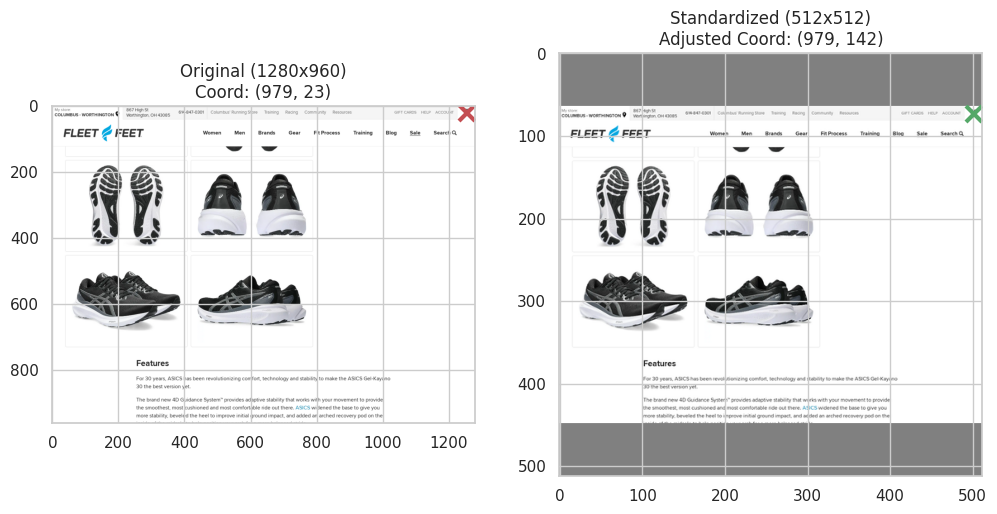

In [ ]:
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import json
import io
import re

TARGET_RESOLUTION = 512 # Standardize to 512x512 for training

def standardize_sample_for_training(img, original_coords_999):
    orig_w, orig_h = img.size

    # 1. Calculate scale factor to fit within TARGET_RESOLUTION
    scale = min(TARGET_RESOLUTION / orig_w, TARGET_RESOLUTION / orig_h)
    new_w = int(orig_w * scale)
    new_h = int(orig_h * scale)

    # 2. Resize image
    resized_img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)

    # 3. Create target canvas and paste resized image (padding)
    pad_x = (TARGET_RESOLUTION - new_w) // 2
    pad_y = (TARGET_RESOLUTION - new_h) // 2
    standardized_img = Image.new("RGB", (TARGET_RESOLUTION, TARGET_RESOLUTION), (128, 128, 128))
    standardized_img.paste(resized_img, (pad_x, pad_y))

    # 4. Adjust the coordinates
    adjusted_coords_999 = []
    for (nx, ny) in original_coords_999:
        # Convert normalized [0,999] to original pixels
        px = nx / 999.0 * orig_w
        py = ny / 999.0 * orig_h

        # Scale to resized pixels and add padding offset
        new_px = (px * scale) + pad_x
        new_py = (py * scale) + pad_y

        # Convert back to normalized [0,999] relative to the NEW padded canvas
        new_nx = int(round((new_px / TARGET_RESOLUTION) * 999))
        new_ny = int(round((new_py / TARGET_RESOLUTION) * 999))
        adjusted_coords_999.append((new_nx, new_ny))

    return standardized_img, adjusted_coords_999

# --- Test it on our sample ---
sample = ds[indices[0]]
img = Image.open(io.BytesIO(sample["image"]["bytes"] if isinstance(sample["image"], dict) else sample["image"])).convert("RGB")

# Extract first GPT coordinate
orig_coords = []
for turn in json.loads(sample["conversations"]):
    if turn["from"] == "gpt":
        match = re.fullmatch(r"\(([-]?\d+),\s*([-]?\d+)\)", turn["value"].strip())
        if match:
            orig_coords.append((int(match.group(1)), int(match.group(2))))
            break

standardized_img, adjusted_coords = standardize_sample_for_training(img, orig_coords)

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Original
axes[0].imshow(img)
orig_px = orig_coords[0][0] / 999.0 * img.width
orig_py = orig_coords[0][1] / 999.0 * img.height
axes[0].plot(orig_px, orig_py, 'rx', markersize=12, markeredgewidth=3)
axes[0].set_title(f"Original ({img.width}x{img.height})\nCoord: {orig_coords[0]}")

# Standardized
axes[1].imshow(standardized_img)
adj_px = adjusted_coords[0][0] / 999.0 * TARGET_RESOLUTION
adj_py = adjusted_coords[0][1] / 999.0 * TARGET_RESOLUTION
axes[1].plot(adj_px, adj_py, 'gx', markersize=12, markeredgewidth=3)
axes[1].set_title(f"Standardized ({TARGET_RESOLUTION}x{TARGET_RESOLUTION})\nAdjusted Coord: {adjusted_coords[0]}")

plt.show()


# Qwen2-VL-2B Zero-Shot Baseline on UGround Training Data

This section downloads the pretrained **Qwen2-VL-2B-Instruct** weights from
the HuggingFace Hub and runs zero-shot inference on a sample of the UGround
training data we loaded into `ds` above. It then reports a full battery of
GUI-grounding metrics so we have a concrete baseline to compare our
LoRA-fine-tuned Florence-2 against (the central comparison in our research
question).

**Why the *training* data?** Our research question is about whether a small
fine-tuned model can match a *larger zero-shot* model on the same
distribution of grounding tasks. Running the 2B baseline on the same data
the small model will be fine-tuned on gives us an apples-to-apples upper
bound for the size advantage, before we even introduce a held-out test set.

**Reported metrics**
- *Format compliance*: parse rate, out-of-bounds rate
- *Distance error*: mean / median Euclidean error in normalized [0,999]
  space and in original pixels
- *Accuracy at thresholds*: pixel thresholds (5, 10, 25, 50, 100, 200 px),
  normalized thresholds, and image-diagonal-relative thresholds
- *Throughput*: seconds per sample

**Runtime**
~1-2 sec/sample on a T4 GPU. The default `N_EVAL_SAMPLES = 500` takes
roughly 10-15 minutes; bump it up for tighter confidence intervals once
you trust the pipeline.

In [ ]:
# ============================================================
# Install dependencies for Qwen2-VL inference
# ============================================================
# - transformers >= 4.45.0 has native Qwen2-VL classes
# - qwen-vl-utils is the official helper for image preprocessing
# - accelerate enables device_map="auto" for memory-efficient loading
# The -q flag keeps Colab's output tidy.
!pip install -q "transformers>=4.45.0" "accelerate>=0.34.0" qwen-vl-utils

In [ ]:
# ============================================================
# Load the Qwen2-VL-2B-Instruct model and processor
# ============================================================
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

# Model identifier on the Hugging Face Hub. The "Instruct" variant is
# instruction-tuned and is what we want for zero-shot prompting (vs. the
# base completion model). 2B refers to ~2 billion parameters - the smallest
# in the Qwen2-VL family, and the exact baseline our paper compares against.
MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"

# bfloat16 is preferred over float16 for VLMs because it has float32's
# dynamic range, avoiding overflow in attention scores. It cuts memory
# roughly in half vs float32, putting the 2B model at ~4-5 GB of GPU RAM -
# comfortably within a free-tier T4's 15 GB. Fall back to fp16 if the GPU
# (e.g. older Tesla cards) doesn't support bf16, or fp32 on CPU.
if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
    DTYPE = torch.bfloat16
elif torch.cuda.is_available():
    DTYPE = torch.float16
else:
    DTYPE = torch.float32  # CPU fallback - inference will be VERY slow.

# device_map="auto" lets `accelerate` shard the model across available
# devices. On a single GPU it just goes to cuda:0; on CPU-only it stays
# on CPU. This is the recommended pattern for VLMs.
DEVICE_MAP = "auto" if torch.cuda.is_available() else None

print(f"Loading {MODEL_ID}...")
print(f"  dtype     : {DTYPE}")
print(f"  device_map: {DEVICE_MAP}")
print(f"  CUDA avail: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU name  : {torch.cuda.get_device_name(0)}")
    print(f"  GPU mem   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# Download (~4-5 GB on first run) and load weights. Subsequent runs use
# the local cache at ~/.cache/huggingface/hub.
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    device_map=DEVICE_MAP,
)
model.eval()  # Disable dropout etc. - inference only.

# The processor wraps both the image preprocessor and the tokenizer, and
# also applies Qwen2-VL's chat template (which inserts the right
# <|vision_start|>, <|image_pad|>, <|im_start|> etc. special tokens).
processor = AutoProcessor.from_pretrained(MODEL_ID)

n_params = sum(p.numel() for p in model.parameters())
print(f"\n✓ Model loaded. Parameter count: {n_params/1e9:.2f}B")

Loading Qwen/Qwen2-VL-2B-Instruct...
  dtype     : torch.bfloat16
  device_map: auto
  CUDA avail: True
  GPU name  : NVIDIA A100-SXM4-40GB
  GPU mem   : 42.4 GB


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 



✓ Model loaded. Parameter count: 2.21B


In [ ]:
# ============================================================
# Helper functions: prompt building, output parsing, image decoding
# ============================================================
import re
import io
from PIL import Image

# Regex that captures the FIRST (x, y) integer pair anywhere in a string.
# Matches things like "(123, 456)", "( 999,1)", "(0,0)". We allow the
# optional leading minus so that out-of-bounds negative outputs get
# parsed (and then flagged) instead of silently dropped.
_COORD_RE = re.compile(r"\(\s*(-?\d+)\s*,\s*(-?\d+)\s*\)")

def parse_coordinates(text: str):
    """
    Extract the first (x, y) coordinate pair from a model output string.

    The base Qwen2-VL model often emits verbose answers like
        "The search box is located at approximately (450, 120)."
    so we cannot assume the entire output is just coordinates - we have
    to *search* for the pattern.

    Returns (x, y) as ints, or None if no pair was found.
    """
    if not text:
        return None
    m = _COORD_RE.search(text)
    return (int(m.group(1)), int(m.group(2))) if m else None


def decode_image(img_field):
    """
    Convert the dataset's `image` field into a PIL.Image in RGB mode.

    Depending on how the parquet was written / how `datasets` decoded it,
    `image` can be one of three things, so we handle all three. Qwen2-VL
    needs 3-channel RGB input; some screenshots are RGBA or palette mode,
    so we convert.
    """
    if isinstance(img_field, Image.Image):
        img = img_field
    elif isinstance(img_field, bytes):
        img = Image.open(io.BytesIO(img_field))
    elif isinstance(img_field, dict) and "bytes" in img_field:
        img = Image.open(io.BytesIO(img_field["bytes"]))
    else:
        raise ValueError(f"Unsupported image field type: {type(img_field)}")
    return img.convert("RGB") if img.mode != "RGB" else img


# Short system prompt nudging the *base* (non-fine-tuned) model toward
# the (x,y) format the UGround dataset uses. Without it, base Qwen2-VL
# tends to either describe the location in prose or emit its own native
# bounding-box format - both would tank our format-compliance rate and
# under-represent what the model actually "knows" about UI layout.
# Set this to None for a stricter "raw" baseline (no system prompt).
SYSTEM_PROMPT = (
    "You are a GUI grounding assistant. When asked to locate a UI element "
    "in a screenshot, respond with ONLY the (x, y) coordinates of the "
    "element's center in the format (x, y), where x and y are integers in "
    "the range [0, 999] with (0, 0) at the top-left corner and (999, 999) "
    "at the bottom-right corner of the image. Do not include any other text."
)


def build_messages(image: Image.Image, human_text: str):
    """
    Build the chat-format message list Qwen2-VL expects.

    Qwen2-VL uses the OpenAI-style chat schema, but each message's
    `content` is a list of typed parts (`image`, `text`) rather than a
    single string. We strip the dataset's literal "<image>" placeholder
    from the human prompt because we're providing the image as a
    structured part - leaving it in causes Qwen2-VL to look for two
    images and error out.
    """
    cleaned_text = human_text.replace("<image>", "").strip()

    messages = []
    if SYSTEM_PROMPT:
        messages.append({"role": "system", "content": SYSTEM_PROMPT})
    messages.append({
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text",  "text": cleaned_text},
        ],
    })
    return messages

In [ ]:
# ============================================================
# Build the evaluation set from the loaded training data (`ds`)
# ============================================================
import json
import random

# We reuse the `ds` object loaded in the parquet cell above. If you skipped
# that section, run it first - this assertion will tell you if you did.
assert "ds" in dir(), "Run the parquet-loading cell first (it populates `ds`)."

# How many (human, gpt) Q&A pairs to evaluate. Each pair is one independent
# grounding test. At ~1-2 sec/sample on a T4:
#   100 samples  -> ~3 min   (smoke test - is everything wired up?)
#   500 samples  -> ~15 min  (reasonable confidence for a single number)
#   2000 samples -> ~1 hour  (tight CI - good for the final write-up)
N_EVAL_SAMPLES = 500

# Each row in `ds` may contain MULTIPLE Q&A pairs because web_hybrid
# screenshots have up to 25 pairs each. Limit pairs per row so a few
# screenshots don't dominate the eval and bias our metrics. Set to None
# to use every pair from every sampled row.
MAX_PAIRS_PER_ROW = 1

# Reproducible sampling: same seed -> same eval subset -> directly
# comparable metrics across runs (e.g. baseline vs fine-tuned).
random.seed(123)


def iter_eval_items(dataset, n_target, max_pairs=1):
    """
    Yield evaluation items by walking the dataset in random row order.
    Stops once `n_target` items have been yielded.

    MEMORY NOTE: we deliberately do NOT cache decoded PIL images here.
    Holding 500 decoded screenshots in memory is ~1-2 GB on its own, and
    together with the training-set build below it blows past Colab's
    12 GB limit. Instead we keep (row_idx, width, height, text, coords)
    and re-decode the image lazily at inference time.

    Each item is a dict containing:
      - row_idx, pair_idx : provenance (used to re-fetch the image)
      - width, height     : original image dims, for pixel-space metrics
      - human_text        : the prompt to feed the model
      - gt_x, gt_y        : ground-truth coordinates in [0, 999] space
    """
    # Shuffle row indices so we sample uniformly across all subfolders.
    row_indices = list(range(len(dataset)))
    random.shuffle(row_indices)

    yielded = 0
    for ri in row_indices:
        if yielded >= n_target:
            return

        # IMPORTANT: slice out only the light metadata columns. Indexing
        # `dataset[ri]` returns the full row including the decoded image
        # - we don't want that cost here. Column-style access reads only
        # what we ask for.
        convos_raw = dataset["conversations"][ri]
        width      = dataset["width"][ri]
        height     = dataset["height"][ri]

        try:
            convos = json.loads(convos_raw)
        except (json.JSONDecodeError, TypeError):
            continue

        pair_count = 0
        for pi in range(0, len(convos) - 1, 2):
            if max_pairs is not None and pair_count >= max_pairs:
                break
            human_turn = convos[pi]
            gpt_turn   = convos[pi + 1]
            if human_turn.get("from") != "human" or gpt_turn.get("from") != "gpt":
                continue

            gt = parse_coordinates(gpt_turn.get("value", ""))
            if gt is None:
                continue

            yield {
                "row_idx":    ri,
                "pair_idx":   pi // 2,
                "width":      width,
                "height":     height,
                "human_text": human_turn.get("value", ""),
                "gt_x":       gt[0],
                "gt_y":       gt[1],
            }
            pair_count += 1
            yielded += 1
            if yielded >= n_target:
                return


eval_items = list(iter_eval_items(ds, N_EVAL_SAMPLES, MAX_PAIRS_PER_ROW))
print(f"Built eval set: {len(eval_items):,} items "
      f"(from {len(set(it['row_idx'] for it in eval_items)):,} unique screenshots)")
print("Note: images are NOT cached in eval_items - they're decoded on demand "
      "at inference time to keep RAM flat.")

Built eval set: 500 items (from 500 unique screenshots)
Note: images are NOT cached in eval_items - they're decoded on demand at inference time to keep RAM flat.


In [ ]:
# ============================================================
# Run the inference loop (Qwen2-VL forward pass on every eval item)
# ============================================================
import time
from tqdm.auto import tqdm
from qwen_vl_utils import process_vision_info

# Generation hyperparameters. We want short, deterministic outputs since
# the answer is just "(x, y)". Greedy decoding (do_sample=False) gives
# reproducible results - critical for a baseline number that future
# experiments will be compared against.
MAX_NEW_TOKENS = 32      # "(999, 999)" is ~9 tokens; 32 is safe headroom.
DO_SAMPLE      = False   # Greedy - deterministic.

results = []                   # One dict per eval item, populated below.
start_time = time.time()       # For throughput reporting.

# torch.inference_mode() is slightly faster than torch.no_grad() and also
# disables view tracking. Safe here because we never backprop.
with torch.inference_mode():
    for item in tqdm(eval_items, desc="Qwen2-VL inference"):
        try:
            # Decode the image ON DEMAND. eval_items no longer caches PIL
            # objects (saves ~2 GB of RAM), so we look it up from `ds` each
            # time. `ds["image"][ri]` returns just the bytes for that row
            # without pulling the rest of the row's columns.
            image = decode_image(ds["image"][item["row_idx"]])

            # 1. Build chat-formatted messages.
            messages = build_messages(image, item["human_text"])

            # 2. Apply the chat template -> single string with all the
            #    right special tokens. add_generation_prompt=True appends
            #    the assistant header so the model knows it's its turn.
            prompt_text = processor.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True,
            )

            # 3. process_vision_info extracts image / video inputs from
            #    the structured messages list. It's the official Qwen
            #    helper that handles resizing to the patch grid correctly.
            image_inputs, video_inputs = process_vision_info(messages)

            # 4. Tokenize text + preprocess image into model-ready tensors.
            inputs = processor(
                text=[prompt_text],
                images=image_inputs,
                videos=video_inputs,
                return_tensors="pt",
                padding=True,
            ).to(model.device)

            # 5. Generate. The model returns the full sequence (prompt +
            #    completion), so we slice off the prompt to keep only the
            #    new generated tokens.
            generated_ids = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=DO_SAMPLE,
            )
            new_tokens = generated_ids[:, inputs.input_ids.shape[1]:]
            output_text = processor.batch_decode(
                new_tokens,
                skip_special_tokens=True,
                clean_up_tokenization_spaces=False,
            )[0].strip()

            # 6. Pull (x, y) out of whatever the model said.
            pred = parse_coordinates(output_text)

        except Exception as e:
            output_text = f"[ERROR: {type(e).__name__}: {e}]"
            pred = None

        results.append({
            "row_idx":    item["row_idx"],
            "pair_idx":   item["pair_idx"],
            "width":      item["width"],
            "height":     item["height"],
            "gt_x":       item["gt_x"],
            "gt_y":       item["gt_y"],
            "raw_output": output_text,
            "pred_x":     pred[0] if pred else None,
            "pred_y":     pred[1] if pred else None,
        })

elapsed = time.time() - start_time
n = max(len(results), 1)
print(f"\n✓ Done. {len(results):,} samples in {elapsed:.1f}s "
      f"({elapsed/n:.2f}s per sample, {n/elapsed*60:.1f} samples/min)")

Qwen2-VL inference:   0%|          | 0/500 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



✓ Done. 500 samples in 305.8s (0.61s per sample, 98.1 samples/min)


In [ ]:
# ============================================================
# Compute and report performance metrics
# ============================================================
import numpy as np
import pandas as pd

# Convert results into a DataFrame for easy slicing/aggregation.
df = pd.DataFrame(results)

# ---------- Format compliance ----------
# A prediction "parsed" if we got back a (x, y) tuple at all - regardless
# of whether it's in bounds or correct. This is the most basic check of
# whether the model is even speaking the right *language* (vs. answering
# in prose or its own native bbox format).
df["parsed"] = df["pred_x"].notna() & df["pred_y"].notna()
parse_rate = df["parsed"].mean() * 100

# Of the parsed ones, are they actually within [0, 999]? Out-of-bounds
# usually means the model output absolute pixel coordinates instead of
# normalized ones - a very common failure mode for the BASE Qwen2-VL on
# UGround prompts (it has its own native coord system).
in_bounds_mask = (
    df["parsed"]
    & df["pred_x"].between(0, 999)
    & df["pred_y"].between(0, 999)
)
oob_count = (df["parsed"] & ~in_bounds_mask).sum()
oob_rate  = oob_count / max(df["parsed"].sum(), 1) * 100

# ---------- Distance errors (only on parsed-and-in-bounds preds) ----------
# Two error spaces are useful:
#   1. Normalized [0, 999]  - directly comparable across image sizes.
#   2. Original pixels       - intuitive ("the prediction was 47px off").
valid = df[in_bounds_mask].copy()
if len(valid) > 0:
    # Normalized Euclidean distance.
    valid["err_norm"] = np.sqrt(
        (valid["pred_x"] - valid["gt_x"]) ** 2
        + (valid["pred_y"] - valid["gt_y"]) ** 2
    )
    # Per-axis abs error (normalized) - shows X vs Y bias if any.
    valid["err_norm_x"] = (valid["pred_x"] - valid["gt_x"]).abs()
    valid["err_norm_y"] = (valid["pred_y"] - valid["gt_y"]).abs()

    # Pixel-space error: scale each prediction by its OWN image dims,
    # since the dataset has many different resolutions.
    pred_px_x = valid["pred_x"] / 999.0 * valid["width"]
    pred_px_y = valid["pred_y"] / 999.0 * valid["height"]
    gt_px_x   = valid["gt_x"]   / 999.0 * valid["width"]
    gt_px_y   = valid["gt_y"]   / 999.0 * valid["height"]
    valid["err_px"] = np.sqrt(
        (pred_px_x - gt_px_x) ** 2 + (pred_px_y - gt_px_y) ** 2
    )

    # Image diagonal is the natural unit for a *relative* threshold
    # (a 50-pixel error means very different things on a 1080p
    # screenshot vs a 4K one).
    img_diag = np.sqrt(valid["width"] ** 2 + valid["height"] ** 2)
    valid["err_pct_diag"] = valid["err_px"] / img_diag * 100


# ---------- Accuracy at thresholds ----------
# Standard ScreenSpot / UGround grounding metric: a prediction "hits" if
# its predicted point is within X pixels (or X% of diagonal) of the GT
# point. We report several thresholds to give the full curve, not a
# single cherry-picked number.
n_total = len(df)  # IMPORTANT: denominator is total samples - a
                   # prediction that didn't parse counts as wrong.

def acc_at(col, threshold):
    """Fraction of ALL eval samples (n_total) where col <= threshold."""
    if len(valid) == 0:
        return 0.0
    return (valid[col] <= threshold).sum() / n_total * 100


# ---------- Pretty-print the report ----------
print("=" * 72)
print(f"  Qwen2-VL-2B-Instruct - Zero-shot baseline on UGround training data")
print(f"  Eval size: {n_total:,} samples | "
      f"system prompt: {'on' if SYSTEM_PROMPT else 'off'} | greedy decoding")
print("=" * 72)

print(f"\n[Format compliance]")
print(f"  Parse rate (output looks like (x,y))      : {parse_rate:6.2f}%")
print(f"  Out-of-bounds rate (of parsed)            : {oob_rate:6.2f}%   "
      f"({int(oob_count)} samples)")
print(f"  Usable predictions (parsed + in bounds)   : {len(valid):>6} / {n_total} "
      f"({len(valid)/max(n_total,1)*100:.2f}%)")

if len(valid) > 0:
    print(f"\n[Distance error - normalized space (0-999)]")
    print(f"  Mean Euclidean error                       : {valid['err_norm'].mean():6.1f}")
    print(f"  Median Euclidean error                     : {valid['err_norm'].median():6.1f}")
    print(f"  Mean |dx|                                  : {valid['err_norm_x'].mean():6.1f}")
    print(f"  Mean |dy|                                  : {valid['err_norm_y'].mean():6.1f}")

    print(f"\n[Distance error - original pixel space]")
    print(f"  Mean pixel error                           : {valid['err_px'].mean():6.1f} px")
    print(f"  Median pixel error                         : {valid['err_px'].median():6.1f} px")
    print(f"  Mean error / image diagonal                : {valid['err_pct_diag'].mean():6.2f}%")

    print(f"\n[Accuracy @ pixel thresholds (% of all {n_total} samples)]")
    for thr in [5, 10, 25, 50, 100, 200]:
        print(f"  Acc @ {thr:>3} px                              : {acc_at('err_px', thr):6.2f}%")

    print(f"\n[Accuracy @ normalized thresholds (% of all {n_total} samples)]")
    for thr in [10, 25, 50, 100, 200]:
        print(f"  Acc @ {thr:>3} (normalized units)              : {acc_at('err_norm', thr):6.2f}%")

    print(f"\n[Accuracy @ relative thresholds (% of image diagonal)]")
    for thr in [1, 2, 5, 10]:
        print(f"  Acc @ {thr:>2}% of image diagonal              : {acc_at('err_pct_diag', thr):6.2f}%")

print("\n" + "=" * 72)

# Persist per-sample results for later analysis (e.g. compare against the
# fine-tuned Florence-2 once that's trained, error inspection, etc.).
results_path = "/content/qwen2vl_2b_baseline_results.csv"
df.to_csv(results_path, index=False)
print(f"\nFull per-sample results saved to: {results_path}")

  Qwen2-VL-2B-Instruct - Zero-shot baseline on UGround training data
  Eval size: 500 samples | system prompt: on | greedy decoding

[Format compliance]
  Parse rate (output looks like (x,y))      :  87.20%
  Out-of-bounds rate (of parsed)            :   0.00%   (0 samples)
  Usable predictions (parsed + in bounds)   :    436 / 500 (87.20%)

[Distance error - normalized space (0-999)]
  Mean Euclidean error                       :  269.3
  Median Euclidean error                     :  166.7
  Mean |dx|                                  :  181.9
  Mean |dy|                                  :  150.9

[Distance error - original pixel space]
  Mean pixel error                           :  298.4 px
  Median pixel error                         :  184.5 px
  Mean error / image diagonal                :  19.15%

[Accuracy @ pixel thresholds (% of all 500 samples)]
  Acc @   5 px                              :   0.00%
  Acc @  10 px                              :   0.60%
  Acc @  25 px          

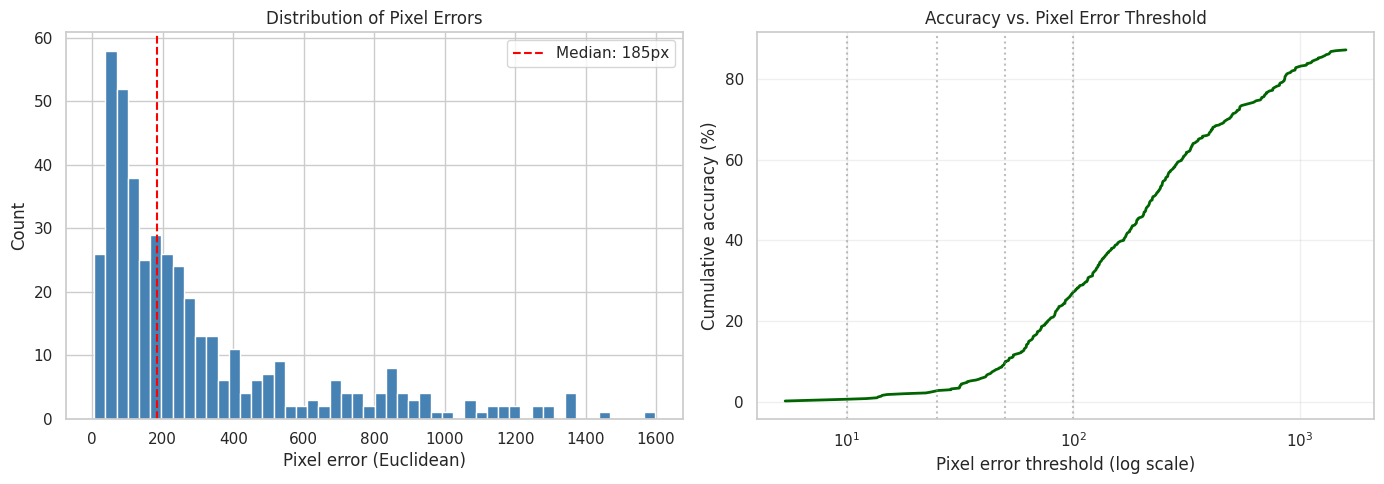

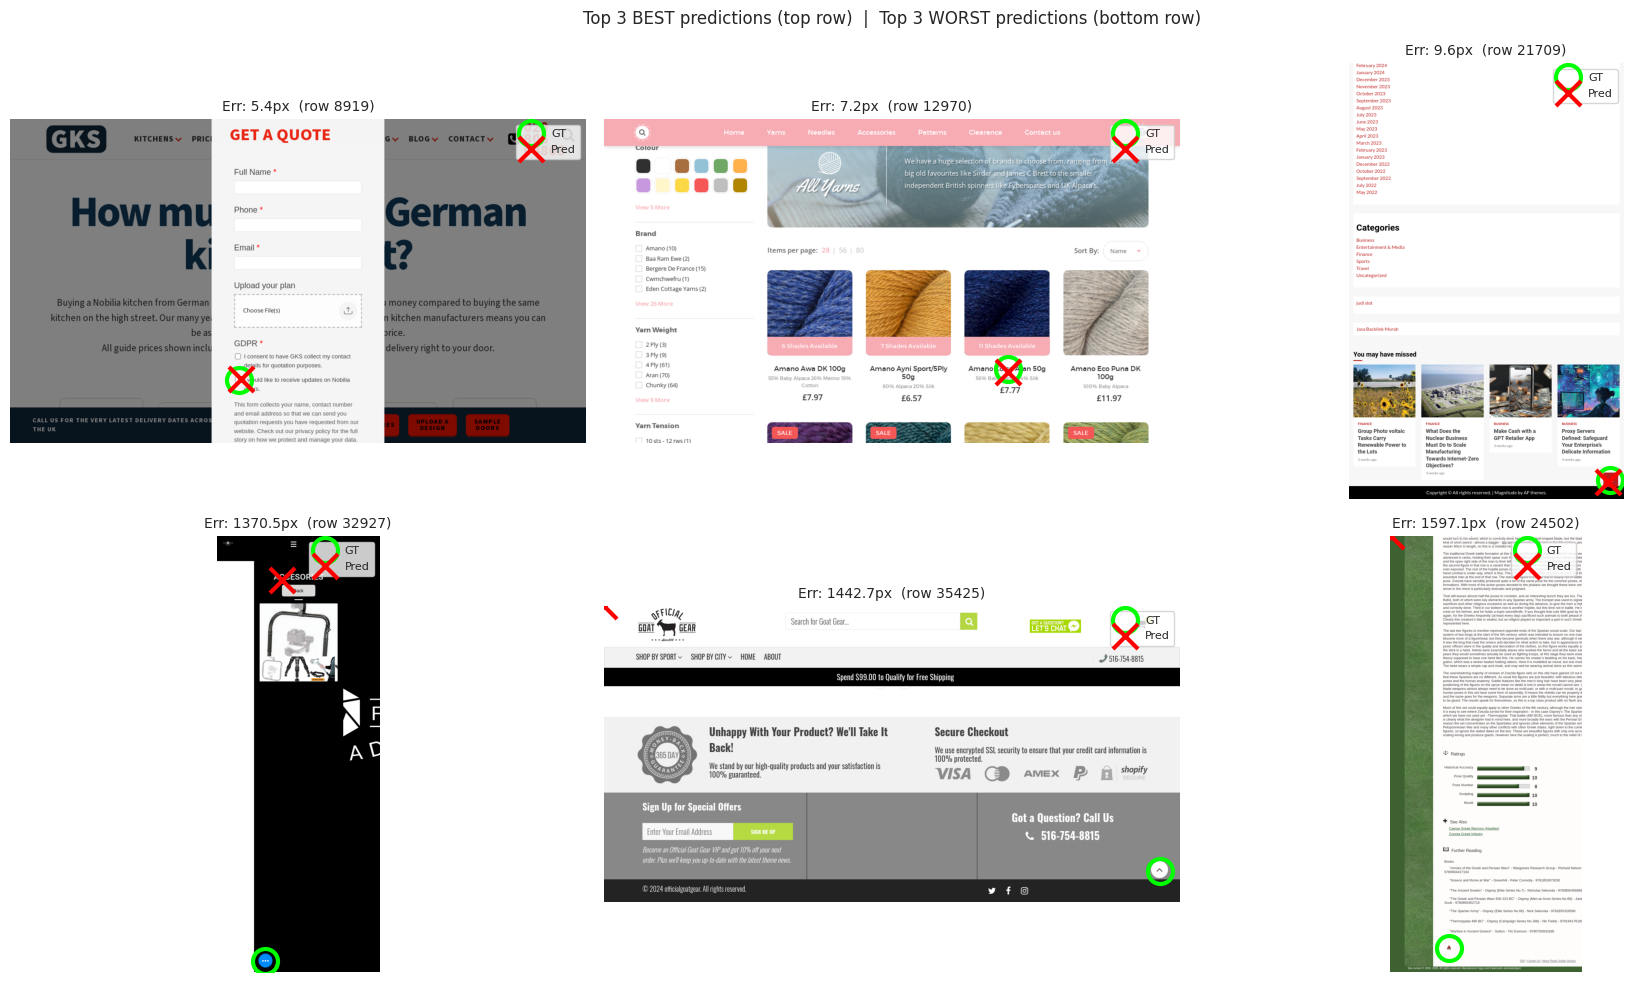


[Sample raw outputs for inspection]
------------------------------------------------------------------------
[OK ] GT=(882, 39)  raw_output='(872, 10)'
[BAD] GT=(499, 599)  raw_output='(350, 100, 950, 110)'
[OK ] GT=(561, 114)  raw_output='(500, 100)'
[OK ] GT=(338, 667)  raw_output='(242, 598)'
[OK ] GT=(148, 379)  raw_output='(333, 375)'


In [ ]:
# ============================================================
# Visualize: error distribution + qualitative best/worst examples
# ============================================================
import matplotlib.pyplot as plt

if len(valid) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram of pixel errors. The shape tells us a lot:
    #   - Sharp left peak with thin tail = "mostly close, occasional miss" (good)
    #   - Flat / right-shifted distribution = "uniformly bad" (the model
    #     isn't really doing grounding, just guessing).
    axes[0].hist(valid["err_px"], bins=50, color="steelblue", edgecolor="white")
    axes[0].axvline(valid["err_px"].median(), color="red", linestyle="--",
                    label=f"Median: {valid['err_px'].median():.0f}px")
    axes[0].set_xlabel("Pixel error (Euclidean)")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Distribution of Pixel Errors")
    axes[0].legend()

    # Cumulative accuracy curve - one of the most useful single-plot
    # summaries of grounding quality. The steeper the early rise, the
    # more often the model nails it within a few pixels. Log x-axis
    # because errors span several orders of magnitude.
    sorted_err = np.sort(valid["err_px"].values)
    cum_acc = np.arange(1, len(sorted_err) + 1) / n_total * 100
    axes[1].plot(sorted_err, cum_acc, color="darkgreen", linewidth=2)
    axes[1].set_xscale("log")
    axes[1].set_xlabel("Pixel error threshold (log scale)")
    axes[1].set_ylabel("Cumulative accuracy (%)")
    axes[1].set_title("Accuracy vs. Pixel Error Threshold")
    axes[1].grid(True, alpha=0.3)
    # Mark common threshold values for quick visual reference.
    for thr in [10, 25, 50, 100]:
        axes[1].axvline(thr, color="gray", linestyle=":", alpha=0.5)

    plt.tight_layout()
    plt.show()


# Show a handful of qualitative examples - 3 best + 3 worst by pixel
# error. This is invaluable for understanding what the model is doing
# well vs poorly (e.g. "always nails buttons but misses tiny icons").
if len(valid) >= 6:
    valid_sorted = valid.sort_values("err_px")
    examples = pd.concat([valid_sorted.head(3), valid_sorted.tail(3)])

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, examples.iterrows()):
        # We didn't keep the PIL image in `results` (would have eaten RAM),
        # so re-decode it from `ds` using the row index we tracked.
        ds_row = ds[int(row["row_idx"])]
        img = decode_image(ds_row["image"])
        ax.imshow(img)

        # Convert normalized [0, 999] coords back to pixels for plotting
        # on top of the original-resolution image.
        gt_px_x = row["gt_x"]   / 999.0 * row["width"]
        gt_px_y = row["gt_y"]   / 999.0 * row["height"]
        pr_px_x = row["pred_x"] / 999.0 * row["width"]
        pr_px_y = row["pred_y"] / 999.0 * row["height"]

        # Open green circle = ground truth; red X = prediction.
        ax.plot(gt_px_x, gt_px_y, "o",
                markersize=18, markerfacecolor="none",
                markeredgecolor="lime", markeredgewidth=3, label="GT")
        ax.plot(pr_px_x, pr_px_y, "x",
                markersize=18, markeredgecolor="red", markeredgewidth=3,
                label="Pred")
        ax.set_title(f"Err: {row['err_px']:.1f}px  (row {int(row['row_idx'])})",
                     fontsize=10)
        ax.legend(loc="upper right", fontsize=8)
        ax.axis("off")

    plt.suptitle("Top 3 BEST predictions (top row)  |  "
                 "Top 3 WORST predictions (bottom row)",
                 fontsize=12)
    plt.tight_layout()
    plt.show()


# Print a few raw model outputs so we can see HOW the model is failing
# when it fails - especially useful for diagnosing format issues.
print("\n[Sample raw outputs for inspection]")
print("-" * 72)
for _, row in df.sample(min(5, len(df)), random_state=0).iterrows():
    in_bounds = (pd.notna(row["pred_x"])
                 and 0 <= row["pred_x"] <= 999
                 and 0 <= row["pred_y"] <= 999)
    status = "OK " if in_bounds else "BAD"
    print(f"[{status}] GT=({row['gt_x']}, {row['gt_y']})  "
          f"raw_output={row['raw_output']!r}")

# LoRA Fine-Tuning Qwen2-VL-2B on UGround

Now that we have a zero-shot baseline, we fine-tune Qwen2-VL-2B using
**Low-Rank Adaptation (LoRA)** on **every row in the dataset that is
not in the eval set** (~43k samples, in practice), then re-run inference
on the same `eval_items` so the before/after comparison is apples-to-apples.

**Why LoRA?** Full fine-tuning of a 2B model on a free-tier T4 (16 GB) is
infeasible — gradients + optimizer state alone would need ~40 GB. LoRA
freezes the base weights and injects small trainable rank-`r` matrices
into each attention projection. With `r=16` we train only ~0.2% of the
parameters, so gradients, optimizer state, and activations all fit
comfortably.

**What we change:**
- LoRA adapters on the attention projections (`q_proj`, `k_proj`, `v_proj`,
  `o_proj`) — the standard recipe for adapting LLMs/VLMs to a new output
  format like our `(x, y)` coordinate convention.

**What we do NOT change:**
- The eval set (same `eval_items` as the baseline).
- Inference code (same prompt, same greedy decoding, same metrics).

**Runtime reality check.** ~43k samples at ~1 sec/sample on a T4 is
roughly **12–15 hours for one epoch** — past a free-tier Colab session
(12 h). Your options:
- **Colab Pro/Pro+** (longer sessions) or a rented **A100** (~3–4 h) /
  **H100** (~1 h). Use what you have.
- **Periodic checkpointing is enabled below** (save every 2 000 steps,
  keep the 2 most recent). If your session dies mid-run, re-run the
  Trainer cell with `resume_from_checkpoint=True` and it picks up
  from the last checkpoint.
- **Smoke-test first**: set `MAX_TRAIN_SAMPLES = 2000` in the next cell
  to verify the whole pipeline in ~30 min before committing to the
  full run.

In [ ]:
# ============================================================
# Install PEFT (the official HuggingFace LoRA library)
# ============================================================
# peft >= 0.12 has the Qwen2-VL-compatible target-module handling.
# We already installed transformers+accelerate in the baseline section.
!pip install -q "peft>=0.12.0"

In [ ]:
# ============================================================
# Metrics helper + preserve baseline results
# ============================================================
# Re-implemented as a FUNCTION here so we can call it on both the baseline
# predictions (already in `df` from the previous section) and the
# post-fine-tuning predictions (computed later). Returns both an aggregate
# dict and the per-sample `valid` frame (useful for plots).
import numpy as np
import pandas as pd

def compute_metrics(pred_df):
    """
    Compute the full grounding-metric battery on a predictions DataFrame.
    `pred_df` must have columns: pred_x, pred_y, gt_x, gt_y, width, height.
    """
    n = len(pred_df)
    parsed = pred_df["pred_x"].notna() & pred_df["pred_y"].notna()
    in_bounds = parsed & pred_df["pred_x"].between(0, 999) & pred_df["pred_y"].between(0, 999)
    valid = pred_df[in_bounds].copy()

    m = {
        "n_total":        n,
        "parse_rate":     parsed.mean() * 100,
        "in_bounds_rate": in_bounds.mean() * 100,
    }

    if len(valid) > 0:
        # Normalized [0-999] Euclidean error — resolution-agnostic.
        valid["err_norm"] = np.sqrt(
            (valid["pred_x"] - valid["gt_x"]) ** 2
            + (valid["pred_y"] - valid["gt_y"]) ** 2
        )
        # Original-pixel Euclidean error — intuitive ("47 px off").
        pxx = valid["pred_x"] / 999.0 * valid["width"]
        pxy = valid["pred_y"] / 999.0 * valid["height"]
        gxx = valid["gt_x"]   / 999.0 * valid["width"]
        gxy = valid["gt_y"]   / 999.0 * valid["height"]
        valid["err_px"] = np.sqrt((pxx - gxx) ** 2 + (pxy - gxy) ** 2)
        # Relative to image diagonal — fair across resolutions.
        diag = np.sqrt(valid["width"] ** 2 + valid["height"] ** 2)
        valid["err_pct_diag"] = valid["err_px"] / diag * 100

        m["mean_err_norm"]     = valid["err_norm"].mean()
        m["median_err_norm"]   = valid["err_norm"].median()
        m["mean_err_px"]       = valid["err_px"].mean()
        m["median_err_px"]     = valid["err_px"].median()
        m["mean_err_pct_diag"] = valid["err_pct_diag"].mean()

        # Accuracy @ thresholds: denominator is always n_total
        # (failed parses count as wrong — NOT silently dropped).
        for thr in [5, 10, 25, 50, 100, 200]:
            m[f"acc_px_{thr}"] = (valid["err_px"] <= thr).sum() / n * 100
        for thr in [10, 25, 50, 100, 200]:
            m[f"acc_norm_{thr}"] = (valid["err_norm"] <= thr).sum() / n * 100
        for thr in [1, 2, 5, 10]:
            m[f"acc_diag_{thr}"] = (valid["err_pct_diag"] <= thr).sum() / n * 100
    else:
        # Degenerate case: model produced zero usable predictions.
        for k in ["mean_err_norm", "median_err_norm", "mean_err_px",
                  "median_err_px", "mean_err_pct_diag"]:
            m[k] = float("nan")
        for thr in [5, 10, 25, 50, 100, 200]:
            m[f"acc_px_{thr}"] = 0.0
        for thr in [10, 25, 50, 100, 200]:
            m[f"acc_norm_{thr}"] = 0.0
        for thr in [1, 2, 5, 10]:
            m[f"acc_diag_{thr}"] = 0.0

    return m, valid


# Snapshot the baseline `df` NOW — the fine-tuned inference loop later will
# reuse the name `df`, and we want the baseline numbers frozen for comparison.
baseline_df = df.copy()
baseline_metrics, baseline_valid = compute_metrics(baseline_df)
print(f"Baseline frozen: {len(baseline_df)} predictions, "
      f"parse rate {baseline_metrics['parse_rate']:.1f}%, "
      f"median px error {baseline_metrics['median_err_px']:.1f}")

Baseline frozen: 500 predictions, parse rate 87.2%, median px error 184.5


In [ ]:
# ============================================================
# Build the training subset (disjoint from eval_items)
# ============================================================
import random

# Default: use every non-eval row. For a quick pipeline smoke-test
# (verify the whole train+eval loop works before committing to ~half a
# day of GPU time), set this to a small integer like 2000.
MAX_TRAIN_SAMPLES = None

# CRITICAL: exclude any row we're evaluating on, otherwise "improvement"
# would just be memorization. Same screenshot in train + eval = cheating.
EVAL_ROW_SET = set(int(it["row_idx"]) for it in eval_items)


def build_training_items(dataset, excluded_rows, cap=None, seed=456):
    """
    Collect every (row, first-valid-pair) item whose row isn't in
    `excluded_rows`. Optionally cap to `cap` items for faster iteration.

    MEMORY CRITICAL: this function used to index the dataset with
    `dataset[ri]`, which decodes the image column every call. At ~5k
    rows deep that exhausts Colab's 12 GB RAM and crashes the kernel.

    The fix: pull whole columns (conversations, width, height) ONCE,
    then iterate over those lists. The image column is never touched
    here - we only need it later inside the training Dataset's
    __getitem__, one at a time.
    """
    rng = random.Random(seed)
    indices = list(range(len(dataset)))
    rng.shuffle(indices)

    # Whole-column pulls. `conversations` is ~43k JSON strings (~30 MB),
    # `width` and `height` are ~43k ints each. Image column is NOT read.
    convos_col = dataset["conversations"]
    widths_col = dataset["width"]
    heights_col = dataset["height"]

    items = []
    for ri in indices:
        if cap is not None and len(items) >= cap:
            break
        if ri in excluded_rows:
            continue

        try:
            convos = json.loads(convos_col[ri])
        except (json.JSONDecodeError, TypeError):
            continue

        for pi in range(0, len(convos) - 1, 2):
            h, g = convos[pi], convos[pi + 1]
            if h.get("from") != "human" or g.get("from") != "gpt":
                continue
            gt = parse_coordinates(g.get("value", ""))
            if gt is None:
                continue
            items.append({
                "row_idx":    ri,
                "width":      widths_col[ri],
                "height":     heights_col[ri],
                "human_text": h.get("value", ""),
                "gt_x":       gt[0],
                "gt_y":       gt[1],
            })
            break

    return items


train_items = build_training_items(ds, EVAL_ROW_SET, cap=MAX_TRAIN_SAMPLES)
overlap = sum(1 for it in train_items if it["row_idx"] in EVAL_ROW_SET)
skipped = len(ds) - len(train_items) - len(EVAL_ROW_SET)

print(f"Training set   : {len(train_items):,} items")
print(f"Eval set       : {len(EVAL_ROW_SET):,} rows (excluded)")
print(f"Skipped / invalid rows: {skipped:,} (malformed conversations or no valid pair)")
print(f"Overlap with eval    : {overlap} (must be 0)")
assert overlap == 0, "Training set contaminated with eval rows!"

Training set   : 42,892 items
Eval set       : 500 rows (excluded)
Skipped / invalid rows: 0 (malformed conversations or no valid pair)
Overlap with eval    : 0 (must be 0)


In [ ]:
# ============================================================
# Training Dataset: build (input_ids, labels, pixel_values) per item
# ============================================================
# Key trick: we tokenize the FULL conversation (system+user+assistant)
# for input_ids, but mask the loss on the prompt portion so we only learn
# to PRODUCE the "(x, y)" answer - not to regenerate the question.
import torch
from torch.utils.data import Dataset
from qwen_vl_utils import process_vision_info


class QwenGroundingDataset(Dataset):
    def __init__(self, items, dataset, processor):
        self.items     = items       # lightweight dicts from build_training_items
        self.dataset   = dataset     # the HuggingFace Dataset (for image bytes)
        self.processor = processor

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]

        # MEMORY NOTE: we read just the image column for this single row.
        # `dataset["image"][ri]` asks the arrow backend for one cell and
        # doesn't materialize the other columns (which we already have
        # cached in `self.items`). This keeps per-worker peak RAM low.
        image = decode_image(self.dataset["image"][item["row_idx"]])

        # User turn = what we'd show at inference time.
        user_msgs = build_messages(image, item["human_text"])
        # Full conversation adds the target answer as the assistant turn.
        full_msgs = user_msgs + [{
            "role": "assistant",
            "content": f"({item['gt_x']}, {item['gt_y']})",
        }]

        # Two chat-template renderings:
        # 1. full_text    -> tokenized into input_ids
        # 2. prompt_text  -> used ONLY to measure where the answer starts,
        #                    so we can mask prompt tokens from the loss.
        full_text = self.processor.apply_chat_template(
            full_msgs, tokenize=False, add_generation_prompt=False,
        )
        prompt_text = self.processor.apply_chat_template(
            user_msgs, tokenize=False, add_generation_prompt=True,
        )

        image_inputs, _ = process_vision_info(user_msgs)

        full_enc = self.processor(
            text=[full_text], images=image_inputs,
            return_tensors="pt", padding=True,
        )
        prompt_len = self.processor(
            text=[prompt_text], images=image_inputs,
            return_tensors="pt", padding=True,
        ).input_ids.shape[1]

        # Build labels = input_ids with prompt tokens replaced by -100
        # (the standard "ignore me" value for CrossEntropyLoss).
        labels = full_enc.input_ids.clone()
        labels[:, :prompt_len] = -100

        return {
            "input_ids":      full_enc.input_ids,       # [1, seq]
            "attention_mask": full_enc.attention_mask,  # [1, seq]
            "labels":         labels,                   # [1, seq]
            "pixel_values":   full_enc.pixel_values,    # [num_patches, dim]
            "image_grid_thw": full_enc.image_grid_thw,  # [1, 3]
        }


def qwen_collate(features):
    # batch_size=1 everywhere (variable-length pixel_values make
    # true batching painful; gradient accumulation gives the same effect).
    # Tensors already carry the batch dim from the processor, so just pass
    # through the single feature.
    return features[0]


train_dataset = QwenGroundingDataset(train_items, ds, processor)

# Smoke test: make sure one sample comes out with the expected shapes.
_sample = train_dataset[0]
print("Sample tensor shapes:")
for k, v in _sample.items():
    print(f"  {k:<16s}: {tuple(v.shape)}  dtype={v.dtype}")
print(f"Non-masked label tokens: {(_sample['labels'] != -100).sum().item()} "
      f"(should be small - only the (x,y) tokens)")

Sample tensor shapes:
  input_ids       : (1, 1367)  dtype=torch.int64
  attention_mask  : (1, 1367)  dtype=torch.int64
  labels          : (1, 1367)  dtype=torch.int64
  pixel_values    : (4400, 1176)  dtype=torch.float32
  image_grid_thw  : (1, 3)  dtype=torch.int64
Non-masked label tokens: 12 (should be small - only the (x,y) tokens)


In [ ]:
# ============================================================
# Attach LoRA adapters to Qwen2-VL
# ============================================================
# LoRA replaces each targeted Linear(in, out) with Linear(in, out) (frozen)
# + A @ B where A is (in, r), B is (r, out). Rank r << in,out, so only
# ~0.1-0.5% of the params become trainable.
from peft import LoraConfig, get_peft_model, TaskType

LORA_R       = 16     # Rank. 8 is leaner; 16 is a safe default that
                      # usually matches full FT quality on small adapts.
LORA_ALPHA   = 32     # Scaling factor; rule of thumb is alpha = 2 * r.
LORA_DROPOUT = 0.05   # Mild regularization - LoRA overfits quickly.

# Target every attention projection in the model. These names appear in
# both the vision encoder and the language model; PEFT attaches to all of
# them. This is fine (and sometimes helpful for GUI tasks since web
# screenshots are a bit out-of-distribution for the vision encoder).
TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj"]

lora_config = LoraConfig(
    r              = LORA_R,
    lora_alpha     = LORA_ALPHA,
    lora_dropout   = LORA_DROPOUT,
    target_modules = TARGET_MODULES,
    bias           = "none",              # don't train bias terms
    task_type      = TaskType.CAUSAL_LM,   # Qwen2-VL is a causal LM
)

# Gradient checkpointing trades compute for memory by NOT storing
# activations on the forward pass - they're recomputed during backward.
# enable_input_require_grads() is needed so gradients can flow back
# through the (otherwise frozen) input embeddings to reach the LoRA A/B
# matrices. This combo is the standard PEFT-on-a-big-model recipe.
model.enable_input_require_grads()

peft_model = get_peft_model(model, lora_config)
peft_model.print_trainable_parameters()

trainable params: 4,358,144 || all params: 2,213,343,744 || trainable%: 0.1969


In [ ]:
# ============================================================
# Train (with async Drive mirror for checkpoint persistence)
# ============================================================
import shutil
import threading
import queue
from transformers import TrainingArguments, Trainer, TrainerCallback

# Train to LOCAL disk for speed, then asynchronously mirror each new
# checkpoint to Drive in a background thread. This gives us the best of
# both worlds: fast checkpoint writes (no Drive FUSE latency stalling
# training) AND persistence across runtime disconnects.
LOCAL_OUTPUT_DIR = "/content/qwen2vl_lora_adapter"
DRIVE_MIRROR_DIR = "/content/drive/MyDrive/Too CUA for School/MS3/qwen2vl_lora_adapter"

# Drive must be mounted for the mirror to work.
assert os.path.isdir("/content/drive/MyDrive"), (
    "Google Drive is not mounted. Re-run the `drive.mount(...)` cell first."
)
os.makedirs(LOCAL_OUTPUT_DIR, exist_ok=True)
os.makedirs(DRIVE_MIRROR_DIR, exist_ok=True)


class DriveMirrorCallback(TrainerCallback):
    """
    After each checkpoint save, copy the new checkpoint to Drive in a
    background thread, and delete any Drive checkpoints that no longer
    exist locally (so Drive mirrors the save_total_limit cleanup).

    Why a thread? Drive FUSE writes take 30s-2min for a full checkpoint.
    Doing this inline would pause training for that long every save_steps.
    The thread lets training resume immediately while the copy happens
    in the background. A single-worker queue serializes copies so two
    saves can't collide on Drive I/O.
    """
    def __init__(self, local_dir, drive_dir):
        self.local_dir = local_dir
        self.drive_dir = drive_dir
        # Unbounded queue - copies fall behind gracefully if Drive is slow.
        # In practice at save_steps=1000 on a T4, training takes ~20 min
        # between saves and a copy takes ~1-2 min, so the queue stays at 0-1.
        self.q = queue.Queue()
        # Daemon thread exits when the notebook kernel does; no cleanup needed.
        self.worker = threading.Thread(target=self._run, daemon=True)
        self.worker.start()

    def _run(self):
        # Worker loop: pull (local_path, ckpt_name) jobs off the queue,
        # copy each one to Drive, then mirror the local directory's
        # contents so deletions propagate.
        while True:
            job = self.q.get()
            if job is None:                       # sentinel = shut down
                return
            local_path, ckpt_name = job
            try:
                drive_path = os.path.join(self.drive_dir, ckpt_name)
                # Use copytree with dirs_exist_ok so a retry after a partial
                # failure doesn't crash (Python 3.8+).
                if os.path.isdir(drive_path):
                    shutil.rmtree(drive_path)
                shutil.copytree(local_path, drive_path)
                # Mirror local's save_total_limit cleanup to Drive.
                self._sync_deletions()
                print(f"[drive-mirror] synced {ckpt_name} to Drive", flush=True)
            except Exception as e:
                # Never let a Drive hiccup kill training.
                print(f"[drive-mirror] WARN syncing {ckpt_name}: {e}", flush=True)
            finally:
                self.q.task_done()

    def _sync_deletions(self):
        """Delete Drive checkpoints that no longer exist locally."""
        local_ckpts = {d for d in os.listdir(self.local_dir)
                       if d.startswith("checkpoint-")}
        drive_ckpts = {d for d in os.listdir(self.drive_dir)
                       if d.startswith("checkpoint-")}
        for stale in drive_ckpts - local_ckpts:
            shutil.rmtree(os.path.join(self.drive_dir, stale), ignore_errors=True)

    def on_save(self, args, state, control, **kwargs):
        # Trainer fires this AFTER the checkpoint is fully written to local
        # disk. We queue a copy job and return immediately so training
        # resumes with no wait.
        ckpt_name = f"checkpoint-{state.global_step}"
        local_path = os.path.join(self.local_dir, ckpt_name)
        if os.path.isdir(local_path):
            self.q.put((local_path, ckpt_name))

    def on_train_end(self, args, state, control, **kwargs):
        # Block at the very end until every queued sync has finished,
        # so we don't exit the cell before the last checkpoint lands on
        # Drive. Without this, a user running the next cell immediately
        # could find the Drive folder incomplete.
        print(f"[drive-mirror] waiting for {self.q.qsize()} pending sync(s)...",
              flush=True)
        self.q.join()
        print("[drive-mirror] all checkpoints synced to Drive.", flush=True)


# Rough step-count math at the full ~43k-sample scale:
#   43000 samples / (batch 1 * grad_accum 4) * 1 epoch ~= 10.7k optimizer steps
# At save_steps=1000 that's ~10 checkpoints over the run.
training_args = TrainingArguments(
    output_dir                  = LOCAL_OUTPUT_DIR,  # LOCAL for speed
    num_train_epochs            = 1,
    per_device_train_batch_size = 1,
    gradient_accumulation_steps = 4,
    gradient_checkpointing      = True,
    gradient_checkpointing_kwargs = {"use_reentrant": False},

    learning_rate     = 2e-4,
    warmup_ratio      = 0.03,
    lr_scheduler_type = "cosine",
    weight_decay      = 0.0,

    bf16 = (DTYPE == torch.bfloat16),
    fp16 = (DTYPE == torch.float16),

    logging_steps     = 100,

    # Local checkpointing every 1000 steps. The DriveMirrorCallback
    # handles pushing each new checkpoint to Drive in the background.
    save_strategy     = "steps",
    save_steps        = 1000,
    save_total_limit  = 3,

    report_to             = "none",
    remove_unused_columns = False,   # CRITICAL: keeps pixel_values in the batch
    dataloader_num_workers = 0,
    optim = "adamw_torch",
)

trainer = Trainer(
    model         = peft_model,
    args          = training_args,
    train_dataset = train_dataset,
    data_collator = qwen_collate,
    callbacks     = [DriveMirrorCallback(LOCAL_OUTPUT_DIR, DRIVE_MIRROR_DIR)],
)

effective_batch = (training_args.per_device_train_batch_size
                   * training_args.gradient_accumulation_steps)
total_steps = len(train_dataset) // effective_batch * training_args.num_train_epochs
print(f"Starting training:")
print(f"  samples         : {len(train_dataset):,}")
print(f"  epochs          : {training_args.num_train_epochs}")
print(f"  effective batch : {effective_batch}")
print(f"  optimizer steps : ~{total_steps:,}")
print(f"  local ckpts     : every {training_args.save_steps:,} steps -> {LOCAL_OUTPUT_DIR}")
print(f"  drive mirror    : async background -> {DRIVE_MIRROR_DIR}")
print()

# Auto-resume: prefer local checkpoints (fast), fall back to restoring
# from Drive if the local dir is empty (e.g. fresh session after a
# previous run's disconnect).
def _has_ckpts(d):
    return os.path.isdir(d) and any(
        x.startswith("checkpoint-") for x in os.listdir(d)
    )

if not _has_ckpts(LOCAL_OUTPUT_DIR) and _has_ckpts(DRIVE_MIRROR_DIR):
    print(f"No local checkpoints; restoring from Drive mirror first...")
    for ckpt in sorted(d for d in os.listdir(DRIVE_MIRROR_DIR)
                       if d.startswith("checkpoint-")):
        src = os.path.join(DRIVE_MIRROR_DIR, ckpt)
        dst = os.path.join(LOCAL_OUTPUT_DIR, ckpt)
        if not os.path.isdir(dst):
            shutil.copytree(src, dst)
    print(f"Restored {len(os.listdir(LOCAL_OUTPUT_DIR))} checkpoint(s) locally.")

trainer.train(resume_from_checkpoint=_has_ckpts(LOCAL_OUTPUT_DIR))

# Final adapter save: write locally, then force a Drive mirror copy.
peft_model.save_pretrained(LOCAL_OUTPUT_DIR)
# The final adapter isn't a "checkpoint-*" dir, so it's not auto-mirrored
# by the callback. Copy the top-level adapter files explicitly.
for fname in os.listdir(LOCAL_OUTPUT_DIR):
    src = os.path.join(LOCAL_OUTPUT_DIR, fname)
    dst = os.path.join(DRIVE_MIRROR_DIR, fname)
    if os.path.isfile(src):
        shutil.copy2(src, dst)
print(f"\n✓ LoRA adapter saved to {LOCAL_OUTPUT_DIR} and mirrored to {DRIVE_MIRROR_DIR}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting training:
  samples         : 42,892
  epochs          : 1
  effective batch : 4
  optimizer steps : ~10,723
  local ckpts     : every 1,000 steps -> /content/qwen2vl_lora_adapter
  drive mirror    : async background -> /content/drive/MyDrive/Too CUA for School/MS3/qwen2vl_lora_adapter

No local checkpoints; restoring from Drive mirror first...
Restored 3 checkpoint(s) locally.
[drive-mirror] waiting for 0 pending sync(s)...
[drive-mirror] all checkpoints synced to Drive.


Step,Training Loss



✓ LoRA adapter saved to /content/qwen2vl_lora_adapter and mirrored to /content/drive/MyDrive/Too CUA for School/MS3/qwen2vl_lora_adapter


In [ ]:
# ============================================================
# Re-run inference on the SAME eval_items with the fine-tuned model
# ============================================================
# Same loop as the baseline section - we just swap in `peft_model` instead
# of `model`. Using the same eval_items, same prompt, and same greedy
# decoding means any metric delta is attributable to the LoRA weights,
# not sampling noise or a different test set.
import time
from tqdm.auto import tqdm
from qwen_vl_utils import process_vision_info

peft_model.eval()  # turn off dropout etc. for deterministic inference

ft_results = []
start_time = time.time()

with torch.inference_mode():
    for item in tqdm(eval_items, desc="Qwen2-VL + LoRA inference"):
        try:
            # Decode the image on demand (eval_items no longer caches PIL).
            image = decode_image(ds["image"][item["row_idx"]])

            messages = build_messages(image, item["human_text"])
            prompt_text = processor.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True,
            )
            image_inputs, video_inputs = process_vision_info(messages)
            inputs = processor(
                text=[prompt_text],
                images=image_inputs, videos=video_inputs,
                return_tensors="pt", padding=True,
            ).to(peft_model.device)

            gen_ids = peft_model.generate(
                **inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=DO_SAMPLE,
            )
            new_tokens = gen_ids[:, inputs.input_ids.shape[1]:]
            output_text = processor.batch_decode(
                new_tokens, skip_special_tokens=True,
                clean_up_tokenization_spaces=False,
            )[0].strip()
            pred = parse_coordinates(output_text)
        except Exception as e:
            output_text = f"[ERROR: {type(e).__name__}: {e}]"
            pred = None

        ft_results.append({
            "row_idx":    item["row_idx"],
            "pair_idx":   item["pair_idx"],
            "width":      item["width"],
            "height":     item["height"],
            "gt_x":       item["gt_x"],
            "gt_y":       item["gt_y"],
            "raw_output": output_text,
            "pred_x":     pred[0] if pred else None,
            "pred_y":     pred[1] if pred else None,
        })

elapsed = time.time() - start_time
print(f"\n✓ FT inference: {len(ft_results)} samples in {elapsed:.1f}s "
      f"({elapsed/max(len(ft_results),1):.2f}s per sample)")

ft_df = pd.DataFrame(ft_results)
ft_df.to_csv("/content/qwen2vl_2b_lora_results.csv", index=False)

Qwen2-VL + LoRA inference:   0%|          | 0/500 [00:00<?, ?it/s]


✓ FT inference: 500 samples in 404.3s (0.81s per sample)


  Qwen2-VL-2B:  BASELINE  vs  +LoRA  (same 500 eval samples)

[Format compliance]
Metric                                  Baseline    Fine-tuned               Δ
Parse rate (%)                             87.20        100.00    +12.80 ↑
In-bounds rate (%)                         87.20        100.00    +12.80 ↑

[Distance error (lower is better)]
Metric                                  Baseline    Fine-tuned               Δ
Mean err (normalized 0-999)               269.30         85.23   -184.08 ↑
Median err (normalized 0-999)             166.69         10.25   -156.44 ↑
Mean err (pixels)                         298.42         94.83   -203.58 ↑
Median err (pixels)                       184.55         11.67   -172.87 ↑
Mean err (% of diagonal)                   19.15          6.08    -13.07 ↑

[Accuracy at thresholds (higher is better, % of all 500)]
Metric                                  Baseline    Fine-tuned               Δ
Acc @ 5 px                                  0.00         28.4

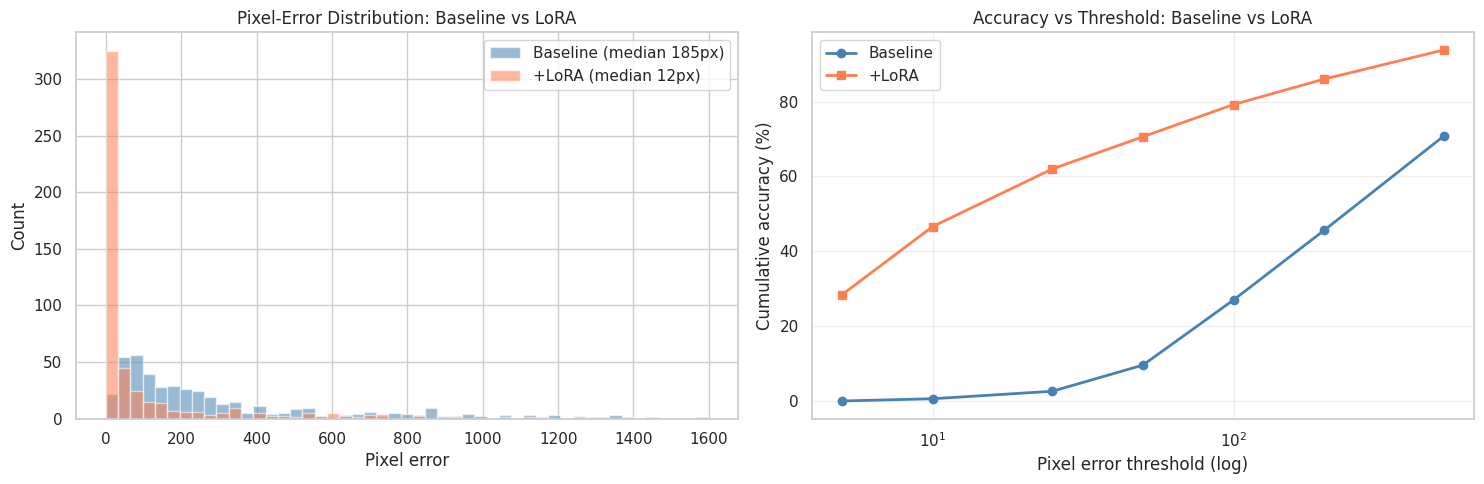


[Raw output comparison on 5 random eval samples]
------------------------------------------------------------------------------
GT=(882, 39)
  Baseline: '(872, 10)'
  +LoRA   : '(916, 38)'

GT=(499, 599)
  Baseline: '(350, 100, 950, 110)'
  +LoRA   : '(520, 90)'

GT=(561, 114)
  Baseline: '(500, 100)'
  +LoRA   : '(568, 75)'

GT=(338, 667)
  Baseline: '(242, 598)'
  +LoRA   : '(327, 667)'

GT=(148, 379)
  Baseline: '(333, 375)'
  +LoRA   : '(148, 379)'



In [ ]:
# ============================================================
# Side-by-side comparison: baseline vs fine-tuned
# ============================================================
import matplotlib.pyplot as plt

ft_metrics, ft_valid = compute_metrics(ft_df)

# ---------- Tabular report ----------
# We group metrics into three blocks for readability.
# Column layout:
#   metric name | baseline | fine-tuned | delta (with arrow)
def fmt_delta(b, f, higher_is_better):
    if any(map(lambda v: v != v, [b, f])):  # NaN guard
        return "   n/a"
    d = f - b
    arrow = "↑" if (d > 0) == higher_is_better else ("↓" if d != 0 else "·")
    return f"{d:+7.2f} {arrow}"


print("=" * 78)
print(f"  Qwen2-VL-2B:  BASELINE  vs  +LoRA  (same {len(eval_items)} eval samples)")
print("=" * 78)

# Format block: higher-is-better.
print(f"\n[Format compliance]")
print(f"{'Metric':<36}{'Baseline':>12}{'Fine-tuned':>14}{'Δ':>16}")
for k, label in [("parse_rate",     "Parse rate (%)"),
                 ("in_bounds_rate", "In-bounds rate (%)")]:
    b, f = baseline_metrics[k], ft_metrics[k]
    print(f"{label:<36}{b:>12.2f}{f:>14.2f}   {fmt_delta(b, f, True)}")

# Error block: lower-is-better.
print(f"\n[Distance error (lower is better)]")
print(f"{'Metric':<36}{'Baseline':>12}{'Fine-tuned':>14}{'Δ':>16}")
for k, label in [("mean_err_norm",     "Mean err (normalized 0-999)"),
                 ("median_err_norm",   "Median err (normalized 0-999)"),
                 ("mean_err_px",       "Mean err (pixels)"),
                 ("median_err_px",     "Median err (pixels)"),
                 ("mean_err_pct_diag", "Mean err (% of diagonal)")]:
    b, f = baseline_metrics[k], ft_metrics[k]
    print(f"{label:<36}{b:>12.2f}{f:>14.2f}   {fmt_delta(b, f, False)}")

# Accuracy block: higher-is-better.
print(f"\n[Accuracy at thresholds (higher is better, % of all {len(eval_items)})]")
print(f"{'Metric':<36}{'Baseline':>12}{'Fine-tuned':>14}{'Δ':>16}")
for thr in [5, 10, 25, 50, 100, 200]:
    k = f"acc_px_{thr}"
    b, f = baseline_metrics[k], ft_metrics[k]
    print(f"{'Acc @ '+str(thr)+' px':<36}{b:>12.2f}{f:>14.2f}   {fmt_delta(b, f, True)}")
for thr in [1, 2, 5, 10]:
    k = f"acc_diag_{thr}"
    b, f = baseline_metrics[k], ft_metrics[k]
    print(f"{'Acc @ '+str(thr)+'% of diagonal':<36}{b:>12.2f}{f:>14.2f}   {fmt_delta(b, f, True)}")
print("=" * 78)


# ---------- Visual comparison ----------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (1) Overlaid error histograms. If LoRA helped, the FT distribution
#     should shift visibly left (smaller errors).
bins = np.linspace(0, max(baseline_valid["err_px"].max() if len(baseline_valid) else 1,
                          ft_valid["err_px"].max() if len(ft_valid) else 1), 50)
if len(baseline_valid):
    axes[0].hist(baseline_valid["err_px"], bins=bins, alpha=0.55,
                 color="steelblue", label=f"Baseline (median {baseline_metrics['median_err_px']:.0f}px)")
if len(ft_valid):
    axes[0].hist(ft_valid["err_px"], bins=bins, alpha=0.55,
                 color="coral", label=f"+LoRA (median {ft_metrics['median_err_px']:.0f}px)")
axes[0].set_xlabel("Pixel error")
axes[0].set_ylabel("Count")
axes[0].set_title("Pixel-Error Distribution: Baseline vs LoRA")
axes[0].legend()

# (2) Accuracy-vs-threshold curves. Clearest way to see that one model
#     dominates the other at every operating point.
thresholds = [5, 10, 25, 50, 100, 200, 500]
baseline_accs = [(baseline_valid["err_px"] <= t).sum() / len(baseline_df) * 100
                 if len(baseline_valid) else 0 for t in thresholds]
ft_accs       = [(ft_valid["err_px"] <= t).sum() / len(ft_df) * 100
                 if len(ft_valid) else 0 for t in thresholds]
axes[1].plot(thresholds, baseline_accs, "o-", color="steelblue",
             linewidth=2, label="Baseline")
axes[1].plot(thresholds, ft_accs,       "s-", color="coral",
             linewidth=2, label="+LoRA")
axes[1].set_xscale("log")
axes[1].set_xlabel("Pixel error threshold (log)")
axes[1].set_ylabel("Cumulative accuracy (%)")
axes[1].set_title("Accuracy vs Threshold: Baseline vs LoRA")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


# ---------- A few raw output comparisons ----------
# Handy for sanity-checking: did the FT model learn the (x,y) format
# specifically, or is it just generally better?
print("\n[Raw output comparison on 5 random eval samples]")
print("-" * 78)
sample_idxs = np.random.RandomState(0).choice(
    len(baseline_df), size=min(5, len(baseline_df)), replace=False
)
for i in sample_idxs:
    b_row, f_row = baseline_df.iloc[i], ft_df.iloc[i]
    print(f"GT=({b_row['gt_x']}, {b_row['gt_y']})")
    print(f"  Baseline: {b_row['raw_output']!r}")
    print(f"  +LoRA   : {f_row['raw_output']!r}")
    print()

# Hybrid Loss LoRA Fine-Tuning: Cross-Entropy + Euclidean Distance

The previous LoRA section trained Qwen2-VL with pure token-level
cross-entropy. That objective is structurally **insensitive to spatial
distance**: predicting `(451, 120)` when the truth is `(450, 120)` incurs
the same per-token loss as predicting `(999, 999)` would, even though one
is essentially correct and the other catastrophic.

This section adds an **auxiliary L2 distance term** computed on
differentiable digit-token expectations. At each digit position $i$,
we read the model's logits, mask to the 10 digit tokens (0-9), softmax,
and compute the expected digit:

$$\hat{d}_i = \sum_{j=0}^{9} j \cdot P(\text{token}_i = \text{"}j\text{"})$$

We combine these into expected coordinates
$\hat{x} = 100\,\hat{d}_1 + 10\,\hat{d}_2 + \hat{d}_3$ (and similarly
for $\hat{y}$), then compute Euclidean distance to the ground truth.
The full objective is:

$$\mathcal{L} = \mathcal{L}_{\text{CE}} + \lambda \cdot \mathcal{L}_{\text{dist}}$$

with $\lambda$ small enough that CE remains the primary signal but the
distance term provides denser spatial supervision (especially on the
upper tail of the error distribution).

**Why not pure distance?** A pure-distance loss has known failure modes:
loss of format compliance, collapse to predicting the dataset mean,
imbalanced per-digit weighting (hundreds-place gets 100x the gradient
of the ones-place), and pathological expected-value behavior on bimodal
distributions. CE keeps the model anchored to valid string outputs and
calibrated commitments; the distance term layers spatial precision on
top.

This run produces a **separate adapter** (saved to a different output
directory) so we can compare three conditions cleanly: zero-shot
baseline, pure-CE LoRA, and hybrid-loss LoRA.

In [ ]:
# ============================================================
# Hybrid Dataset: passes through gt_x, gt_y for the distance loss
# ============================================================
# Same structure as QwenGroundingDataset above, but additionally returns
# gt_coords as a [1, 2] tensor so the custom loss function can compute
# Euclidean distance against the predicted expected coordinates.
import torch
from torch.utils.data import Dataset
from qwen_vl_utils import process_vision_info


class QwenGroundingHybridDataset(Dataset):
    def __init__(self, items, dataset, processor):
        self.items     = items
        self.dataset   = dataset
        self.processor = processor

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        # Read just the image cell (memory-efficient, see existing dataset).
        image = decode_image(self.dataset["image"][item["row_idx"]])

        user_msgs = build_messages(image, item["human_text"])
        full_msgs = user_msgs + [{
            "role": "assistant",
            "content": f"({item['gt_x']}, {item['gt_y']})",
        }]

        full_text = self.processor.apply_chat_template(
            full_msgs, tokenize=False, add_generation_prompt=False,
        )
        prompt_text = self.processor.apply_chat_template(
            user_msgs, tokenize=False, add_generation_prompt=True,
        )
        image_inputs, _ = process_vision_info(user_msgs)

        full_enc = self.processor(
            text=[full_text], images=image_inputs,
            return_tensors="pt", padding=True,
        )
        prompt_len = self.processor(
            text=[prompt_text], images=image_inputs,
            return_tensors="pt", padding=True,
        ).input_ids.shape[1]

        labels = full_enc.input_ids.clone()
        labels[:, :prompt_len] = -100

        return {
            "input_ids":      full_enc.input_ids,
            "attention_mask": full_enc.attention_mask,
            "labels":         labels,
            "pixel_values":   full_enc.pixel_values,
            "image_grid_thw": full_enc.image_grid_thw,
            # NEW: ground-truth coordinates as a 2-tensor [x, y] in [0, 999].
            # Float so it can multiply with logit-derived expected values
            # without an int->float cast inside the loss function.
            "gt_coords":      torch.tensor(
                [[item["gt_x"], item["gt_y"]]], dtype=torch.float32,
            ),
        }


def qwen_collate_hybrid(features):
    # Same convention as the original collate: batch_size=1, tensors already
    # carry the batch dim from the processor. Just pass through.
    return features[0]


train_dataset_hybrid = QwenGroundingHybridDataset(train_items, ds, processor)

# Smoke test
_sample = train_dataset_hybrid[0]
print("Hybrid dataset sample shapes:")
for k, v in _sample.items():
    print(f"  {k:<16s}: {tuple(v.shape)}  dtype={v.dtype}")

Hybrid dataset sample shapes:
  input_ids       : (1, 1367)  dtype=torch.int64
  attention_mask  : (1, 1367)  dtype=torch.int64
  labels          : (1, 1367)  dtype=torch.int64
  pixel_values    : (4400, 1176)  dtype=torch.float32
  image_grid_thw  : (1, 3)  dtype=torch.int64
  gt_coords       : (1, 2)  dtype=torch.float32


In [ ]:
# ============================================================
# Identify digit token IDs (one-time tokenizer inspection)
# ============================================================
# To compute expected digit values from the model's logit distribution at
# each position, we need to know which token IDs correspond to the digits
# "0" through "9". For BPE tokenizers (which Qwen2-VL uses), single-digit
# strings can tokenize differently depending on whether they appear at the
# start of a word, mid-word, with leading space, etc. We need the *exact*
# IDs that appear in our training labels at digit positions.
#
# Approach: tokenize a representative coordinate string the same way the
# Dataset does, then introspect which token IDs sit at digit positions.

tokenizer = processor.tokenizer

# Common-case: each digit becomes a single token in Qwen's BPE. We verify
# this by tokenizing a long mixed string of digits and checking each token
# decodes back to a single digit character. If this assumption is wrong,
# the hybrid loss won't apply correctly to multi-digit-per-token cases.
digit_token_ids = []
for d in range(10):
    # Tokenize a digit *with leading space* (which is how it usually appears
    # mid-string after parens, commas, etc.) and *without*. Take the
    # canonical mid-string ID, which is what we'll see in answer labels.
    ids_no_space = tokenizer.encode(str(d), add_special_tokens=False)
    ids_in_ctx   = tokenizer.encode(f"({d}", add_special_tokens=False)
    # Pull the digit ID out of the in-context tokenization (last token, since
    # the ( comes first). This is the token ID that actually appears in our
    # labels.
    digit_token_ids.append(ids_in_ctx[-1])

print("Digit -> token ID mapping (in-context, after '('):")
for d, tid in enumerate(digit_token_ids):
    decoded = tokenizer.decode([tid])
    print(f"  '{d}' -> {tid:>6}  (decodes to {decoded!r})")

# Sanity check: every digit must map to a unique single-character token.
# If this fails, multi-digit numbers might not tokenize as one-token-per-digit
# and the loss would silently mis-extract digit positions.
assert len(set(digit_token_ids)) == 10, "Digit tokens are not unique!"
for d, tid in enumerate(digit_token_ids):
    decoded = tokenizer.decode([tid]).strip()
    assert decoded == str(d), (
        f"Digit {d} decodes to {decoded!r}, not {str(d)!r}. "
        f"BPE may be merging digits into multi-char tokens; the hybrid "
        f"loss assumes one-digit-per-token and would need refactoring."
    )

# Convert to a tensor for fast lookup inside the loss function. Move it to
# the model device so we can index logits without host->device transfers.
DIGIT_TOKEN_IDS = torch.tensor(digit_token_ids, device=model.device)
print(f"\n✓ DIGIT_TOKEN_IDS tensor: shape={DIGIT_TOKEN_IDS.shape}, "
      f"device={DIGIT_TOKEN_IDS.device}")

# We also need the comma token ID to split digits into x-half vs y-half
# in the loss function. Coordinates with mismatched digit counts (e.g.
# "(50, 999)" - 2 digits for x, 3 for y) cannot be split by num_digits//2;
# we must instead split by the comma's position.
# Tokenize "x, y" in context to extract the comma token (which may carry
# a leading space, depending on the tokenizer's preprocessing).
comma_ids = tokenizer.encode("1, 2", add_special_tokens=False)
# Sequence is roughly [1, ",", " ", 2] or [1, ", ", 2] depending on BPE.
# Find the token that contains a comma in its decoded form.
COMMA_TOKEN_ID = None
for tid in comma_ids:
    if "," in tokenizer.decode([tid]):
        COMMA_TOKEN_ID = tid
        break
assert COMMA_TOKEN_ID is not None, "Could not find a comma token in tokenizer output"
print(f"COMMA_TOKEN_ID: {COMMA_TOKEN_ID} (decodes to {tokenizer.decode([COMMA_TOKEN_ID])!r})")

Digit -> token ID mapping (in-context, after '('):
  '0' ->     15  (decodes to '0')
  '1' ->     16  (decodes to '1')
  '2' ->     17  (decodes to '2')
  '3' ->     18  (decodes to '3')
  '4' ->     19  (decodes to '4')
  '5' ->     20  (decodes to '5')
  '6' ->     21  (decodes to '6')
  '7' ->     22  (decodes to '7')
  '8' ->     23  (decodes to '8')
  '9' ->     24  (decodes to '9')

✓ DIGIT_TOKEN_IDS tensor: shape=torch.Size([10]), device=cuda:0
COMMA_TOKEN_ID: 11 (decodes to ',')


In [ ]:
# ============================================================
# Attach a FRESH LoRA adapter for the hybrid run
# ============================================================
# We use a separate peft_model so we can compare three conditions cleanly:
# zero-shot baseline, pure-CE LoRA (already trained as `peft_model`), and
# this hybrid-loss LoRA. The base Qwen2-VL is the same; we just attach a
# new set of low-rank adapters initialized from scratch.
#
# IMPORTANT: PEFT mutates `model` in place when you call get_peft_model.
# Because `peft_model` is already wrapping `model`, we need to re-load the
# base model from disk to get a clean starting point for the hybrid adapter.
# Otherwise the hybrid run would start from CE-fine-tuned weights, which
# would confound the ablation.
print("Reloading base Qwen2-VL to attach a fresh adapter...")
del peft_model, model       # free GPU memory of the existing adapter
import gc; gc.collect()
torch.cuda.empty_cache()

from transformers import Qwen2VLForConditionalGeneration
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID, torch_dtype=DTYPE, device_map=DEVICE_MAP,
)
model.eval()
model.enable_input_require_grads()  # required for LoRA + grad checkpointing

# Reuse the same LoraConfig (r=16, alpha=32, dropout=0.05, q/k/v/o_proj).
# Holding hyperparameters constant across the two LoRA runs isolates the
# loss function as the only variable that changed.
peft_model_hybrid = get_peft_model(model, lora_config)
peft_model_hybrid.print_trainable_parameters()

# Re-pin DIGIT_TOKEN_IDS to the new model device (the device may differ
# slightly after a fresh load, e.g., on a multi-GPU box).
DIGIT_TOKEN_IDS = DIGIT_TOKEN_IDS.to(peft_model_hybrid.device)

Reloading base Qwen2-VL to attach a fresh adapter...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

trainable params: 4,358,144 || all params: 2,213,343,744 || trainable%: 0.1969


In [ ]:
# ============================================================
# HybridLossTrainer: cross-entropy + lambda * Euclidean distance
# ============================================================
# We subclass HuggingFace's Trainer and override compute_loss. The standard
# Trainer call already gives us CE via the model's forward pass with labels;
# we add a distance term computed from the logits at digit positions.
from transformers import Trainer

# Weight on the distance term. Picked so it's meaningful but doesn't
# dominate CE early in training:
#   CE per-token at random init: ~ln(vocab_size) ≈ 12 nats, dropping to
#   ~0.5 nats once the model commits to digits.
#   Distance per-sample at random init: ~700 px Euclidean (rough average
#   over uniform [0,999] predictions vs central GT).
# At lambda=0.01, distance contributes ~7 to the loss early (similar order
# to CE at ~12), and ~0.5 once trained (similar to CE at ~0.5). This keeps
# the two terms in the same ballpark throughout training.
DISTANCE_LAMBDA = 0.01


class HybridLossTrainer(Trainer):
    """
    Custom Trainer that computes:
        loss = ce_loss + DISTANCE_LAMBDA * mean_euclidean_distance

    The distance term is computed on differentiable digit-token expectations:
    at each answer digit position, take the logits, mask to digit tokens 0-9,
    softmax, compute expected digit value, and assemble into expected
    coordinates (x_hat, y_hat). The L2 distance between (x_hat, y_hat) and
    the ground-truth (x, y) is the auxiliary loss.

    Crucially, this is fully differentiable: argmax is replaced with a
    softmax-weighted sum, so gradients flow back through the model's logit
    head to the LoRA adapters.
    """

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Pop the GT coords out before passing inputs to the model
        # (the model's forward() doesn't accept this extra kwarg).
        gt_coords = inputs.pop("gt_coords")  # [1, 1, 2]  (batch, 1, xy)
        gt_coords = gt_coords.squeeze(1).to(model.device)  # [1, 2]

        labels = inputs["labels"]  # [1, seq]

        # Standard forward pass. With `labels=...` in inputs, the model
        # computes and returns the cross-entropy loss as `outputs.loss`.
        outputs = model(**inputs)
        ce_loss = outputs.loss

        # Logits: [batch, seq, vocab]. We need logits at the positions
        # PREDICTING each label token. In causal LMs, position t's logits
        # predict token t+1, so the logits we want for label position t
        # are at logits position t-1. Apply the standard "shift by 1" used
        # by HuggingFace's loss computation.
        logits = outputs.logits[:, :-1, :]   # drop last position
        shifted_labels = labels[:, 1:]       # drop first position
        # Now logits[:, t, :] predicts shifted_labels[:, t].

        # Identify positions in shifted_labels that are digit tokens.
        # We compare each label ID against our DIGIT_TOKEN_IDS table.
        # `is_digit` has shape [batch, seq-1], True at digit positions.
        is_digit = torch.zeros_like(shifted_labels, dtype=torch.bool)
        for tid in DIGIT_TOKEN_IDS:
            is_digit |= (shifted_labels == tid)

        # If there are no digit positions in this batch (very rare - would
        # only happen if a sample's tokenization went sideways), skip the
        # distance term entirely and return CE alone.
        if not is_digit.any():
            return (ce_loss, outputs) if return_outputs else ce_loss

        # Pull out the digit positions. We expect exactly 6 digits per
        # sample (3 for x, 3 for y) for our (xxx, yyy) format. Some
        # samples have shorter coords (e.g., x=42 tokenized as "42" -> 2
        # digit tokens), so we work with "however many digits we find"
        # and assemble x and y based on the run-of-digits structure.
        # For the common case of exactly 6 digits, the first 3 form x,
        # the next 3 form y.
        batch_size = shifted_labels.size(0)
        device = logits.device

        # We process batch_size==1 here (matches our training setup); a
        # general implementation would loop over batch dimension.
        assert batch_size == 1, (
            f"HybridLossTrainer assumes batch_size=1 (got {batch_size}). "
            f"Update this loop for larger batches."
        )

        # Get logits at digit positions: [num_digits, vocab]
        digit_positions = is_digit[0]  # [seq-1]
        digit_logits = logits[0][digit_positions]  # [num_digits, vocab]

        # Get the actual digit values at those positions (so we know which
        # ones belong to x vs y, and how many digits each coord has).
        digit_label_ids = shifted_labels[0][digit_positions]  # [num_digits]

        # Map label token IDs back to digit values 0-9. We do this by
        # finding each label's index in DIGIT_TOKEN_IDS.
        digit_values = torch.zeros_like(digit_label_ids, dtype=torch.long)
        for d in range(10):
            digit_values[digit_label_ids == DIGIT_TOKEN_IDS[d]] = d

        num_digits = digit_logits.size(0)
        if num_digits < 2:
            return (ce_loss, outputs) if return_outputs else ce_loss

        # Split into x-digits and y-digits using the COMMA TOKEN'S POSITION.
        # We can't just use num_digits//2 because x and y may have different
        # digit counts (e.g. "(50, 999)" has 2 + 3 digits, total 5).
        # Instead: find where the comma token appears in shifted_labels, and
        # split digits into "before comma" (x) and "after comma" (y).
        comma_positions = (shifted_labels[0] == COMMA_TOKEN_ID).nonzero(as_tuple=True)[0]
        if comma_positions.numel() == 0:
            # No comma found in this sample's labels - tokenization went
            # sideways. Skip distance for this sample.
            return (ce_loss, outputs) if return_outputs else ce_loss
        comma_pos = comma_positions[0].item()

        # Among the digit positions, count how many sit before the comma.
        # That count is `half_x`; the rest are y digits.
        digit_position_indices = digit_positions.nonzero(as_tuple=True)[0]
        half_x = int((digit_position_indices < comma_pos).sum().item())
        half_y = num_digits - half_x
        if half_x < 1 or half_y < 1:
            # Degenerate split (no digits on one side of the comma).
            return (ce_loss, outputs) if return_outputs else ce_loss

        # For each digit position, compute the SOFTMAX over just the 10
        # digit tokens, then the expected digit value. This is the
        # differentiable replacement for argmax.
        digit_only_logits = digit_logits[:, DIGIT_TOKEN_IDS]   # [num_digits, 10]
        digit_probs = torch.softmax(digit_only_logits, dim=-1)  # [num_digits, 10]
        digit_range = torch.arange(10, device=device, dtype=digit_probs.dtype)
        expected_digits = (digit_probs * digit_range).sum(dim=-1)  # [num_digits]

        # Assemble into expected coordinates using place values.
        # For "(450, 120)": half_x=3, half_y=3, so place_values_x=[100,10,1].
        # For "(50, 999)":  half_x=2, half_y=3, so place_values_x=[10,1] and
        # place_values_y=[100,10,1].
        place_values_x = torch.tensor(
            [10 ** (half_x - 1 - i) for i in range(half_x)],
            device=device, dtype=digit_probs.dtype,
        )
        place_values_y = torch.tensor(
            [10 ** (half_y - 1 - i) for i in range(half_y)],
            device=device, dtype=digit_probs.dtype,
        )
        x_hat = (expected_digits[:half_x] * place_values_x).sum()
        y_hat = (expected_digits[half_x:] * place_values_y).sum()
        pred_coords = torch.stack([x_hat, y_hat]).unsqueeze(0)  # [1, 2]

        # Euclidean distance loss. We use the squared form for smoother
        # gradients near zero (sqrt has unbounded gradient at 0); this is
        # equivalent to L2 squared, the standard choice in the literature.
        # Sqrt at the end gives back interpretable "pixels" units.
        dist_sq = ((pred_coords - gt_coords) ** 2).sum(dim=-1)  # [1]
        dist_loss = torch.sqrt(dist_sq + 1e-8).mean()

        # Combine.
        total_loss = ce_loss + DISTANCE_LAMBDA * dist_loss

        # Useful logging: write the components to the trainer state so they
        # show up in logging_steps output. We use a global counter so the
        # log keys persist across calls.
        if hasattr(self, "log") and self.state.global_step % 100 == 0:
            try:
                # log() expects a dict; we add ce_loss / dist_loss alongside
                # the auto-logged training_loss.
                self.log({
                    "ce_loss":   ce_loss.item(),
                    "dist_loss": dist_loss.item(),
                    "dist_lambda": DISTANCE_LAMBDA,
                })
            except Exception:
                pass  # logging is best-effort; never let it crash training

        return (total_loss, outputs) if return_outputs else total_loss


print(f"HybridLossTrainer ready. lambda = {DISTANCE_LAMBDA}")
print(f"Loss = CE + {DISTANCE_LAMBDA} * Euclidean(predicted, ground_truth)")

HybridLossTrainer ready. lambda = 0.01
Loss = CE + 0.01 * Euclidean(predicted, ground_truth)


In [ ]:
# ============================================================
# Train hybrid-loss LoRA (with async Drive mirror, like the CE run)
# ============================================================
# Same training infrastructure as the pure-CE run: local checkpoints for
# speed, async Drive mirror for persistence across runtime disconnects.
# Output paths are different so the two adapters don't collide.
import shutil
import threading
import queue
from transformers import TrainingArguments, TrainerCallback

LOCAL_HYBRID_DIR = "/content/qwen2vl_lora_hybrid_adapter"
DRIVE_HYBRID_DIR = "/content/drive/MyDrive/Too CUA for School/MS3/qwen2vl_lora_hybrid_adapter"

assert os.path.isdir("/content/drive/MyDrive"), (
    "Google Drive is not mounted. Re-run the `drive.mount(...)` cell first."
)
os.makedirs(LOCAL_HYBRID_DIR, exist_ok=True)
os.makedirs(DRIVE_HYBRID_DIR, exist_ok=True)


class DriveMirrorCallback(TrainerCallback):
    """Same as the pure-CE run; copy-pasted so this section is self-contained
    if someone re-runs from here. Async background thread copies each new
    checkpoint to Drive so training I/O stays on local disk."""
    def __init__(self, local_dir, drive_dir):
        self.local_dir = local_dir
        self.drive_dir = drive_dir
        self.q = queue.Queue()
        self.worker = threading.Thread(target=self._run, daemon=True)
        self.worker.start()

    def _run(self):
        while True:
            job = self.q.get()
            if job is None:
                return
            local_path, ckpt_name = job
            try:
                drive_path = os.path.join(self.drive_dir, ckpt_name)
                if os.path.isdir(drive_path):
                    shutil.rmtree(drive_path)
                shutil.copytree(local_path, drive_path)
                self._sync_deletions()
                print(f"[drive-mirror] synced {ckpt_name} to Drive", flush=True)
            except Exception as e:
                print(f"[drive-mirror] WARN syncing {ckpt_name}: {e}", flush=True)
            finally:
                self.q.task_done()

    def _sync_deletions(self):
        local_ckpts = {d for d in os.listdir(self.local_dir)
                       if d.startswith("checkpoint-")}
        drive_ckpts = {d for d in os.listdir(self.drive_dir)
                       if d.startswith("checkpoint-")}
        for stale in drive_ckpts - local_ckpts:
            shutil.rmtree(os.path.join(self.drive_dir, stale), ignore_errors=True)

    def on_save(self, args, state, control, **kwargs):
        ckpt_name = f"checkpoint-{state.global_step}"
        local_path = os.path.join(self.local_dir, ckpt_name)
        if os.path.isdir(local_path):
            self.q.put((local_path, ckpt_name))

    def on_train_end(self, args, state, control, **kwargs):
        print(f"[drive-mirror] waiting for {self.q.qsize()} pending sync(s)...",
              flush=True)
        self.q.join()
        print("[drive-mirror] all checkpoints synced to Drive.", flush=True)


# Same hyperparameters as the CE run (same r, alpha, dropout, LR,
# schedule, batch, gradient accumulation, checkpointing). The only thing
# that changed is the loss function inside compute_loss.
training_args_hybrid = TrainingArguments(
    output_dir                    = LOCAL_HYBRID_DIR,
    num_train_epochs              = 1,
    per_device_train_batch_size   = 1,
    gradient_accumulation_steps   = 4,
    gradient_checkpointing        = True,
    gradient_checkpointing_kwargs = {"use_reentrant": False},
    learning_rate                 = 2e-4,
    warmup_ratio                  = 0.03,
    lr_scheduler_type             = "cosine",
    weight_decay                  = 0.0,
    bf16 = (DTYPE == torch.bfloat16),
    fp16 = (DTYPE == torch.float16),
    logging_steps                 = 100,
    save_strategy                 = "steps",
    save_steps                    = 1000,
    save_total_limit              = 3,
    report_to                     = "none",
    remove_unused_columns         = False,   # keep pixel_values + gt_coords
    dataloader_num_workers        = 0,
    optim                         = "adamw_torch",
)

trainer_hybrid = HybridLossTrainer(
    model         = peft_model_hybrid,
    args          = training_args_hybrid,
    train_dataset = train_dataset_hybrid,
    data_collator = qwen_collate_hybrid,
    callbacks     = [DriveMirrorCallback(LOCAL_HYBRID_DIR, DRIVE_HYBRID_DIR)],
)

effective_batch = (training_args_hybrid.per_device_train_batch_size
                   * training_args_hybrid.gradient_accumulation_steps)
total_steps = (len(train_dataset_hybrid) // effective_batch
               * training_args_hybrid.num_train_epochs)
print(f"Starting hybrid-loss training:")
print(f"  samples         : {len(train_dataset_hybrid):,}")
print(f"  epochs          : {training_args_hybrid.num_train_epochs}")
print(f"  effective batch : {effective_batch}")
print(f"  optimizer steps : ~{total_steps:,}")
print(f"  loss            : CE + {DISTANCE_LAMBDA} * Euclidean")
print(f"  local ckpts     : every {training_args_hybrid.save_steps:,} -> {LOCAL_HYBRID_DIR}")
print(f"  drive mirror    : async background -> {DRIVE_HYBRID_DIR}")
print()


def _has_ckpts(d):
    return os.path.isdir(d) and any(
        x.startswith("checkpoint-") for x in os.listdir(d)
    )

# Auto-resume from Drive if local is empty (e.g. fresh Colab session).
if not _has_ckpts(LOCAL_HYBRID_DIR) and _has_ckpts(DRIVE_HYBRID_DIR):
    print("No local checkpoints; restoring from Drive mirror first...")
    for ckpt in sorted(d for d in os.listdir(DRIVE_HYBRID_DIR)
                       if d.startswith("checkpoint-")):
        src = os.path.join(DRIVE_HYBRID_DIR, ckpt)
        dst = os.path.join(LOCAL_HYBRID_DIR, ckpt)
        if not os.path.isdir(dst):
            shutil.copytree(src, dst)
    print(f"Restored {len(os.listdir(LOCAL_HYBRID_DIR))} checkpoint(s) locally.")

trainer_hybrid.train(resume_from_checkpoint=_has_ckpts(LOCAL_HYBRID_DIR))

# Save final adapter locally and mirror to Drive.
peft_model_hybrid.save_pretrained(LOCAL_HYBRID_DIR)
for fname in os.listdir(LOCAL_HYBRID_DIR):
    src = os.path.join(LOCAL_HYBRID_DIR, fname)
    dst = os.path.join(DRIVE_HYBRID_DIR, fname)
    if os.path.isfile(src):
        shutil.copy2(src, dst)
print(f"\n✓ Hybrid LoRA adapter saved to {LOCAL_HYBRID_DIR} and mirrored to {DRIVE_HYBRID_DIR}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting hybrid-loss training:
  samples         : 42,892
  epochs          : 1
  effective batch : 4
  optimizer steps : ~10,723
  loss            : CE + 0.01 * Euclidean
  local ckpts     : every 1,000 -> /content/qwen2vl_lora_hybrid_adapter
  drive mirror    : async background -> /content/drive/MyDrive/Too CUA for School/MS3/qwen2vl_lora_hybrid_adapter



`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss
100,11.355198
200,9.485436
300,8.674598
400,8.227575
500,7.441294
600,7.862811
700,7.362276
800,7.864326
900,6.858500
1000,6.755421


[drive-mirror] synced checkpoint-1000 to Drive
[drive-mirror] synced checkpoint-2000 to Drive
[drive-mirror] synced checkpoint-3000 to Drive
[drive-mirror] synced checkpoint-4000 to Drive
[drive-mirror] synced checkpoint-5000 to Drive
[drive-mirror] synced checkpoint-6000 to Drive
[drive-mirror] synced checkpoint-7000 to Drive
[drive-mirror] synced checkpoint-8000 to Drive
[drive-mirror] synced checkpoint-9000 to Drive
[drive-mirror] synced checkpoint-10000 to Drive
[drive-mirror] waiting for 0 pending sync(s)...
[drive-mirror] synced checkpoint-10723 to Drive
[drive-mirror] all checkpoints synced to Drive.

✓ Hybrid LoRA adapter saved to /content/qwen2vl_lora_hybrid_adapter and mirrored to /content/drive/MyDrive/Too CUA for School/MS3/qwen2vl_lora_hybrid_adapter


In [ ]:
# ============================================================
# Hybrid-LoRA inference on the SAME eval_items
# ============================================================
# Identical inference loop to the pure-CE run. Same eval_items, same prompt,
# same greedy decoding. Any metric difference between the two adapters is
# attributable to the loss function (the only thing that changed).
import time
from tqdm.auto import tqdm
from qwen_vl_utils import process_vision_info

peft_model_hybrid.eval()

ft_hybrid_results = []
start_time = time.time()

with torch.inference_mode():
    for item in tqdm(eval_items, desc="Qwen2-VL + Hybrid-LoRA inference"):
        try:
            image = decode_image(ds["image"][item["row_idx"]])
            messages = build_messages(image, item["human_text"])
            prompt_text = processor.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True,
            )
            image_inputs, video_inputs = process_vision_info(messages)
            inputs = processor(
                text=[prompt_text],
                images=image_inputs, videos=video_inputs,
                return_tensors="pt", padding=True,
            ).to(peft_model_hybrid.device)

            gen_ids = peft_model_hybrid.generate(
                **inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=DO_SAMPLE,
            )
            new_tokens = gen_ids[:, inputs.input_ids.shape[1]:]
            output_text = processor.batch_decode(
                new_tokens, skip_special_tokens=True,
                clean_up_tokenization_spaces=False,
            )[0].strip()
            pred = parse_coordinates(output_text)
        except Exception as e:
            output_text = f"[ERROR: {type(e).__name__}: {e}]"
            pred = None

        ft_hybrid_results.append({
            "row_idx":    item["row_idx"],
            "pair_idx":   item["pair_idx"],
            "width":      item["width"],
            "height":     item["height"],
            "gt_x":       item["gt_x"],
            "gt_y":       item["gt_y"],
            "raw_output": output_text,
            "pred_x":     pred[0] if pred else None,
            "pred_y":     pred[1] if pred else None,
        })

elapsed = time.time() - start_time
print(f"\n✓ Hybrid FT inference: {len(ft_hybrid_results)} samples in "
      f"{elapsed:.1f}s ({elapsed/max(len(ft_hybrid_results),1):.2f}s/sample)")

ft_hybrid_df = pd.DataFrame(ft_hybrid_results)
ft_hybrid_df.to_csv("/content/qwen2vl_2b_lora_hybrid_results.csv", index=False)

Qwen2-VL + Hybrid-LoRA inference:   0%|          | 0/500 [00:00<?, ?it/s]


✓ Hybrid FT inference: 500 samples in 405.6s (0.81s/sample)


  Qwen2-VL-2B: BASELINE vs CE-LoRA vs HYBRID-LoRA  (same 500 eval samples)

[Format compliance - higher is better]
Metric                            Baseline   CE-LoRA    Hybrid         Δ vs CE
Parse rate (%)                       87.20    100.00    100.00     +0.00 ·
In-bounds rate (%)                   87.20    100.00    100.00     +0.00 ·

[Distance error - lower is better]
Metric                            Baseline   CE-LoRA    Hybrid         Δ vs CE
Mean err (normalized)               269.30     85.23    104.78    +19.55 ↓
Median err (normalized)             166.69     10.25     16.39     +6.14 ↓
Mean err (pixels)                   298.42     94.83    117.28    +22.45 ↓
Median err (pixels)                 184.55     11.67     18.14     +6.47 ↓
Mean err (% diagonal)                19.15      6.08      7.48     +1.40 ↓

[Accuracy at thresholds - higher is better, % of all 500 samples]
Metric                            Baseline   CE-LoRA    Hybrid         Δ vs CE
Acc @ 5 px          

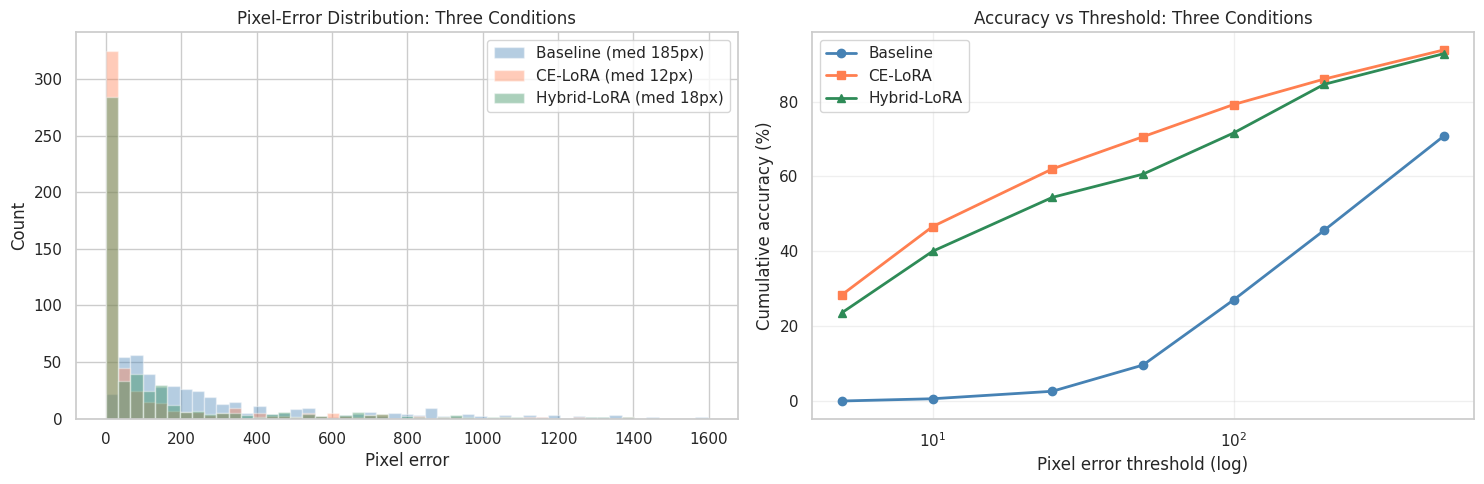


[Raw output comparison on 5 random eval samples]
------------------------------------------------------------------------------------------
GT=(882, 39)
  Baseline    : '(872, 10)'
  CE-LoRA     : '(916, 38)'
  Hybrid-LoRA : '(800, 37)'

GT=(499, 599)
  Baseline    : '(350, 100, 950, 110)'
  CE-LoRA     : '(520, 90)'
  Hybrid-LoRA : '(500, 92)'

GT=(561, 114)
  Baseline    : '(500, 100)'
  CE-LoRA     : '(568, 75)'
  Hybrid-LoRA : '(568, 74)'

GT=(338, 667)
  Baseline    : '(242, 598)'
  CE-LoRA     : '(327, 667)'
  Hybrid-LoRA : '(330, 665)'

GT=(148, 379)
  Baseline    : '(333, 375)'
  CE-LoRA     : '(148, 379)'
  Hybrid-LoRA : '(154, 378)'



In [ ]:
# ============================================================
# Three-way comparison: Baseline vs CE-LoRA vs Hybrid-LoRA
# ============================================================
import matplotlib.pyplot as plt

hybrid_metrics, hybrid_valid = compute_metrics(ft_hybrid_df)


def fmt_delta(b, f, higher_is_better):
    if any(map(lambda v: v != v, [b, f])):
        return "   n/a"
    d = f - b
    arrow = "↑" if (d > 0) == higher_is_better else ("↓" if d != 0 else "·")
    return f"{d:+7.2f} {arrow}"


print("=" * 90)
print(f"  Qwen2-VL-2B: BASELINE vs CE-LoRA vs HYBRID-LoRA  (same {len(eval_items)} eval samples)")
print("=" * 90)

# Format compliance
print(f"\n[Format compliance - higher is better]")
print(f"{'Metric':<32}{'Baseline':>10}{'CE-LoRA':>10}{'Hybrid':>10}{'Δ vs CE':>16}")
for k, label in [("parse_rate",     "Parse rate (%)"),
                 ("in_bounds_rate", "In-bounds rate (%)")]:
    b = baseline_metrics[k]
    c = ft_metrics[k]
    h = hybrid_metrics[k]
    print(f"{label:<32}{b:>10.2f}{c:>10.2f}{h:>10.2f}   {fmt_delta(c, h, True)}")

# Distance error - lower is better (so Δ_HYBRID_minus_CE < 0 means hybrid better)
print(f"\n[Distance error - lower is better]")
print(f"{'Metric':<32}{'Baseline':>10}{'CE-LoRA':>10}{'Hybrid':>10}{'Δ vs CE':>16}")
for k, label in [("mean_err_norm",     "Mean err (normalized)"),
                 ("median_err_norm",   "Median err (normalized)"),
                 ("mean_err_px",       "Mean err (pixels)"),
                 ("median_err_px",     "Median err (pixels)"),
                 ("mean_err_pct_diag", "Mean err (% diagonal)")]:
    b = baseline_metrics[k]
    c = ft_metrics[k]
    h = hybrid_metrics[k]
    print(f"{label:<32}{b:>10.2f}{c:>10.2f}{h:>10.2f}   {fmt_delta(c, h, False)}")

# Accuracy at thresholds
print(f"\n[Accuracy at thresholds - higher is better, % of all {len(eval_items)} samples]")
print(f"{'Metric':<32}{'Baseline':>10}{'CE-LoRA':>10}{'Hybrid':>10}{'Δ vs CE':>16}")
for thr in [5, 10, 25, 50, 100, 200]:
    k = f"acc_px_{thr}"
    b, c, h = baseline_metrics[k], ft_metrics[k], hybrid_metrics[k]
    print(f"{'Acc @ '+str(thr)+' px':<32}{b:>10.2f}{c:>10.2f}{h:>10.2f}   {fmt_delta(c, h, True)}")
for thr in [1, 2, 5, 10]:
    k = f"acc_diag_{thr}"
    b, c, h = baseline_metrics[k], ft_metrics[k], hybrid_metrics[k]
    print(f"{'Acc @ '+str(thr)+'% of diagonal':<32}{b:>10.2f}{c:>10.2f}{h:>10.2f}   {fmt_delta(c, h, True)}")
print("=" * 90)


# ---------- Visual comparison ----------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Three overlaid histograms
max_err = max(
    baseline_valid["err_px"].max() if len(baseline_valid) else 1,
    ft_valid["err_px"].max() if len(ft_valid) else 1,
    hybrid_valid["err_px"].max() if len(hybrid_valid) else 1,
)
bins = np.linspace(0, max_err, 50)
if len(baseline_valid):
    axes[0].hist(baseline_valid["err_px"], bins=bins, alpha=0.4,
                 color="steelblue",
                 label=f"Baseline (med {baseline_metrics['median_err_px']:.0f}px)")
if len(ft_valid):
    axes[0].hist(ft_valid["err_px"], bins=bins, alpha=0.4,
                 color="coral",
                 label=f"CE-LoRA (med {ft_metrics['median_err_px']:.0f}px)")
if len(hybrid_valid):
    axes[0].hist(hybrid_valid["err_px"], bins=bins, alpha=0.4,
                 color="seagreen",
                 label=f"Hybrid-LoRA (med {hybrid_metrics['median_err_px']:.0f}px)")
axes[0].set_xlabel("Pixel error")
axes[0].set_ylabel("Count")
axes[0].set_title("Pixel-Error Distribution: Three Conditions")
axes[0].legend()

# Three overlaid accuracy-vs-threshold curves
thresholds = [5, 10, 25, 50, 100, 200, 500]
def acc_curve(valid_df, n_total):
    return [(valid_df["err_px"] <= t).sum() / n_total * 100
            if len(valid_df) else 0 for t in thresholds]

axes[1].plot(thresholds, acc_curve(baseline_valid, len(baseline_df)),
             "o-", color="steelblue", linewidth=2, label="Baseline")
axes[1].plot(thresholds, acc_curve(ft_valid, len(ft_df)),
             "s-", color="coral", linewidth=2, label="CE-LoRA")
axes[1].plot(thresholds, acc_curve(hybrid_valid, len(ft_hybrid_df)),
             "^-", color="seagreen", linewidth=2, label="Hybrid-LoRA")
axes[1].set_xscale("log")
axes[1].set_xlabel("Pixel error threshold (log)")
axes[1].set_ylabel("Cumulative accuracy (%)")
axes[1].set_title("Accuracy vs Threshold: Three Conditions")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


# Raw output comparison on a few samples
print("\n[Raw output comparison on 5 random eval samples]")
print("-" * 90)
sample_idxs = np.random.RandomState(0).choice(
    len(baseline_df), size=min(5, len(baseline_df)), replace=False
)
for i in sample_idxs:
    b_row = baseline_df.iloc[i]
    c_row = ft_df.iloc[i]
    h_row = ft_hybrid_df.iloc[i]
    print(f"GT=({b_row['gt_x']}, {b_row['gt_y']})")
    print(f"  Baseline    : {b_row['raw_output']!r}")
    print(f"  CE-LoRA     : {c_row['raw_output']!r}")
    print(f"  Hybrid-LoRA : {h_row['raw_output']!r}")
    print()